<h1>NYC Rent Affordability Investigation:<br>Extract Transform Load & Preliminary Visualization</h1>

This is an investigation of rent affordability in NYC using neighborhood-level and borough-level from 2012-2022. 

I am using median rent data from the [Streeteasy Dashboard](https://streeteasy.com/blog/data-dashboard/), and median income data from the [U.S. Census American Community Survey](https://www.census.gov/programs-surveys/acs/data.html).

# Importing python packages and modules

In [1]:
# loading packages and modules (utils)
from utils.streeteasy_data_tools import tidy_rent_data
from utils.us_census_data_tools import Import_ACS_Table
from utils.psql_connection_tools import get_engine

In [2]:
# data acquisition, stats, & plotting
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta, timezone
from dateutil.relativedelta import relativedelta
# estimators/models
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
# preprocessing & engineering
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# model scoring
from sklearn.metrics import silhouette_score
# BigQuery Connection
import json
from google.cloud import bigquery
from google.oauth2 import service_account
# organization
import warnings
warnings.filterwarnings('ignore')

# Importing, Visualizing/Understanding, Preprocessing, and Uploading Rent Data

## Extract/Import Rent Data

1. Downloading the latest streeteasy data of median rental prices.

In [3]:
# Median asking rent for All APT sizes
df_rent_all = pd.read_csv("https://cdn-charts.streeteasy.com/rentals/"
                          "All/medianAskingRent_All.zip", compression='zip')

# Median asking rent for 1-Bedroom APTs
df_rent_1bdr = pd.read_csv("https://cdn-charts.streeteasy.com/rentals/"
                           "OneBd/medianAskingRent_OneBd.zip", compression='zip')

# Median asking rent for APTs with 3 Bedrooms or More
df_rent_3bdr = pd.read_csv("https://cdn-charts.streeteasy.com/rentals/"
                           "ThreePlusBd/medianAskingRent_ThreePlusBd.zip",
                            compression='zip')

df_rent_all

,areaName,Borough,areaType,2010-01,2010-02,2010-03,2010-04,2010-05,2010-06,2010-07,...,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
0,All Downtown,Manhattan,submarket,3200.0,3200.0,3015.0,3100.0,3100.0,3200.0,3195.0,...,5000.0,5193.5,5250.0,5300.0,5439.0,5400.0,5310.0,5303.0,5350.0,5350.0
1,All Midtown,Manhattan,submarket,2875.0,2800.0,2800.0,2850.0,2895.0,2950.0,3000.0,...,4590.0,4691.5,4750.0,4850.0,4869.5,4800.0,4750.0,4695.0,4650.0,4650.0
2,All Upper East Side,Manhattan,submarket,2450.0,2450.0,2400.0,2500.0,2565.0,2570.0,2595.0,...,3995.0,4000.0,4150.0,4200.0,4200.0,4200.0,4200.0,4137.5,4250.0,4395.0
3,All Upper Manhattan,Manhattan,submarket,1825.0,1800.0,1795.0,1800.0,1823.0,1850.0,1875.0,...,2900.0,3000.0,3195.0,3245.0,3299.5,3225.0,3208.0,3195.0,3125.0,3100.0
4,All Upper West Side,Manhattan,submarket,2895.0,2800.0,2750.0,2800.0,2800.0,2795.0,2800.0,...,4500.0,4500.0,4500.0,4720.5,4799.0,4800.0,4800.0,4800.0,4800.0,4932.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,Windsor Terrace,Brooklyn,neighborhood,1550.0,1600.0,1650.0,1600.0,1800.0,1825.0,1995.0,...,3800.0,3995.0,3950.0,4500.0,4695.0,4350.0,3995.0,3900.0,3577.5,3597.5
194,Woodhaven,Queens,neighborhood,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2100.0,2250.0,2485.0,2200.0,2375.0,2500.0,2152.5,2125.0,NaN
195,Woodlawn,Bronx,neighborhood,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
196,Woodside,Queens,neighborhood,1700.0,1647.5,1397.5,2000.0,1500.0,1512.5,1487.5,...,2999.5,3100.0,2977.5,3065.0,3050.0,3025.0,3025.0,3150.0,3150.0,3050.0


2. Download the inventory data, so we know the volume of units that make up the data.

This valuable information provides context that can help us determine whether the data comes from a large enough sample size.

In [4]:
# number of apartments that make up the rent price dataset for ALL appartment sizes.
df_inventory_all = pd.read_csv("https://cdn-charts.streeteasy.com/rentals/"
                                "All/rentalInventory_All.zip", compression='zip')
# number of 1 bedrooom apartments that make up the rent price dataset
df_inventory_1bdr = pd.read_csv("https://cdn-charts.streeteasy.com/rentals/"
                                "OneBd/rentalInventory_OneBd.zip", compression='zip')
# number of 3+ bedroom apartments that make up the rent price dataset.
df_inventory_3bdr = pd.read_csv("https://cdn-charts.streeteasy.com/rentals/"
                                "ThreePlusBd/rentalInventory_ThreePlusBd.zip", compression='zip')

df_inventory_all

,areaName,Borough,areaType,2010-01,2010-02,2010-03,2010-04,2010-05,2010-06,2010-07,...,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
0,All Downtown,Manhattan,submarket,4253,4521,4593,4679,4487,4577,4260,...,4856,5674,6605,6745,6998,6419,5350,4955,4035,3772
1,All Midtown,Manhattan,submarket,3065,3207,3239,3412,3117,3112,3028,...,3611,4018,4397,4374,4608,4324,3941,3737,3318,3118
2,All Upper East Side,Manhattan,submarket,2549,2651,2638,2583,2483,2650,2555,...,1686,1945,2247,2293,2474,2178,2059,1934,1594,1444
3,All Upper Manhattan,Manhattan,submarket,846,843,813,738,707,770,754,...,2006,2051,2376,2407,2756,2529,2355,2168,1970,1867
4,All Upper West Side,Manhattan,submarket,2163,2186,2306,2452,2327,2413,2220,...,1595,1823,2051,2226,2335,2125,1873,1636,1415,1240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,Windsor Terrace,Brooklyn,neighborhood,16,19,14,16,17,16,21,...,93,81,85,82,77,90,93,83,62,38
194,Woodhaven,Queens,neighborhood,0,0,0,0,0,1,1,...,9,16,15,16,22,12,14,14,12,9
195,Woodlawn,Bronx,neighborhood,0,0,0,0,0,0,0,...,1,2,1,2,3,2,0,0,0,0
196,Woodside,Queens,neighborhood,11,10,10,17,12,14,10,...,138,158,148,138,110,130,154,142,141,152


## Tidying the Rent Datasets

Let's convert all of the rent datasets into tidy format, and ensure columns names and contents are optimized for usability.

In [5]:
# melting DFs and splitting the month-year column into separate columns
rent_all_clean = tidy_rent_data(df_rent_all)
rent_1bdr_clean = tidy_rent_data(df_rent_1bdr)
rent_3bdr_clean = tidy_rent_data(df_rent_3bdr)

# merging datasets to create one median_rent DF
merged_table = pd.merge(rent_all_clean.rename(columns={"median_rent":"all_price"}), 
                        rent_1bdr_clean.rename(columns={"median_rent":"1bdr_price"}), 
                        how='inner', on=["area_name", "borough", "area_type","year","month"]
                        )

median_rent_table = pd.merge(merged_table, 
                        rent_3bdr_clean.rename(columns={"median_rent":"3bdr_price"}), 
                        how='inner', on=["area_name", "borough", "area_type","year","month"]
                        )
median_rent_table

,area_name,borough,area_type,year,month,all_price,1bdr_price,3bdr_price
0,All Downtown,Manhattan,submarket,2010,01,3200.0,2995.0,6700.0
1,All Midtown,Manhattan,submarket,2010,01,2875.0,2800.0,7500.0
2,All Upper East Side,Manhattan,submarket,2010,01,2450.0,2350.0,8925.0
3,All Upper Manhattan,Manhattan,submarket,2010,01,1825.0,1500.0,2700.0
4,All Upper West Side,Manhattan,submarket,2010,01,2895.0,2600.0,7000.0
...,...,...,...,...,...,...,...,...
38011,Windsor Terrace,Brooklyn,neighborhood,2025,12,3597.5,3000.0,NaN
38012,Woodhaven,Queens,neighborhood,2025,12,NaN,NaN,NaN
38013,Woodlawn,Bronx,neighborhood,2025,12,NaN,NaN,NaN
38014,Woodside,Queens,neighborhood,2025,12,3050.0,2800.0,3700.0


In [6]:
inventory_all_clean = tidy_rent_data(df_inventory_all)
inventory_1bdr_clean = tidy_rent_data(df_inventory_1bdr)
inventory_3bdr_clean = tidy_rent_data(df_inventory_3bdr)
# merging datasets to create one median_rent DF
merged_table = pd.merge(inventory_all_clean.rename(columns={"median_rent":"all_count"}), 
                        inventory_1bdr_clean.rename(columns={"median_rent":"1bdr_count"}), 
                        how='inner', on=["area_name", "borough", "area_type","year","month"]
                        )

median_inventory_table = pd.merge(merged_table, 
                        inventory_3bdr_clean.rename(columns={"median_rent":"3bdr_count"}), 
                        how='inner', on=["area_name", "borough", "area_type","year","month"]
                        )
median_inventory_table

,area_name,borough,area_type,year,month,all_count,1bdr_count,3bdr_count
0,All Downtown,Manhattan,submarket,2010,01,4253,1640.0,463.0
1,All Midtown,Manhattan,submarket,2010,01,3065,1410.0,207.0
2,All Upper East Side,Manhattan,submarket,2010,01,2549,1063.0,260.0
3,All Upper Manhattan,Manhattan,submarket,2010,01,846,285.0,160.0
4,All Upper West Side,Manhattan,submarket,2010,01,2163,935.0,265.0
...,...,...,...,...,...,...,...,...
38011,Windsor Terrace,Brooklyn,neighborhood,2025,12,38,13.0,1.0
38012,Woodhaven,Queens,neighborhood,2025,12,9,5.0,3.0
38013,Woodlawn,Bronx,neighborhood,2025,12,0,NaN,NaN
38014,Woodside,Queens,neighborhood,2025,12,152,63.0,22.0


Let's merge the median rent price and apartment inventory tables, so we have all pertinent data in the same table. 

In [7]:
# Creating our Primary Rent Data Table
rent_df = pd.merge(median_rent_table, 
                   median_inventory_table, how='inner', 
                   on=["area_name", "borough", "area_type","year","month"]
                   )

rent_df

,area_name,borough,area_type,year,month,all_price,1bdr_price,3bdr_price,all_count,1bdr_count,3bdr_count
0,All Downtown,Manhattan,submarket,2010,01,3200.0,2995.0,6700.0,4253,1640.0,463.0
1,All Midtown,Manhattan,submarket,2010,01,2875.0,2800.0,7500.0,3065,1410.0,207.0
2,All Upper East Side,Manhattan,submarket,2010,01,2450.0,2350.0,8925.0,2549,1063.0,260.0
3,All Upper Manhattan,Manhattan,submarket,2010,01,1825.0,1500.0,2700.0,846,285.0,160.0
4,All Upper West Side,Manhattan,submarket,2010,01,2895.0,2600.0,7000.0,2163,935.0,265.0
...,...,...,...,...,...,...,...,...,...,...,...
38011,Windsor Terrace,Brooklyn,neighborhood,2025,12,3597.5,3000.0,NaN,38,13.0,1.0
38012,Woodhaven,Queens,neighborhood,2025,12,NaN,NaN,NaN,9,5.0,3.0
38013,Woodlawn,Bronx,neighborhood,2025,12,NaN,NaN,NaN,0,NaN,NaN
38014,Woodside,Queens,neighborhood,2025,12,3050.0,2800.0,3700.0,152,63.0,22.0


## Transform\Preprocess Rent Data

### Cleaning Data

In [8]:
# explicitly setting the data type for all columns
rent_df['year'] = rent_df['year'].astype('int')
rent_df['month'] = rent_df['month'].astype('int')
rent_df = rent_df.convert_dtypes()
print(rent_df.dtypes)

area_name     string[python]
borough       string[python]
area_type     string[python]
year                   Int64
month                  Int64
all_price            Float64
1bdr_price           Float64
3bdr_price           Float64
all_count              Int64
1bdr_count             Int64
3bdr_count             Int64
dtype: object


Let's look at a disitribution of the volume of apartment units sampled across monthly values. 

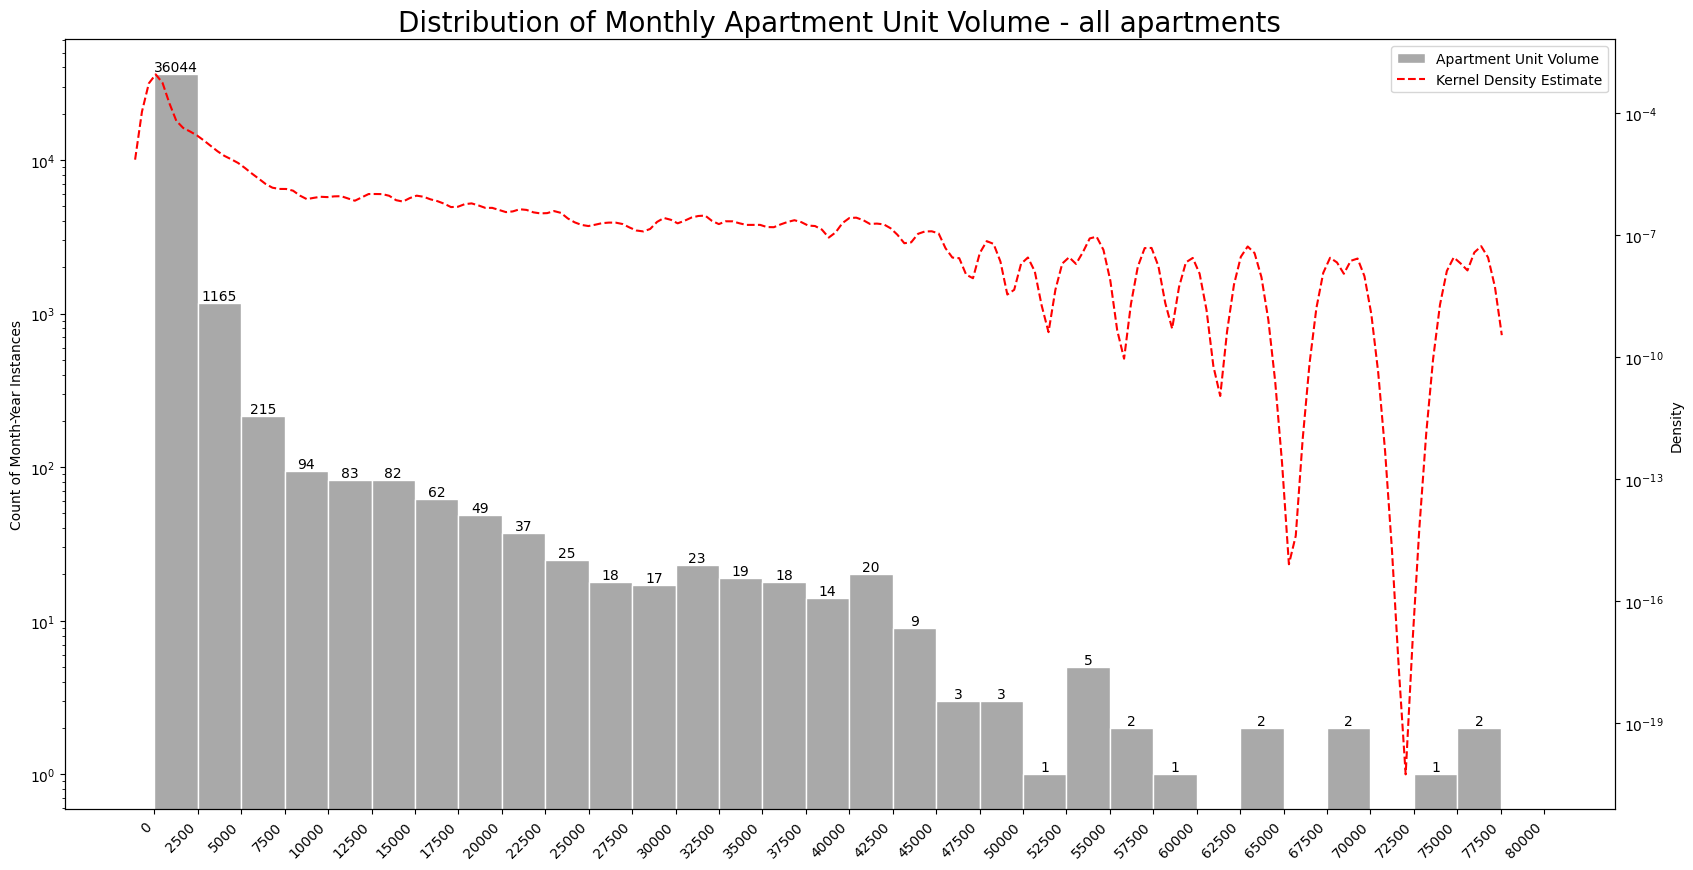

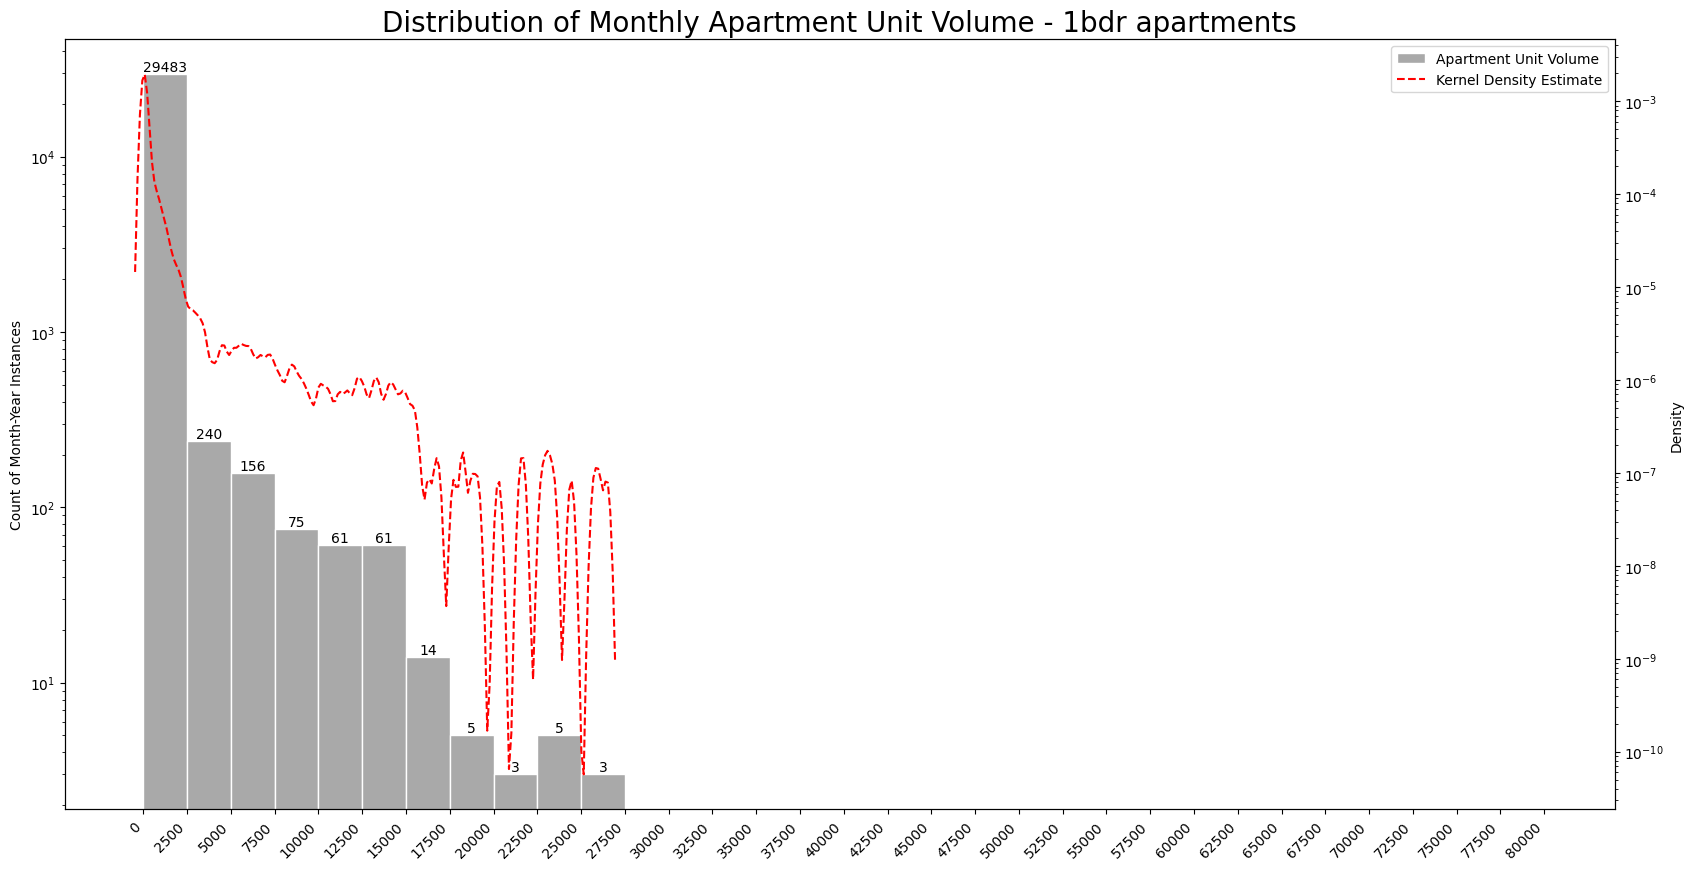

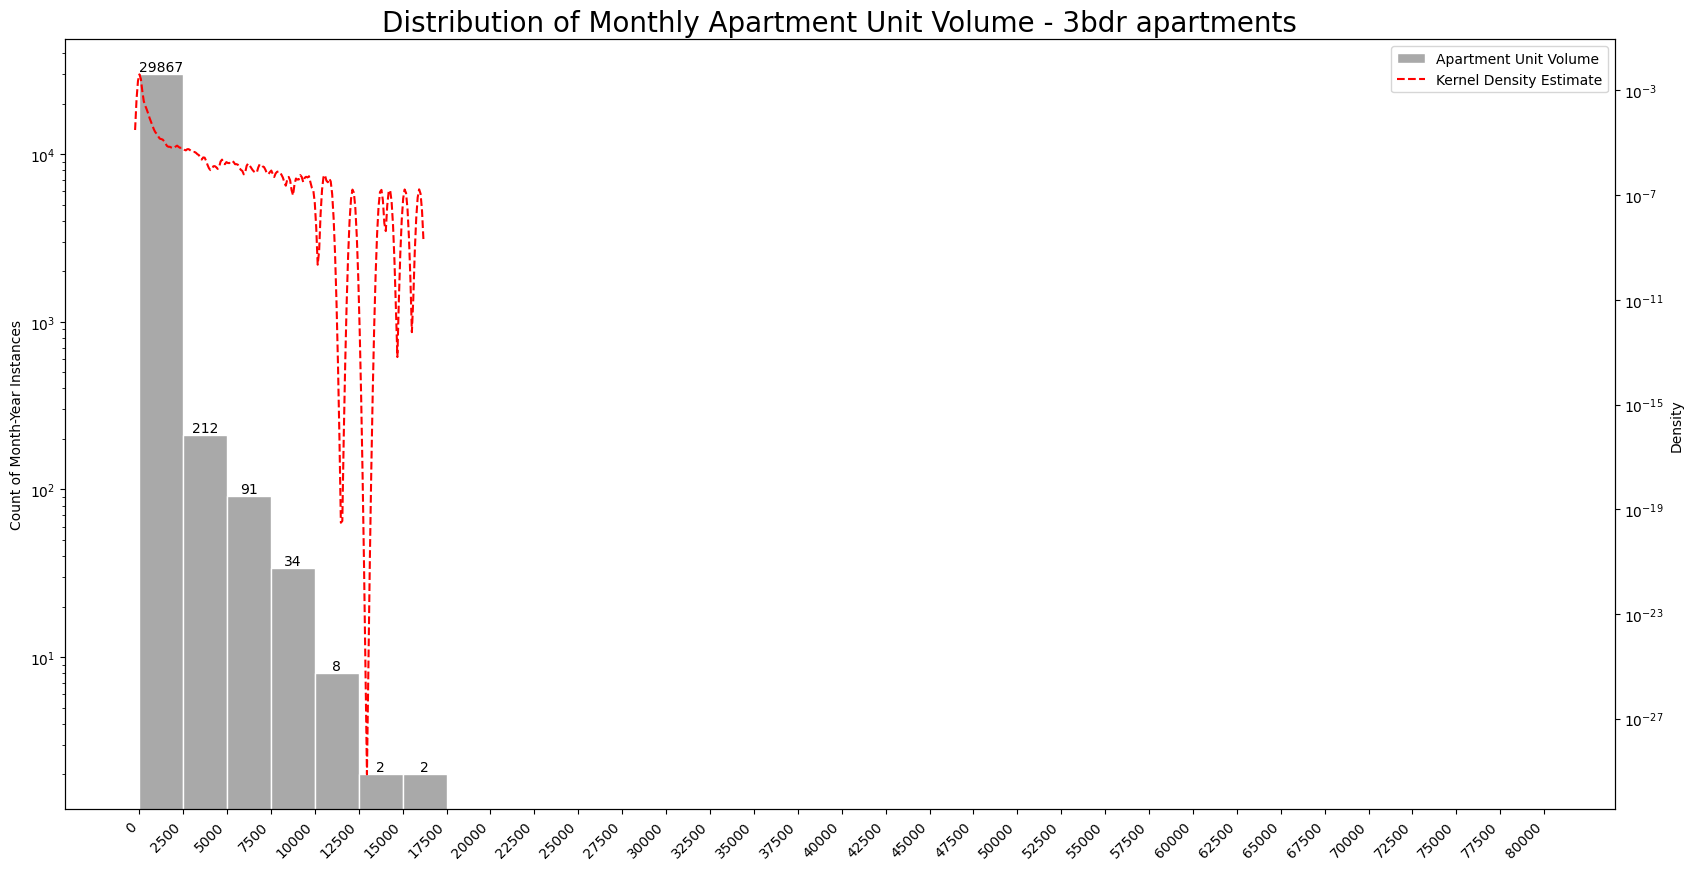

In [9]:
type = ['all','1bdr','3bdr']


for apt in type:
    x_ticks = np.arange(0,82500,2500)
    fig, ax = plt.subplots(figsize=(20,10))
    counts, bins, patches = ax.hist(rent_df[f'{apt}_count'], bins=32, range=[0,80000], log=True,
                                    label='Apartment Unit Volume', **{'facecolor':'darkgrey','edgecolor':'white'})
    ax.set_xticks(x_ticks, x_ticks.astype('int'), rotation=45, ha='right')
    ax.bar_label(patches, labels=[f'{int(c)}' for c in counts], label_type='edge')
    ax.set_ylabel('Count of Month-Year Instances')
    ax2 = ax.twinx()
    sns.kdeplot(rent_df[f'{apt}_count'], ax=ax2, color="red", linestyle="--", 
                label="Kernel Density Estimate", log_scale=(False, True))
    ax2.set_ylabel("Density")

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='best')
    plt.title(f'Distribution of Monthly Apartment Unit Volume - {apt} apartments', fontsize=20)
    plt.xlabel('Volume of Units')
    plt.show()

Most month-year instances have less than 2,500 apartment units in their sample size. 

Let's ensure we're working with only relevant data

In [10]:
cols = rent_df.columns.to_numpy(dtype='str')
# looking at the first 3 columns
for i in range(1,3):
    print(f'{cols[i]} values = {np.unique(rent_df[cols[i]].to_numpy(dtype='str'))}')
nhbd_num = len(rent_df['area_name'].unique())
print(f'number of neighborhoods = {nhbd_num}')

print("WE ARE ONLY INTERESTED IN DATA AT THE NEIGHBORHOOD & BOROUGH LEVEL, SO WE'RE GOING TO REMOVE ALL OTHER AREA TYPES")
rent_df = rent_df[(rent_df['area_type'] == 'neighborhood')|(rent_df['area_type'] == 'borough')]
# revisit stats
cols = rent_df.columns.to_numpy(dtype='str')
for i in range(1,3):
    print(f'{cols[i]} values = {np.unique(rent_df[cols[i]].to_numpy(dtype='str'))}')
nhbd_num = len(rent_df['area_name'].unique())
print(f'number of neighborhoods = {nhbd_num}')

print("WE WANT TO ENSURE THAT WE ARE LOOKING AT DATA FROM A LARGE ENOUGH SAMPLE SIZE, SO WE ARE REMOVING ENTRIES WITH LESS THAN 200 APT UNITS")
rent_df.loc[~(rent_df['all_count'] >= 200), 'all_price'] = np.nan
rent_df.loc[~(rent_df['1bdr_count'] >= 200), '1bdr_price'] = np.nan
rent_df.loc[~(rent_df['3bdr_count'] >= 200), '3bdr_price'] = np.nan
# let's remove rows where all 3 apartment types have less than the threshold of units
rent_df = rent_df.loc[~((np.isnan(rent_df['all_price']))&(np.isnan(rent_df['1bdr_price']))&(np.isnan(rent_df['3bdr_price'])))]
# revisit stats
cols = rent_df.columns.to_numpy(dtype='str')
for i in range(1,3):
    print(f'{cols[i]} values = {np.unique(rent_df[cols[i]].to_numpy(dtype='str'))}')
nhbds = rent_df['area_name'].unique()
print(f'number of neighborhoods = {len(nhbds)}')
print(f'neighborhoods = {nhbds}')

print("2025 HAS INCOMPLETE MONTHS OF DATA, SO WE'RE GOING TO REMOVE THAT FROM THE DATASET")
rent_df = rent_df[rent_df['year'] < 2025]

rent_df

borough values = ['<NA>' 'Bronx' 'Brooklyn' 'Manhattan' 'Queens' 'Staten Island']
area_type values = ['borough' 'city' 'neighborhood' 'submarket']
number of neighborhoods = 198
WE ARE ONLY INTERESTED IN DATA AT THE NEIGHBORHOOD & BOROUGH LEVEL, SO WE'RE GOING TO REMOVE ALL OTHER AREA TYPES
borough values = ['Bronx' 'Brooklyn' 'Manhattan' 'Queens' 'Staten Island']
area_type values = ['borough' 'neighborhood']
number of neighborhoods = 182
WE WANT TO ENSURE THAT WE ARE LOOKING AT DATA FROM A LARGE ENOUGH SAMPLE SIZE, SO WE ARE REMOVING ENTRIES WITH LESS THAN 200 APT UNITS
borough values = ['Bronx' 'Brooklyn' 'Manhattan' 'Queens']
area_type values = ['borough' 'neighborhood']
number of neighborhoods = 72
neighborhoods = <StringArray>
[        'Battery Park City',                  'Brooklyn',
            'Central Harlem',                   'Chelsea',
              'East Village',        'Financial District',
                  'Flatiron',             'Gramercy Park',
         'Greenwich Vil

,area_name,borough,area_type,year,month,all_price,1bdr_price,3bdr_price,all_count,1bdr_count,3bdr_count
8,Battery Park City,Manhattan,neighborhood,2010,1,3495.0,<NA>,<NA>,213,89,28
24,Brooklyn,Brooklyn,borough,2010,1,2200.0,1950.0,2975.0,1820,723,256
33,Central Harlem,Manhattan,neighborhood,2010,1,1950.0,<NA>,<NA>,430,129,73
36,Chelsea,Manhattan,neighborhood,2010,1,3200.0,3150.0,<NA>,604,235,55
63,East Village,Manhattan,neighborhood,2010,1,2500.0,<NA>,<NA>,457,195,49
...,...,...,...,...,...,...,...,...,...,...,...
35623,Upper East Side,Manhattan,neighborhood,2024,12,3950.0,3700.0,11340.0,1639,642,221
35624,Upper West Side,Manhattan,neighborhood,2024,12,4400.0,4252.0,9000.0,1365,505,253
35628,Washington Heights,Manhattan,neighborhood,2024,12,2650.0,<NA>,<NA>,459,182,97
35630,West Village,Manhattan,neighborhood,2024,12,5450.0,<NA>,<NA>,301,133,37


### Quantifying Missing Data at the Neighborhood & Borough level

In [11]:
def create_data_availability_heatmap(rent_df, borough='Manhattan', figsize=(30, 15), apt_type='1bdr',
                                     subtitle='All Apartments'):
    """
    This FX creates a heatmap of data availability (1s and 0s) for rent data
    by neighborhood and year-month date combos.
    
    Input:
        df_rent_all: pandas dataframe with neighborhoods and date columns
        borough: string representing the borough to filter for (default: 'Manhattan')
        figsize: tuple of the figure size for the plot
    """
    
    # Filter data for the specified borough and/or neighborhood type
    if borough == 'Staten Island':
        subset_df = rent_df[rent_df['borough'] == borough]
    else:
        subset_df = rent_df[(rent_df['borough'] == borough) & 
                            (rent_df['area_type'] == 'neighborhood')].copy()

    # subsetting pertinent columns
    subset_data = subset_df[['area_name','year','month',f'{apt_type}_price']].reset_index(drop=True)
    
    # Get neighborhood names for labeling
    neighborhood_names = subset_data['area_name'].reset_index(drop=True).drop_duplicates()

    # get month-year dates for plot axis
    dates = (pd.Series([f"{month:02d}" for month in subset_data['month']]).astype('str')+'-'+subset_data['year'].astype('str')).drop_duplicates() 
    
    # Create the availability matrix (1 for data present, 0 for missing)
    # Shape: (neighborhoods, dates)
    availability_matrix = np.zeros((len(neighborhood_names), len(dates)))
    
    # Fill the matrix
    for row_idx, neighborhood in enumerate(neighborhood_names):
        for col_idx, date in enumerate(dates):
            month = int(date[:2])
            year = int(date[3:])
            cell_value = subset_data[(subset_data['month'] == month)&(subset_data['year'] == year)&(subset_data['area_name'] == neighborhood)][f'{apt_type}_price']
            # Check if data is present (not NaN)
            if cell_value.any():
                availability_matrix[row_idx, col_idx] = 1
            else:
                availability_matrix[row_idx, col_idx] = 0

    # Create the heatmap
    plt.figure(figsize=figsize)
    
    # Use a custom colormap: white for missing (0), dark blue for present (1)
    colors = ['#FFFFFF', '#00008B'] 
    custom_cmap = mpl.colors.ListedColormap(colors)
    
    # Create heatmap
    ax = sns.heatmap(availability_matrix, 
                     cmap=custom_cmap,
                     cbar=False,
                     xticklabels=dates,
                     yticklabels=neighborhood_names,
                     linewidths=0.1,
                     linecolor='lightgray')
    
    # Customize the plot
    ax.set_title(f'Data Availability Heatmap: {borough} Neighborhoods - {subtitle}\n' + 
              'Dark Blue = Data Present, White = Data Missing', 
              fontsize=25, fontweight='bold', pad=20)
    ax.set_xlabel('Year-Month', fontsize=15, fontweight='bold')
    ax.set_ylabel('Neighborhoods', fontsize=15, fontweight='bold')
    ax.set_xticks(ticks=np.arange(0.5, len(dates)+0.5, 2), labels=dates[::2], rotation=75, ha='right',)
    ax.set_xticklabels(labels=dates[::2], fontdict={'fontsize': 15})
    ax.set_yticks(ticks=np.arange(0.5, len(neighborhood_names)+0.5))
    ax.set_yticklabels(labels=neighborhood_names, fontdict={'fontsize': 15})
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    plt.show()

    # Print summary statistics
    total_cells = availability_matrix.size
    present_data = np.sum(availability_matrix)
    missing_data = total_cells - present_data
    
    print(f"Data Availability Summary for {borough}:")
    print(f"Total data points: {total_cells}")
    print(f"Data present: {present_data} ({present_data/total_cells*100:.1f}%)")
    print(f"Data missing: {missing_data} ({missing_data/total_cells*100:.1f}%)")
    print(f"Number of neighborhoods: {len(neighborhood_names)}")
    print(f"Number of time periods: {len(dates)}")
    
    return

#### All Apartments

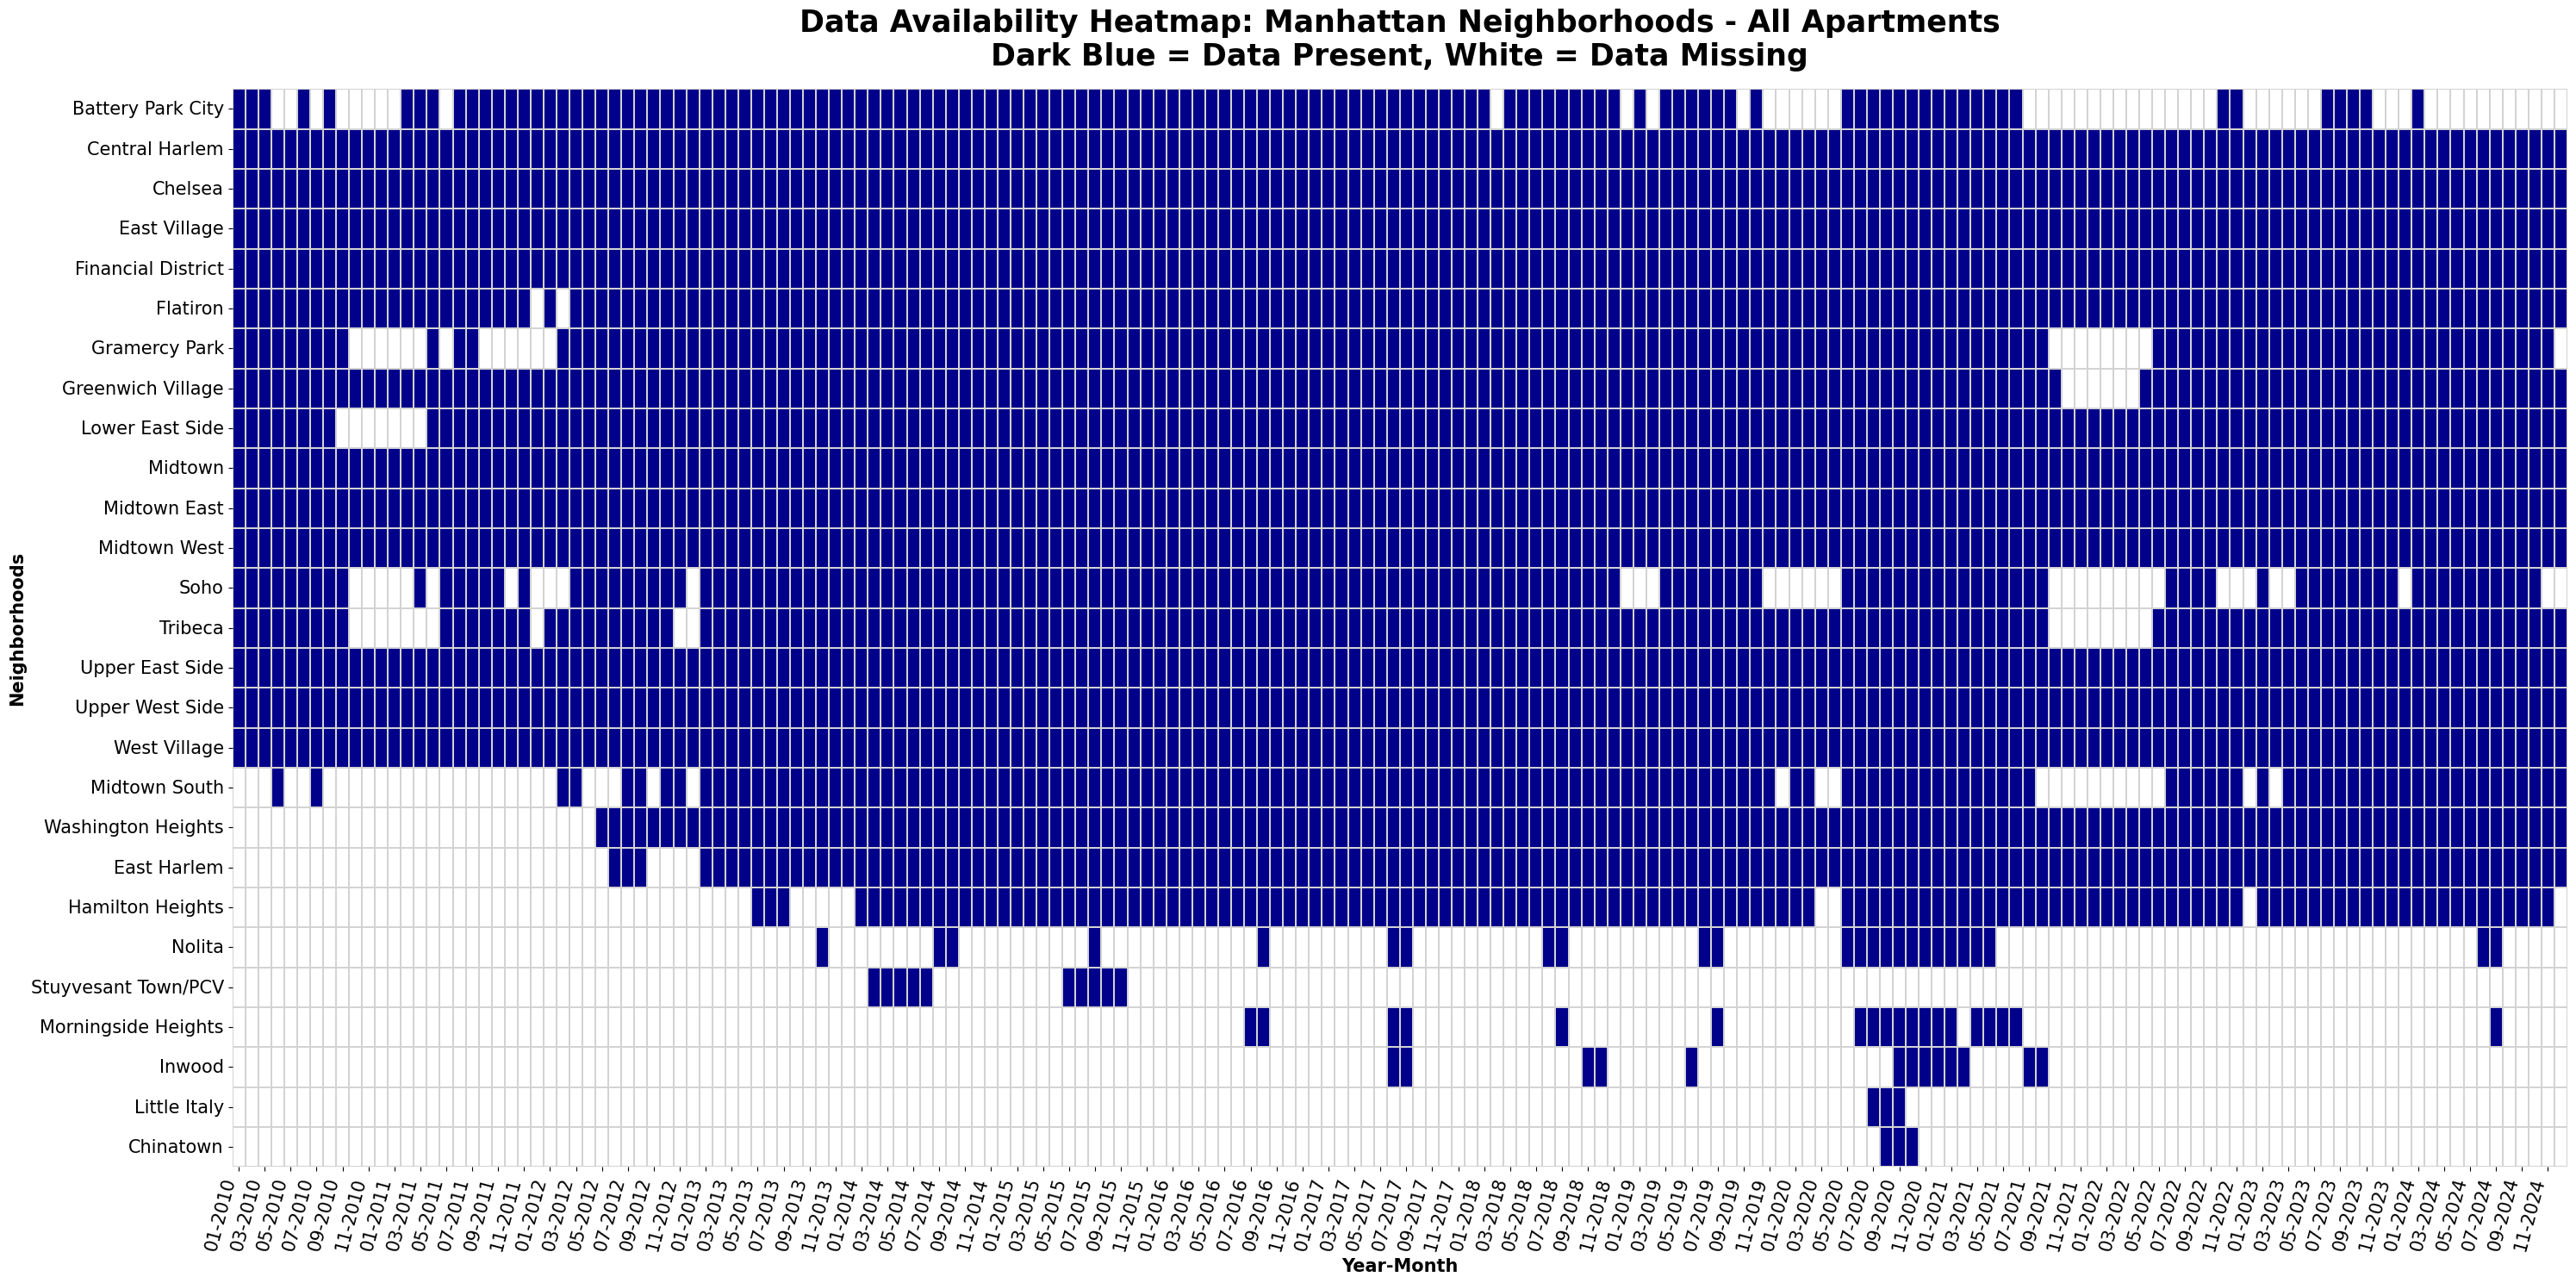

Data Availability Summary for Manhattan:
Total data points: 4860
Data present: 3554.0 (73.1%)
Data missing: 1306.0 (26.9%)
Number of neighborhoods: 27
Number of time periods: 180


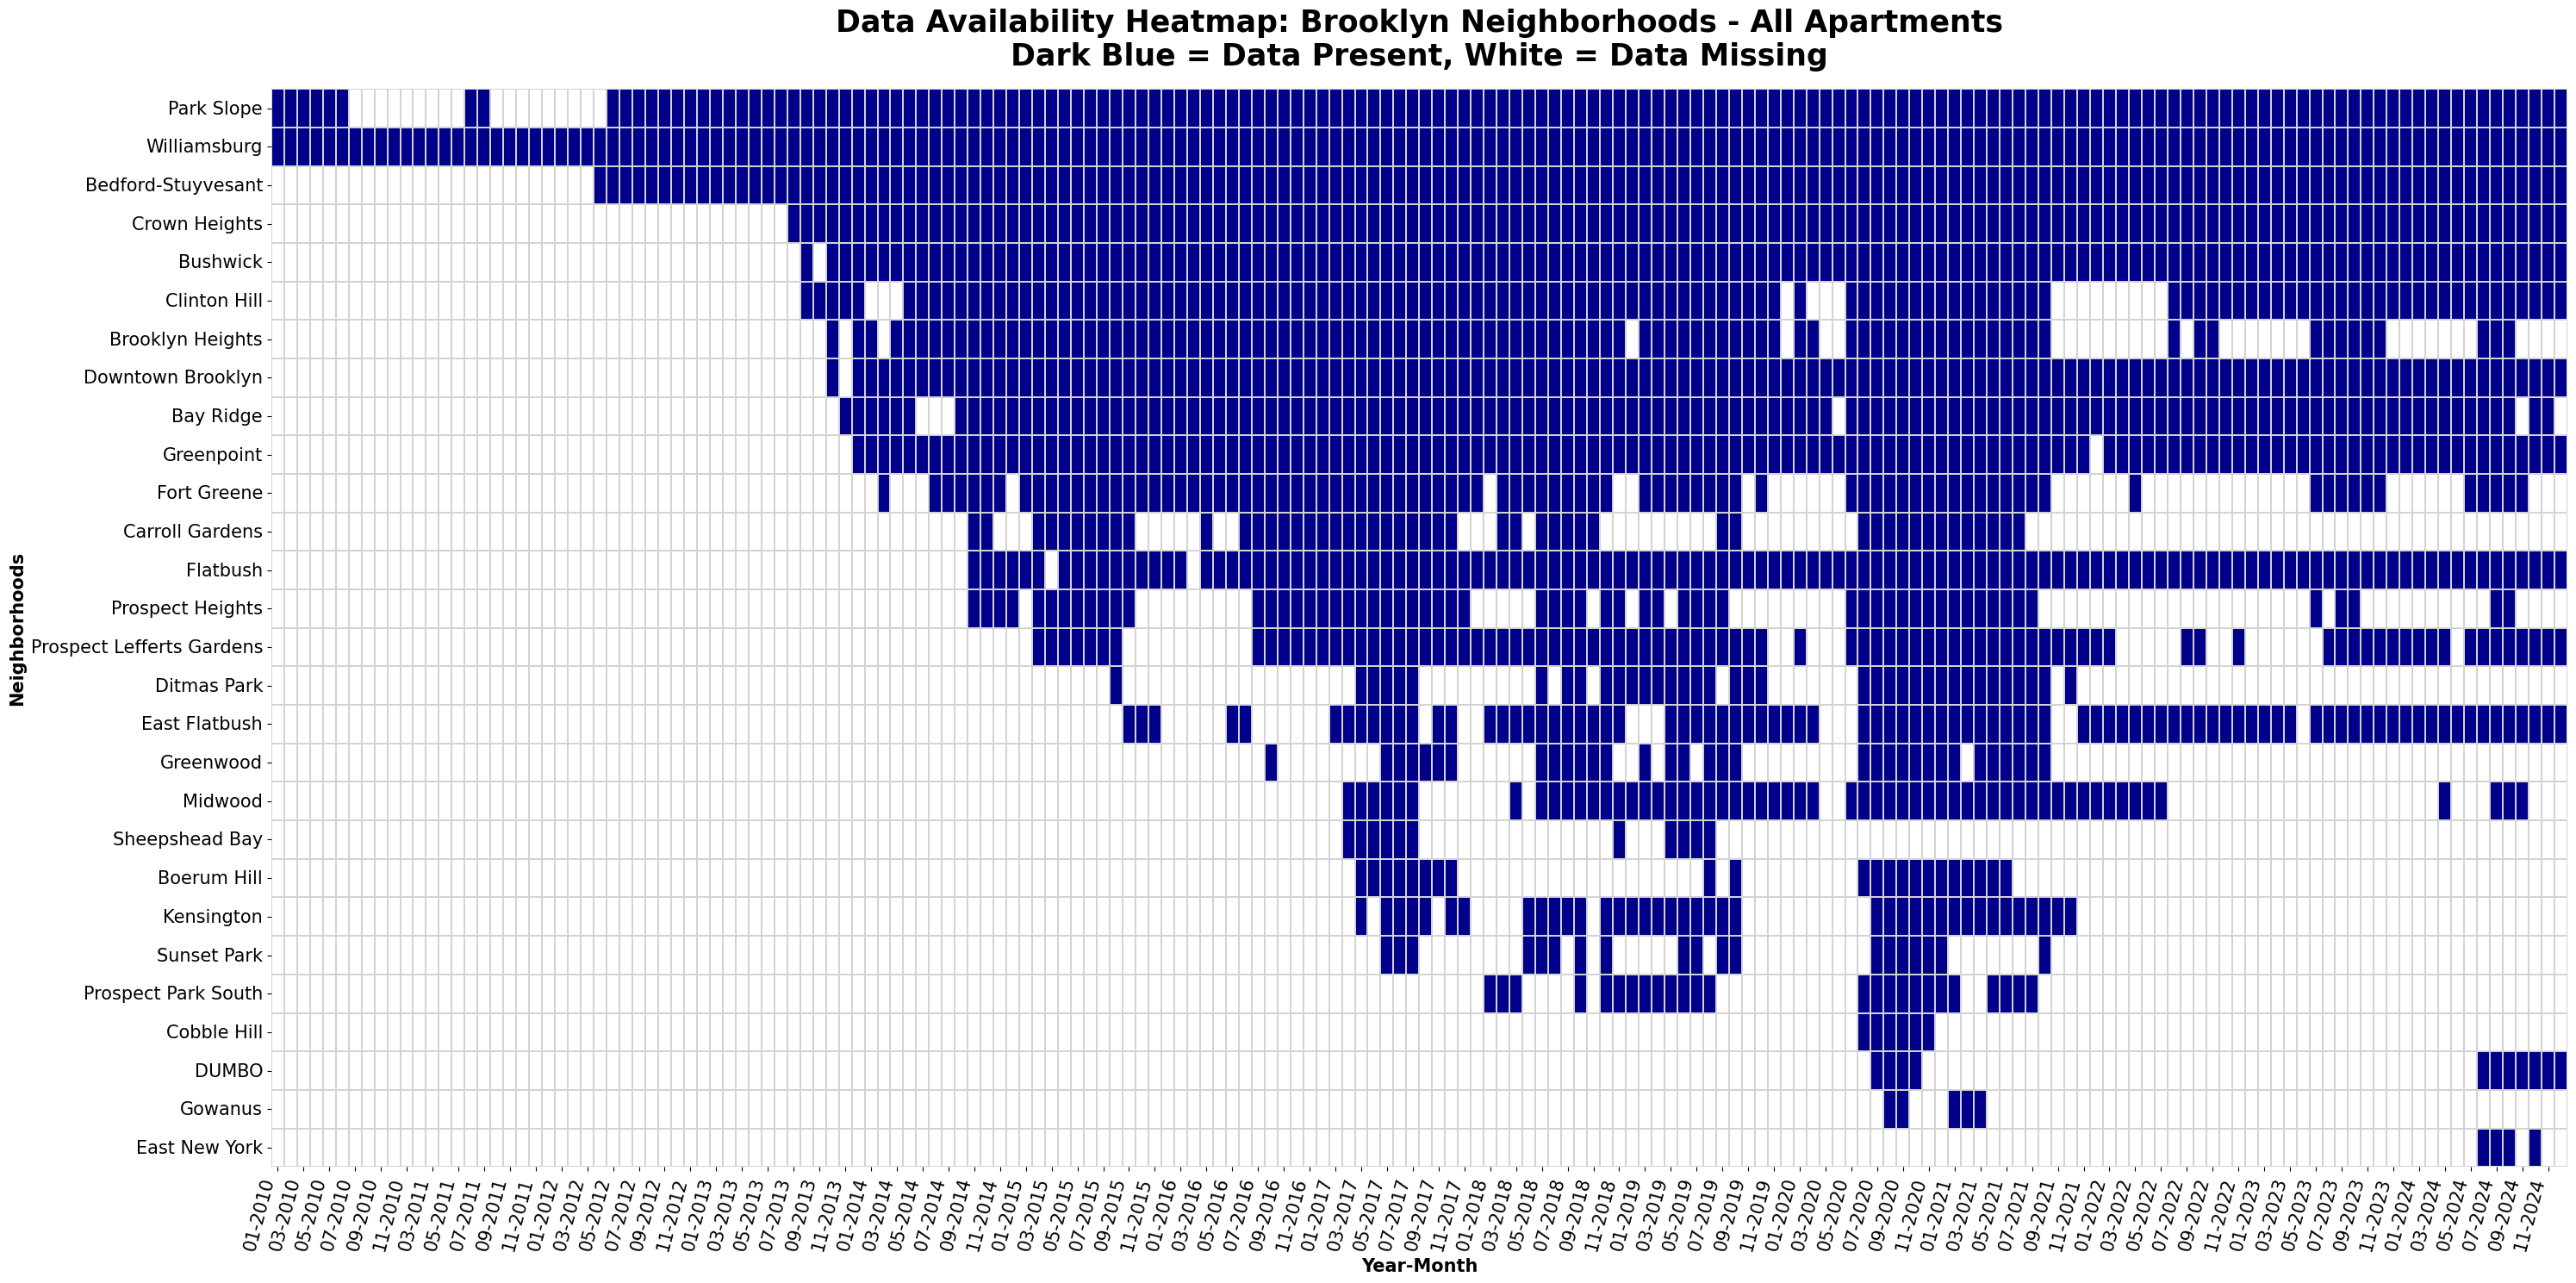

Data Availability Summary for Brooklyn:
Total data points: 4984
Data present: 2152.0 (43.2%)
Data missing: 2832.0 (56.8%)
Number of neighborhoods: 28
Number of time periods: 178


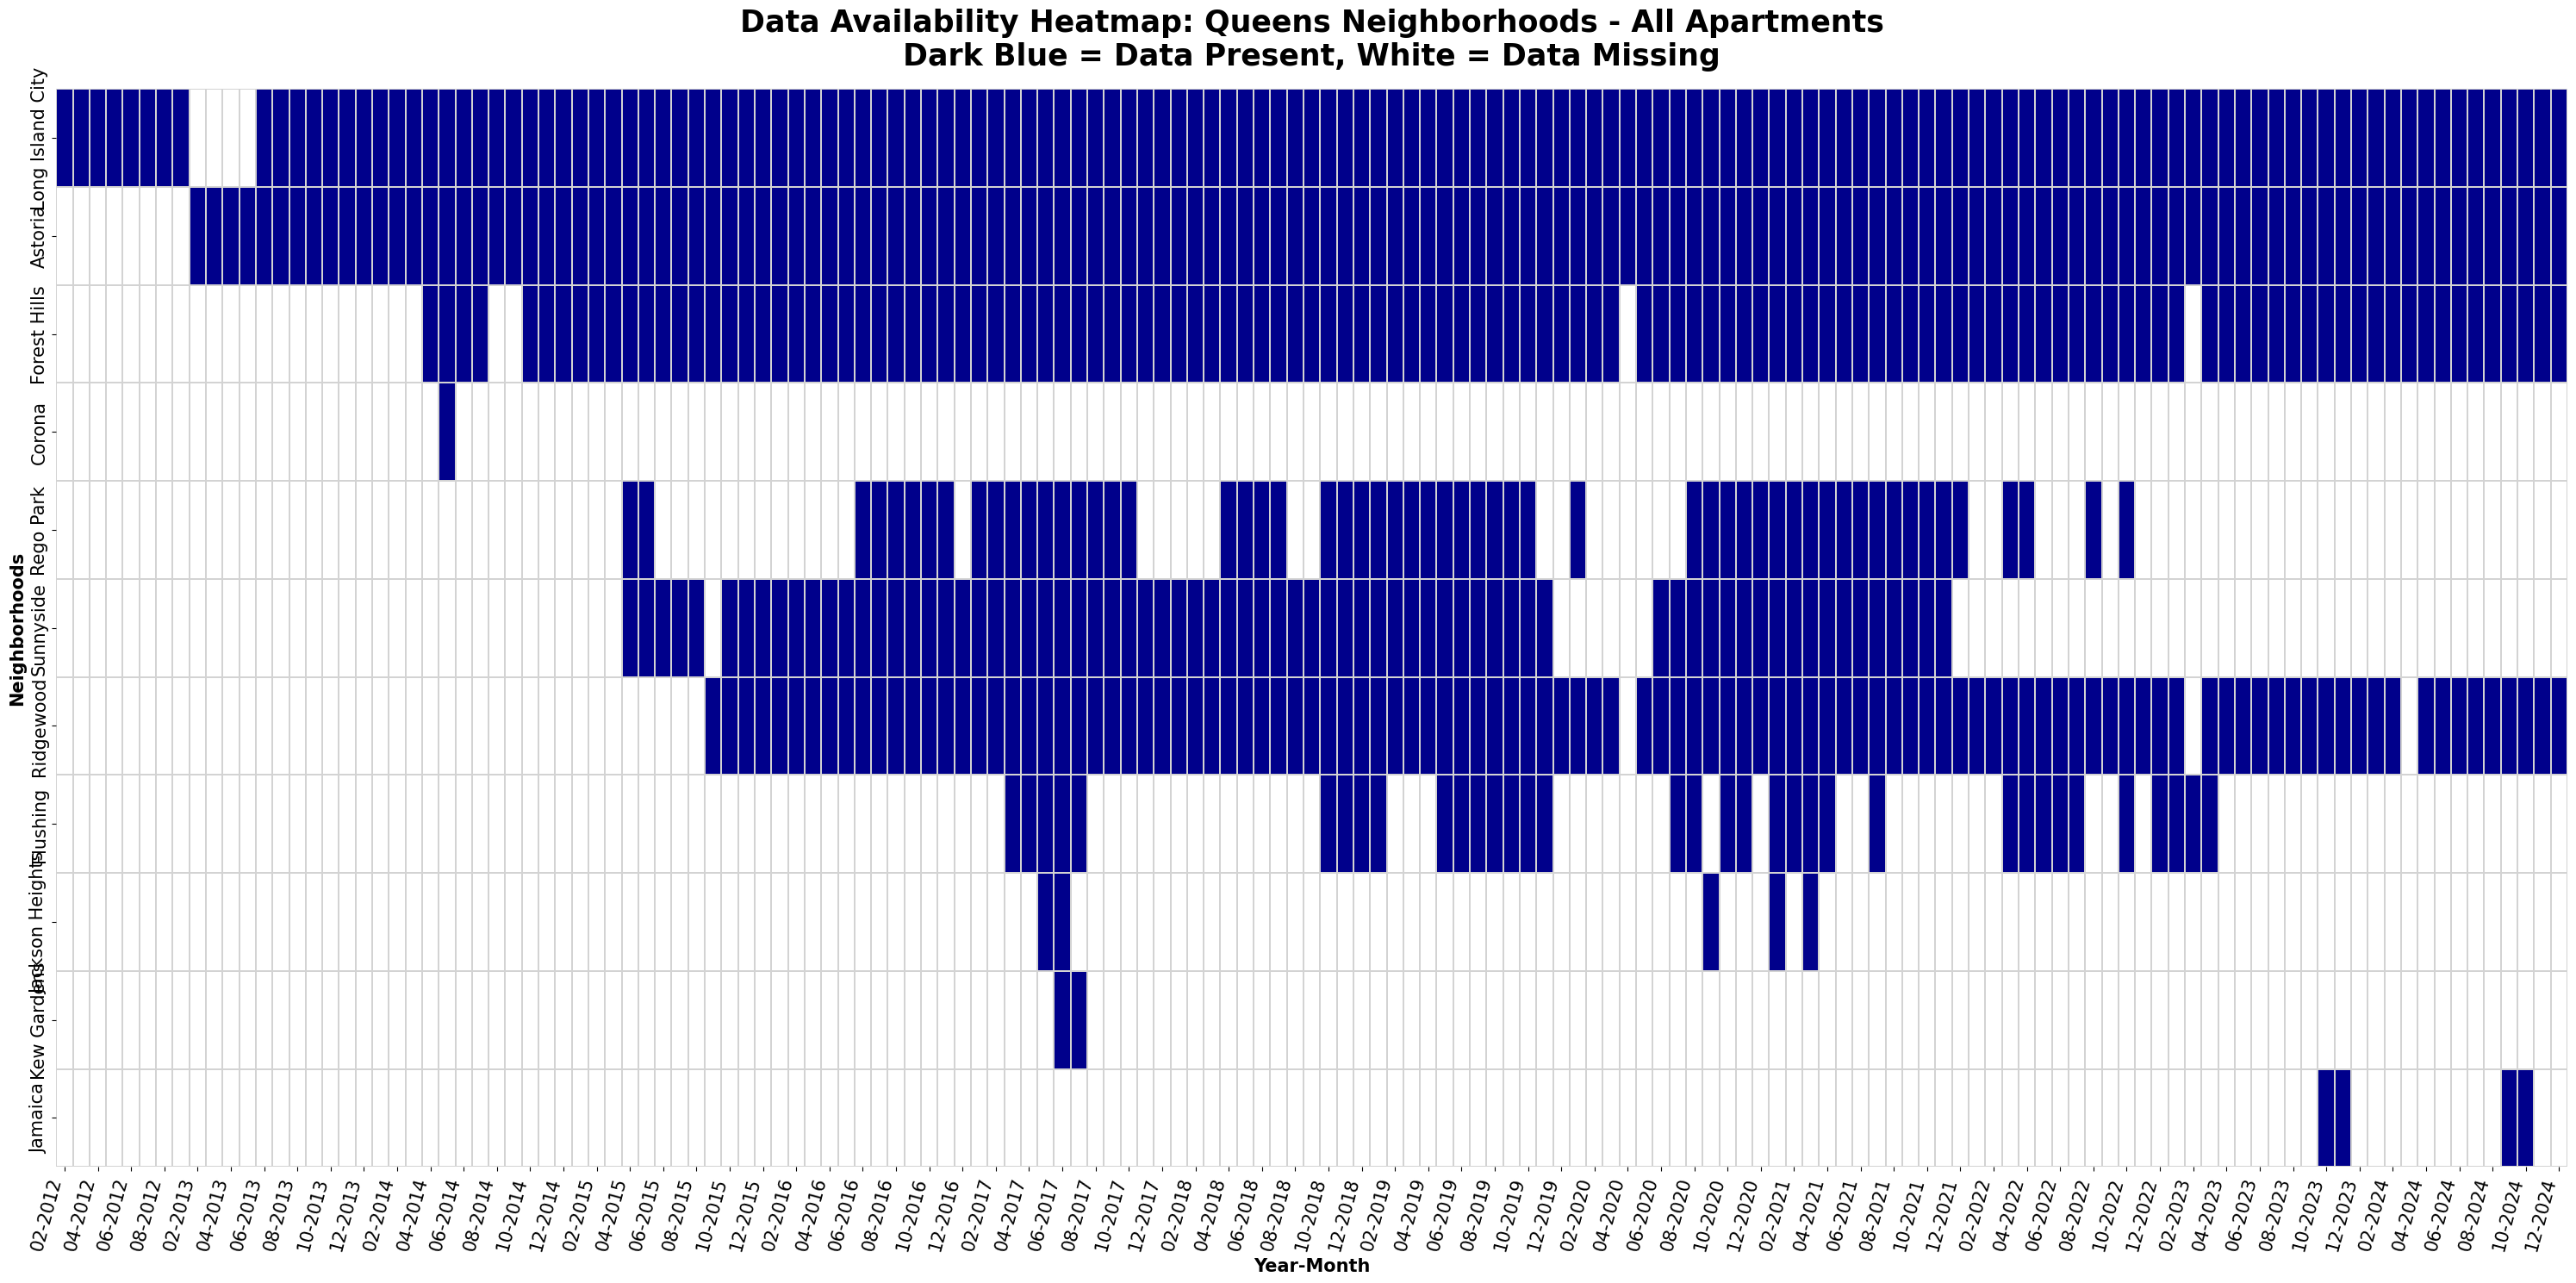

Data Availability Summary for Queens:
Total data points: 1661
Data present: 701.0 (42.2%)
Data missing: 960.0 (57.8%)
Number of neighborhoods: 11
Number of time periods: 151


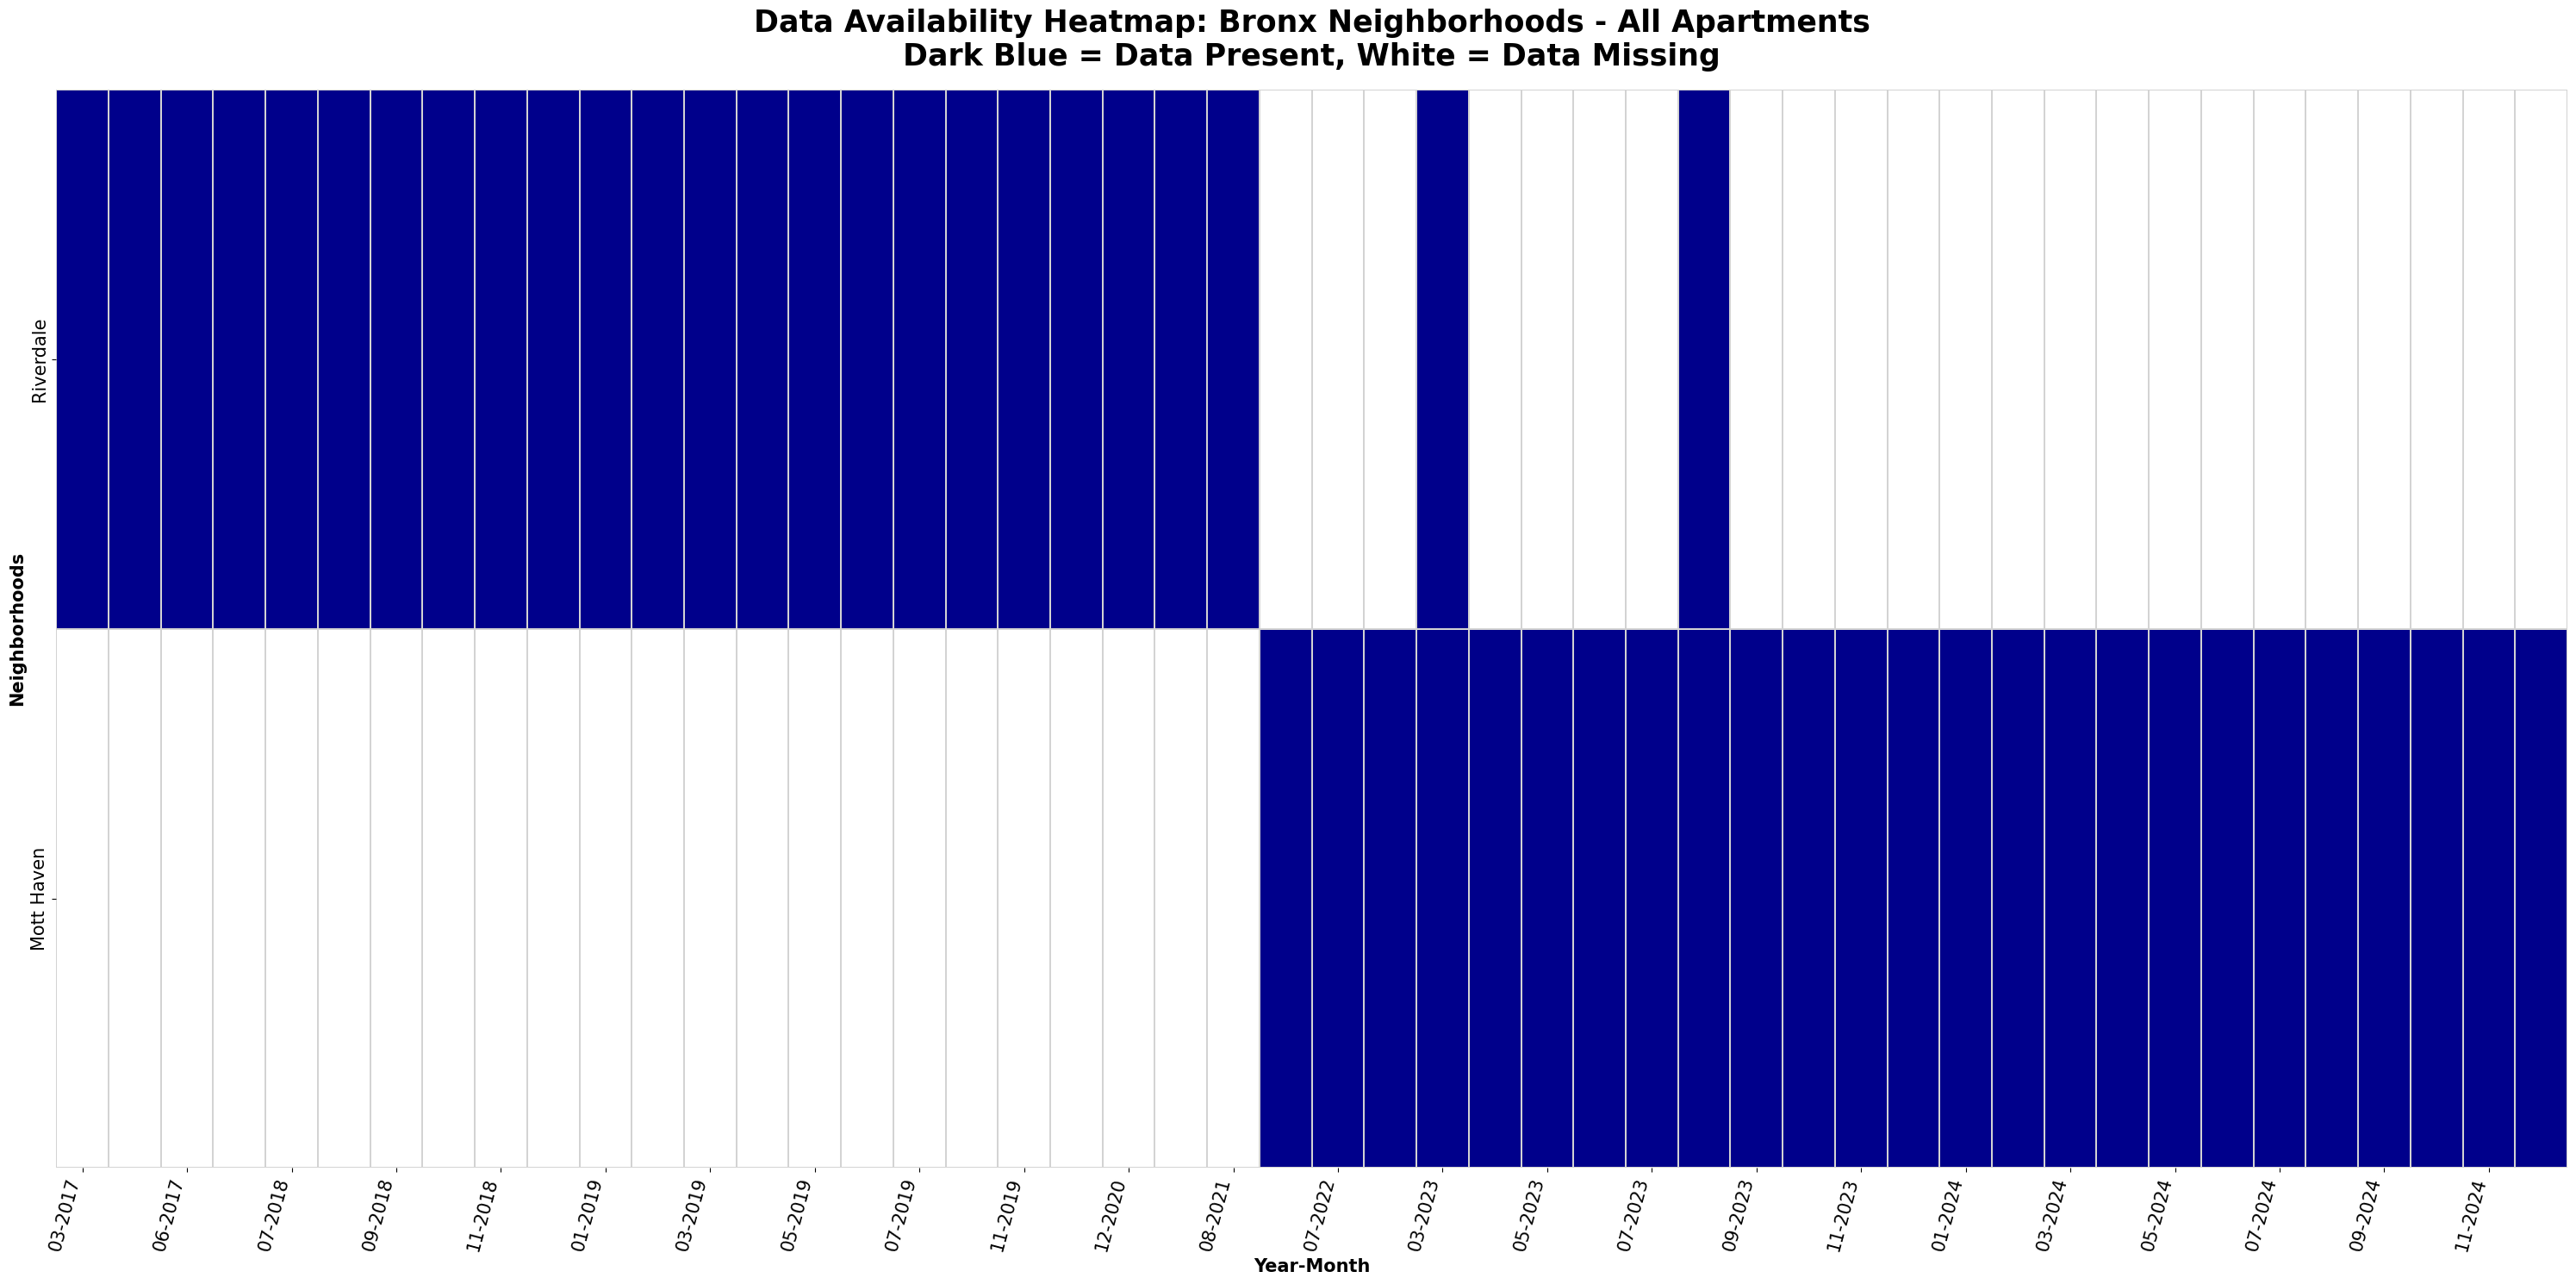

Data Availability Summary for Bronx:
Total data points: 96
Data present: 50.0 (52.1%)
Data missing: 46.0 (47.9%)
Number of neighborhoods: 2
Number of time periods: 48


In [12]:
boroughs = rent_df['borough'].unique()
for borough in boroughs:
        create_data_availability_heatmap(rent_df, borough, apt_type='all', subtitle='All Apartments')

#### 1-Bedroom Apartments

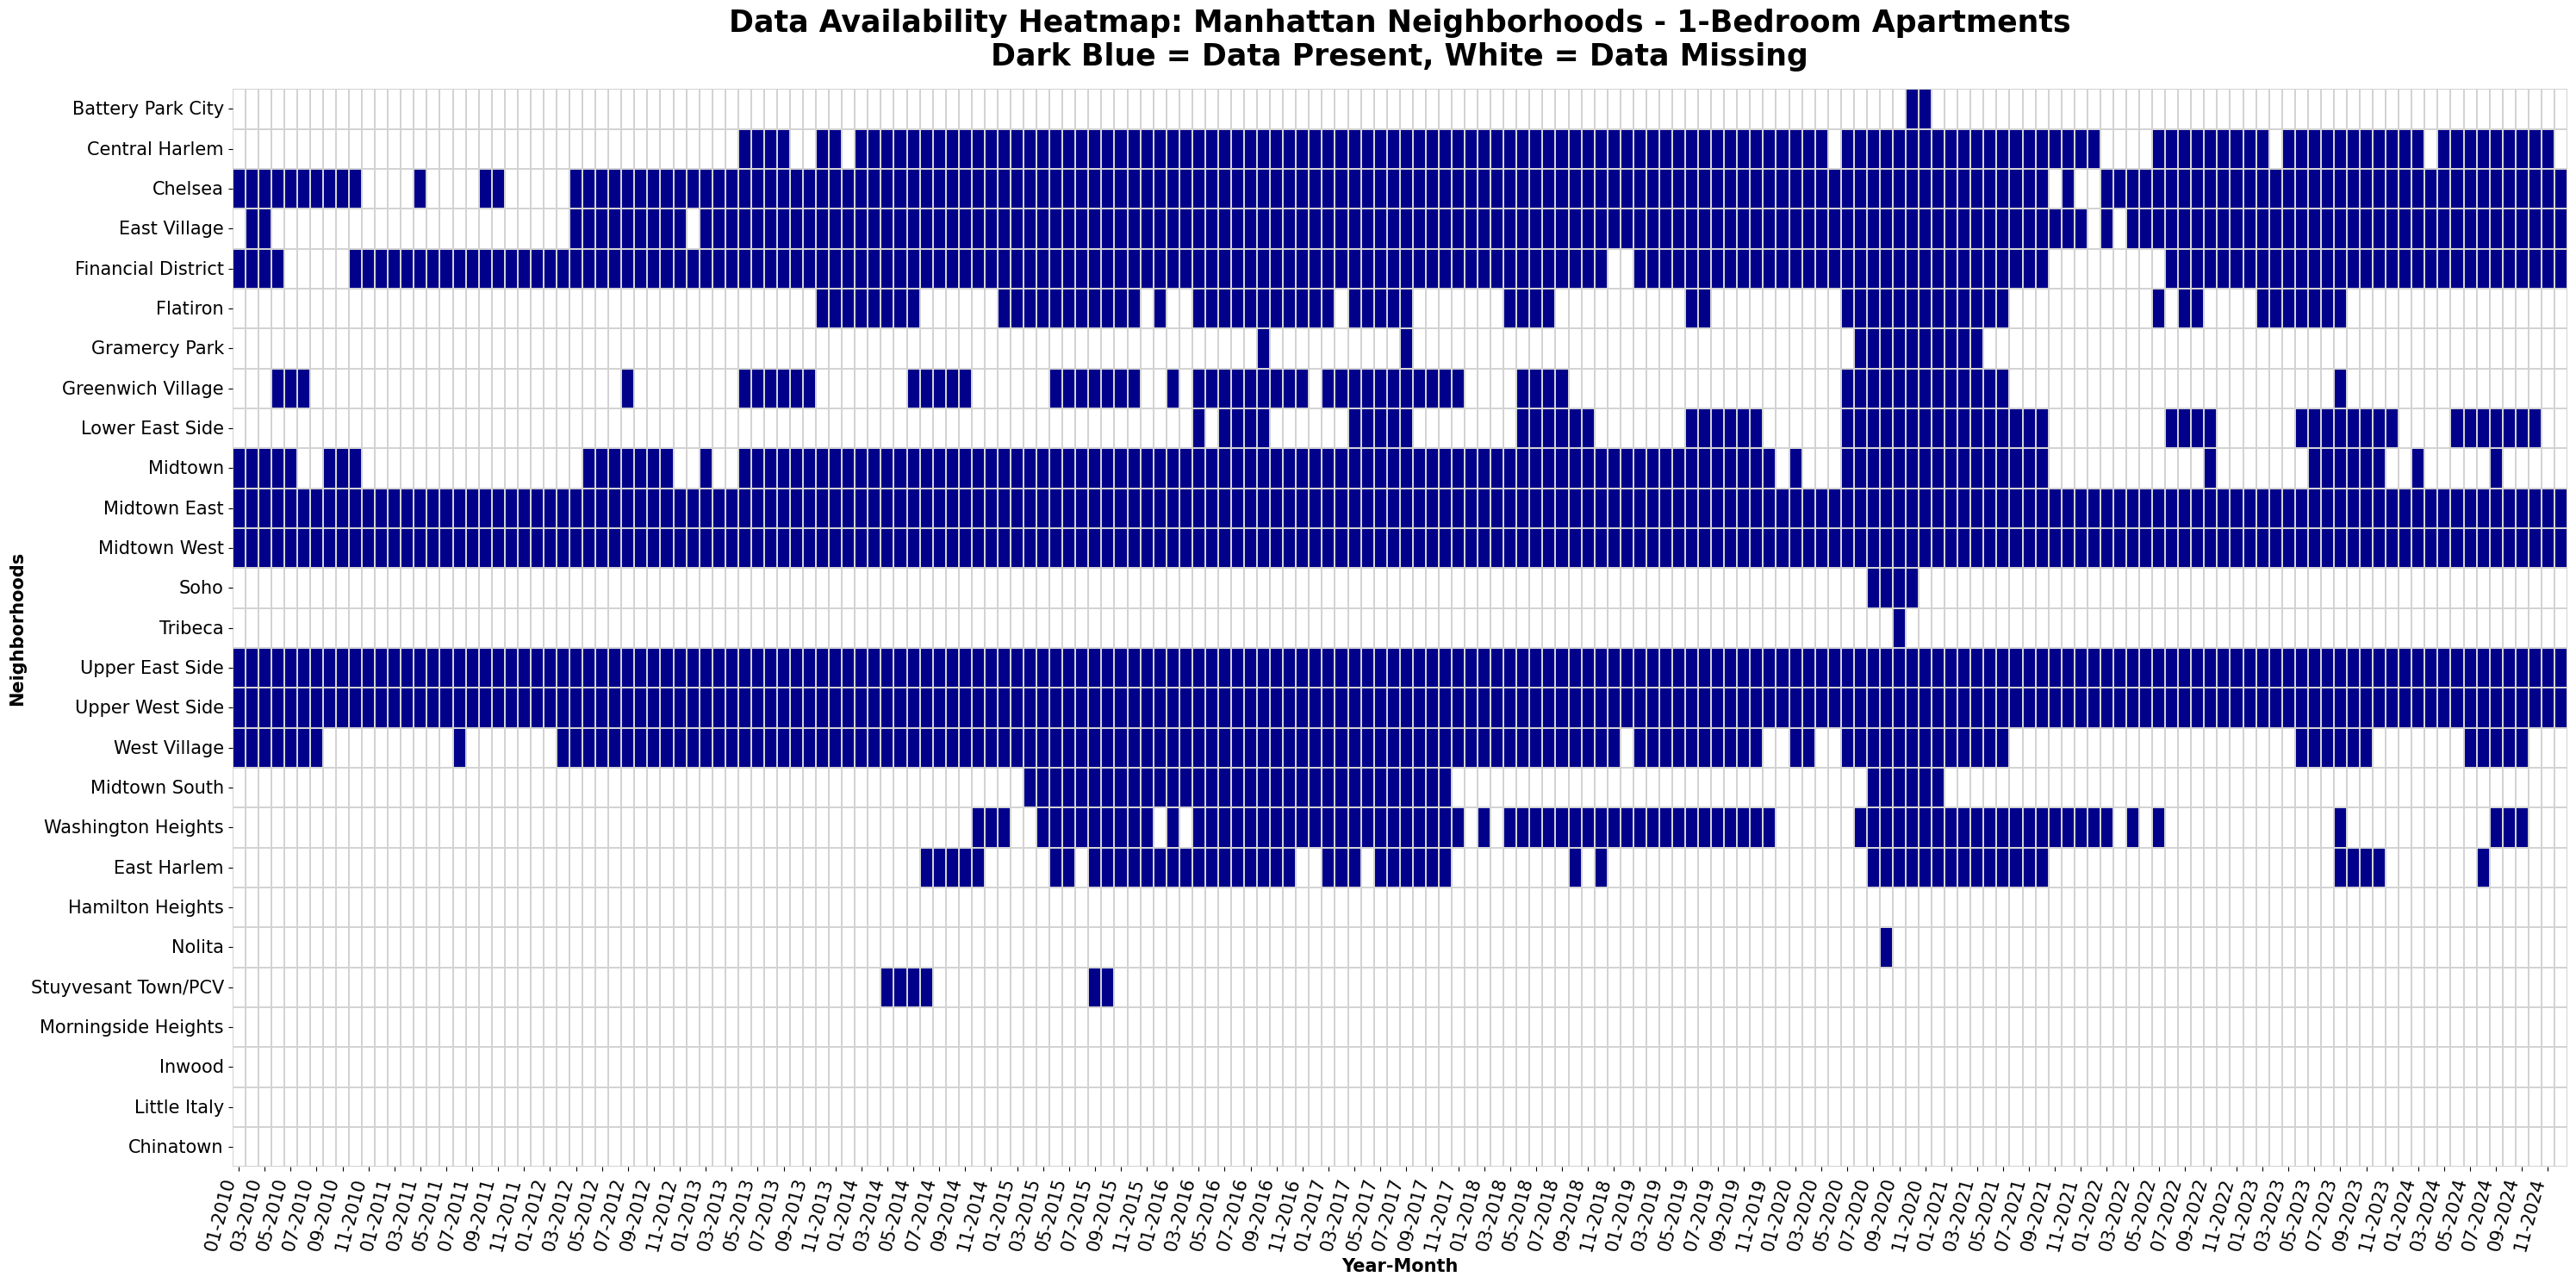

Data Availability Summary for Manhattan:
Total data points: 4860
Data present: 1962.0 (40.4%)
Data missing: 2898.0 (59.6%)
Number of neighborhoods: 27
Number of time periods: 180


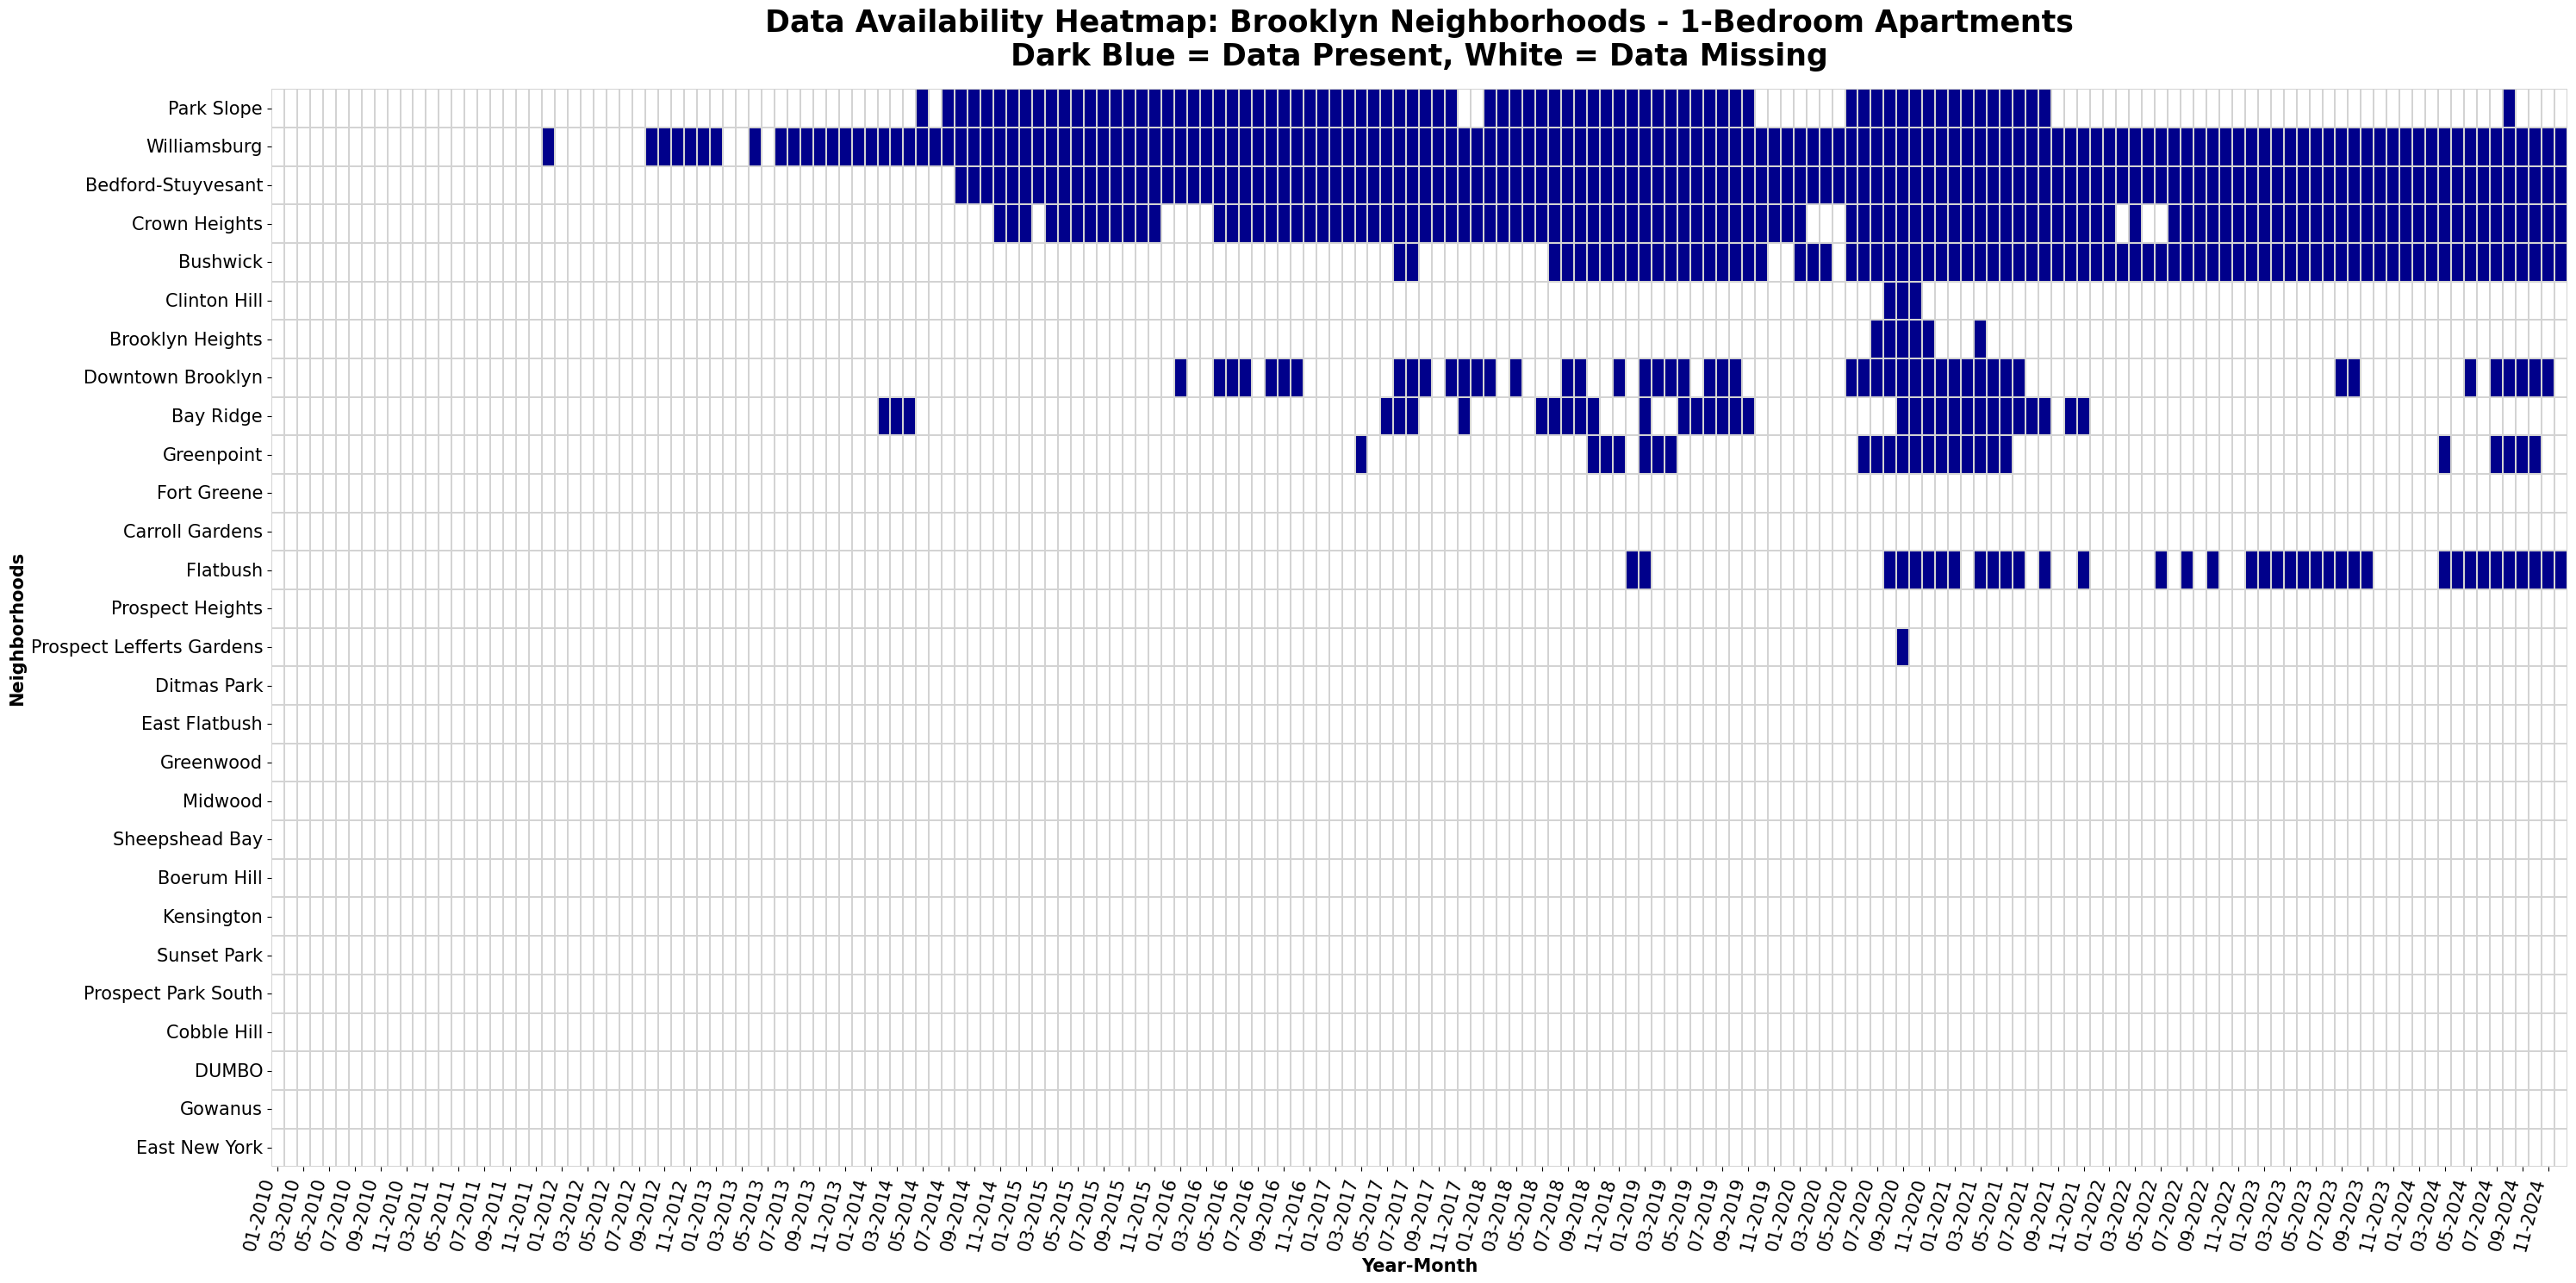

Data Availability Summary for Brooklyn:
Total data points: 4984
Data present: 691.0 (13.9%)
Data missing: 4293.0 (86.1%)
Number of neighborhoods: 28
Number of time periods: 178


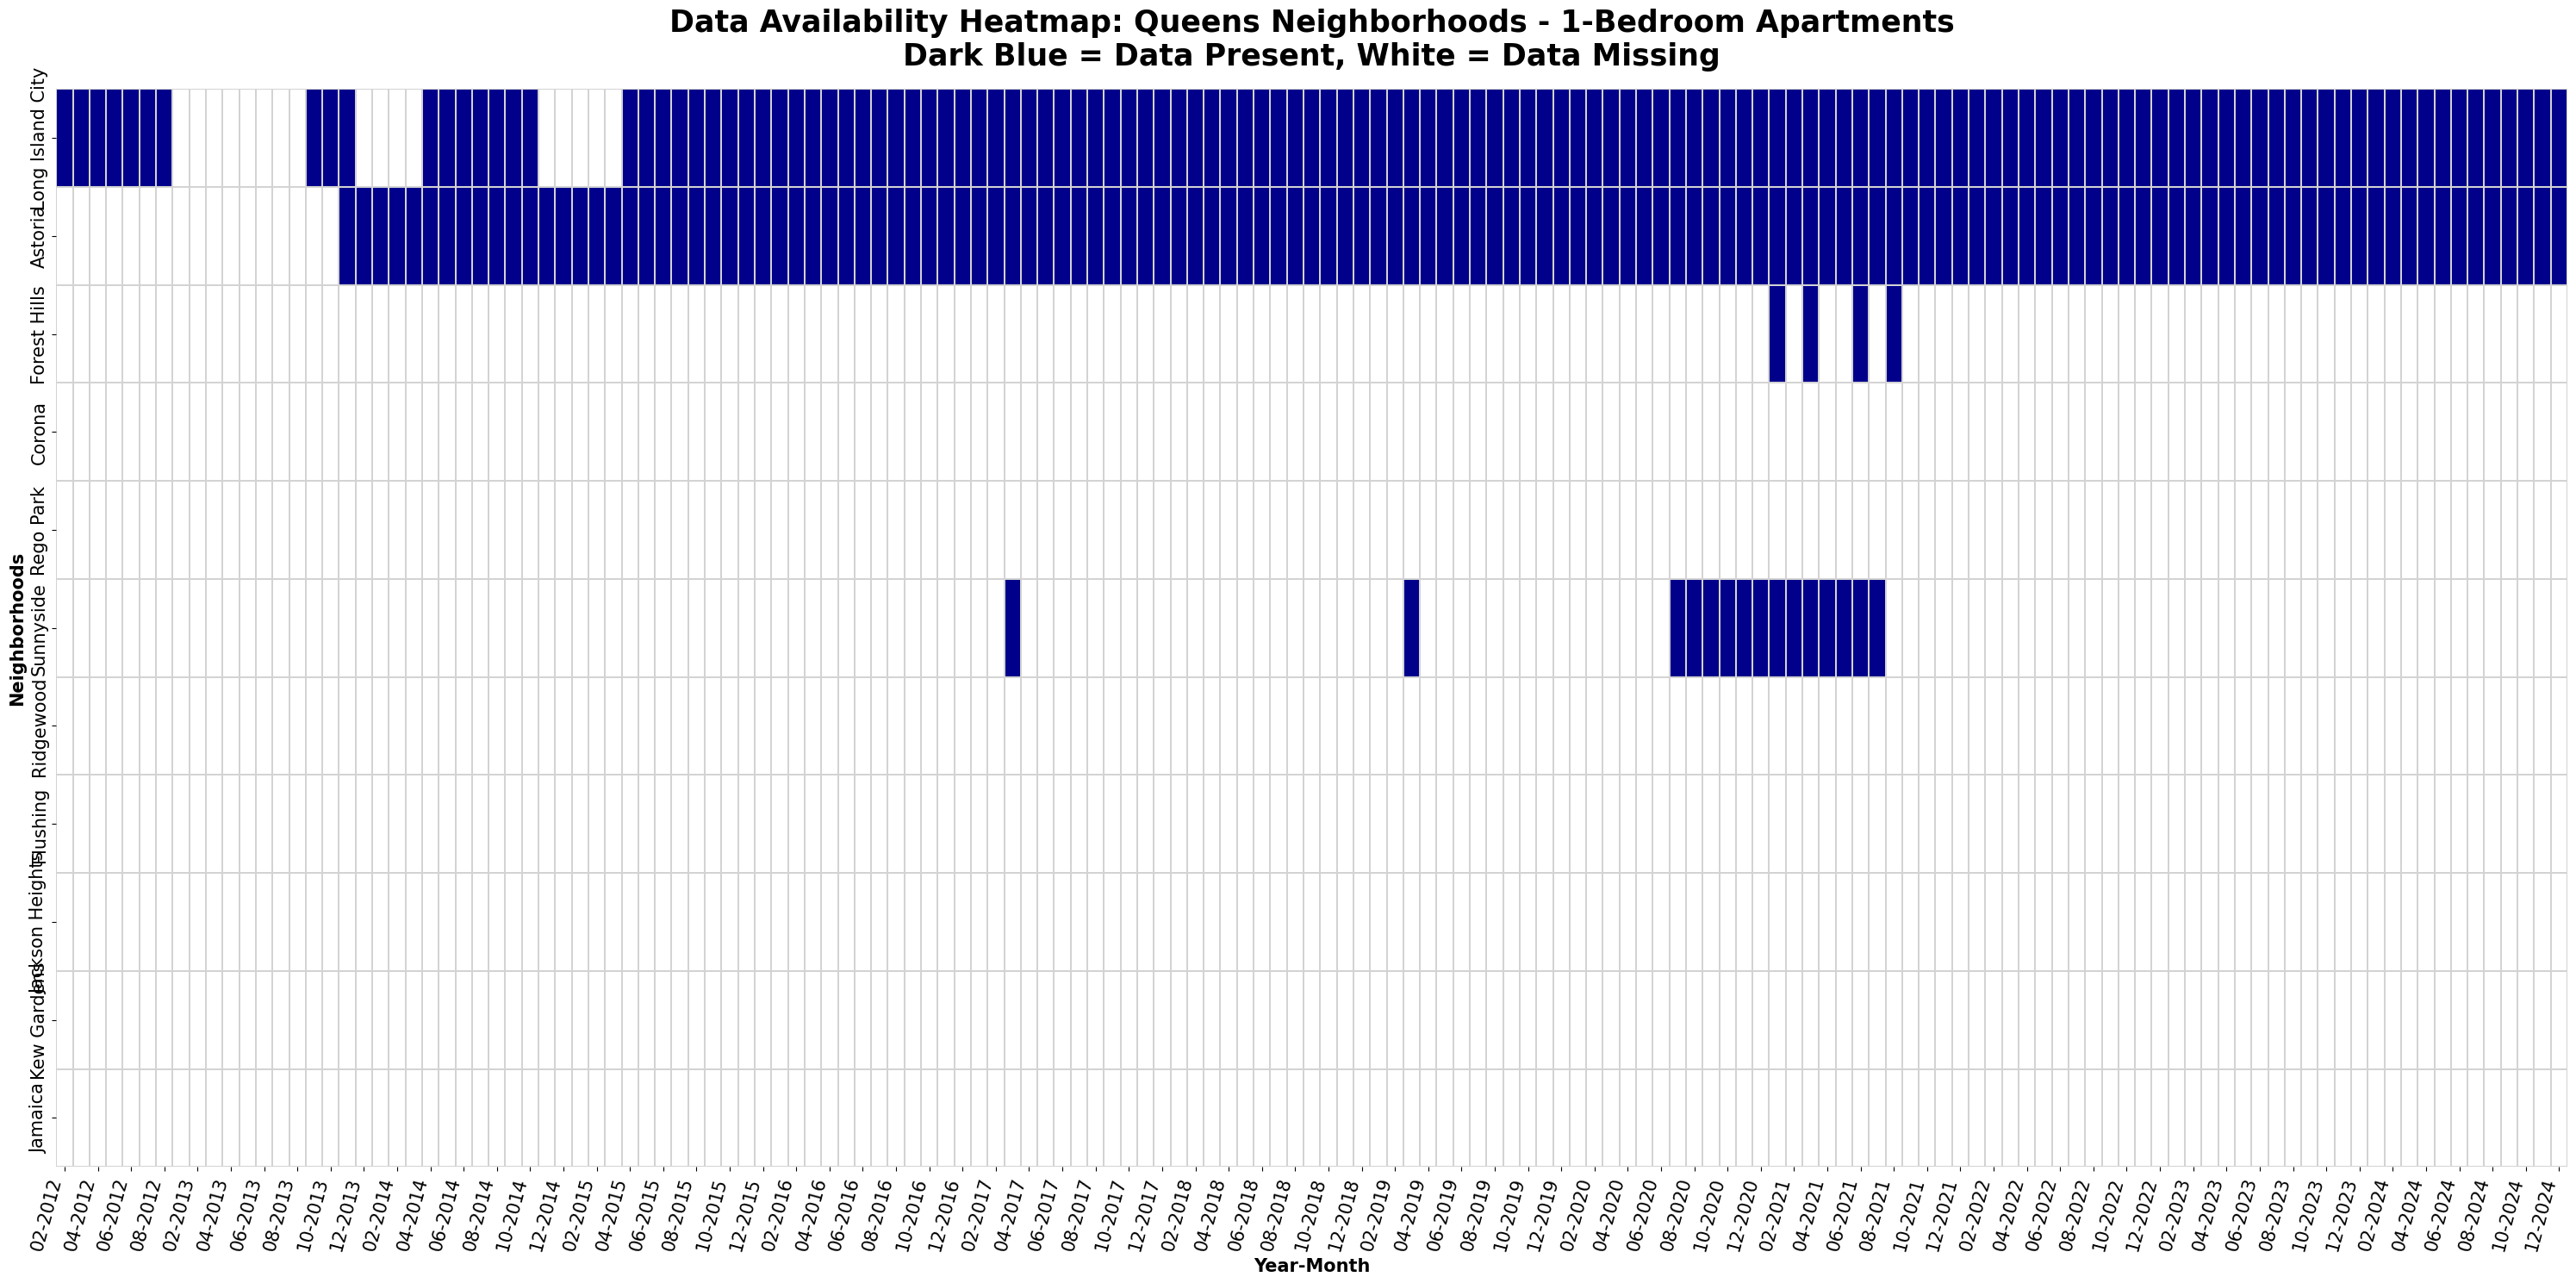

Data Availability Summary for Queens:
Total data points: 1661
Data present: 287.0 (17.3%)
Data missing: 1374.0 (82.7%)
Number of neighborhoods: 11
Number of time periods: 151


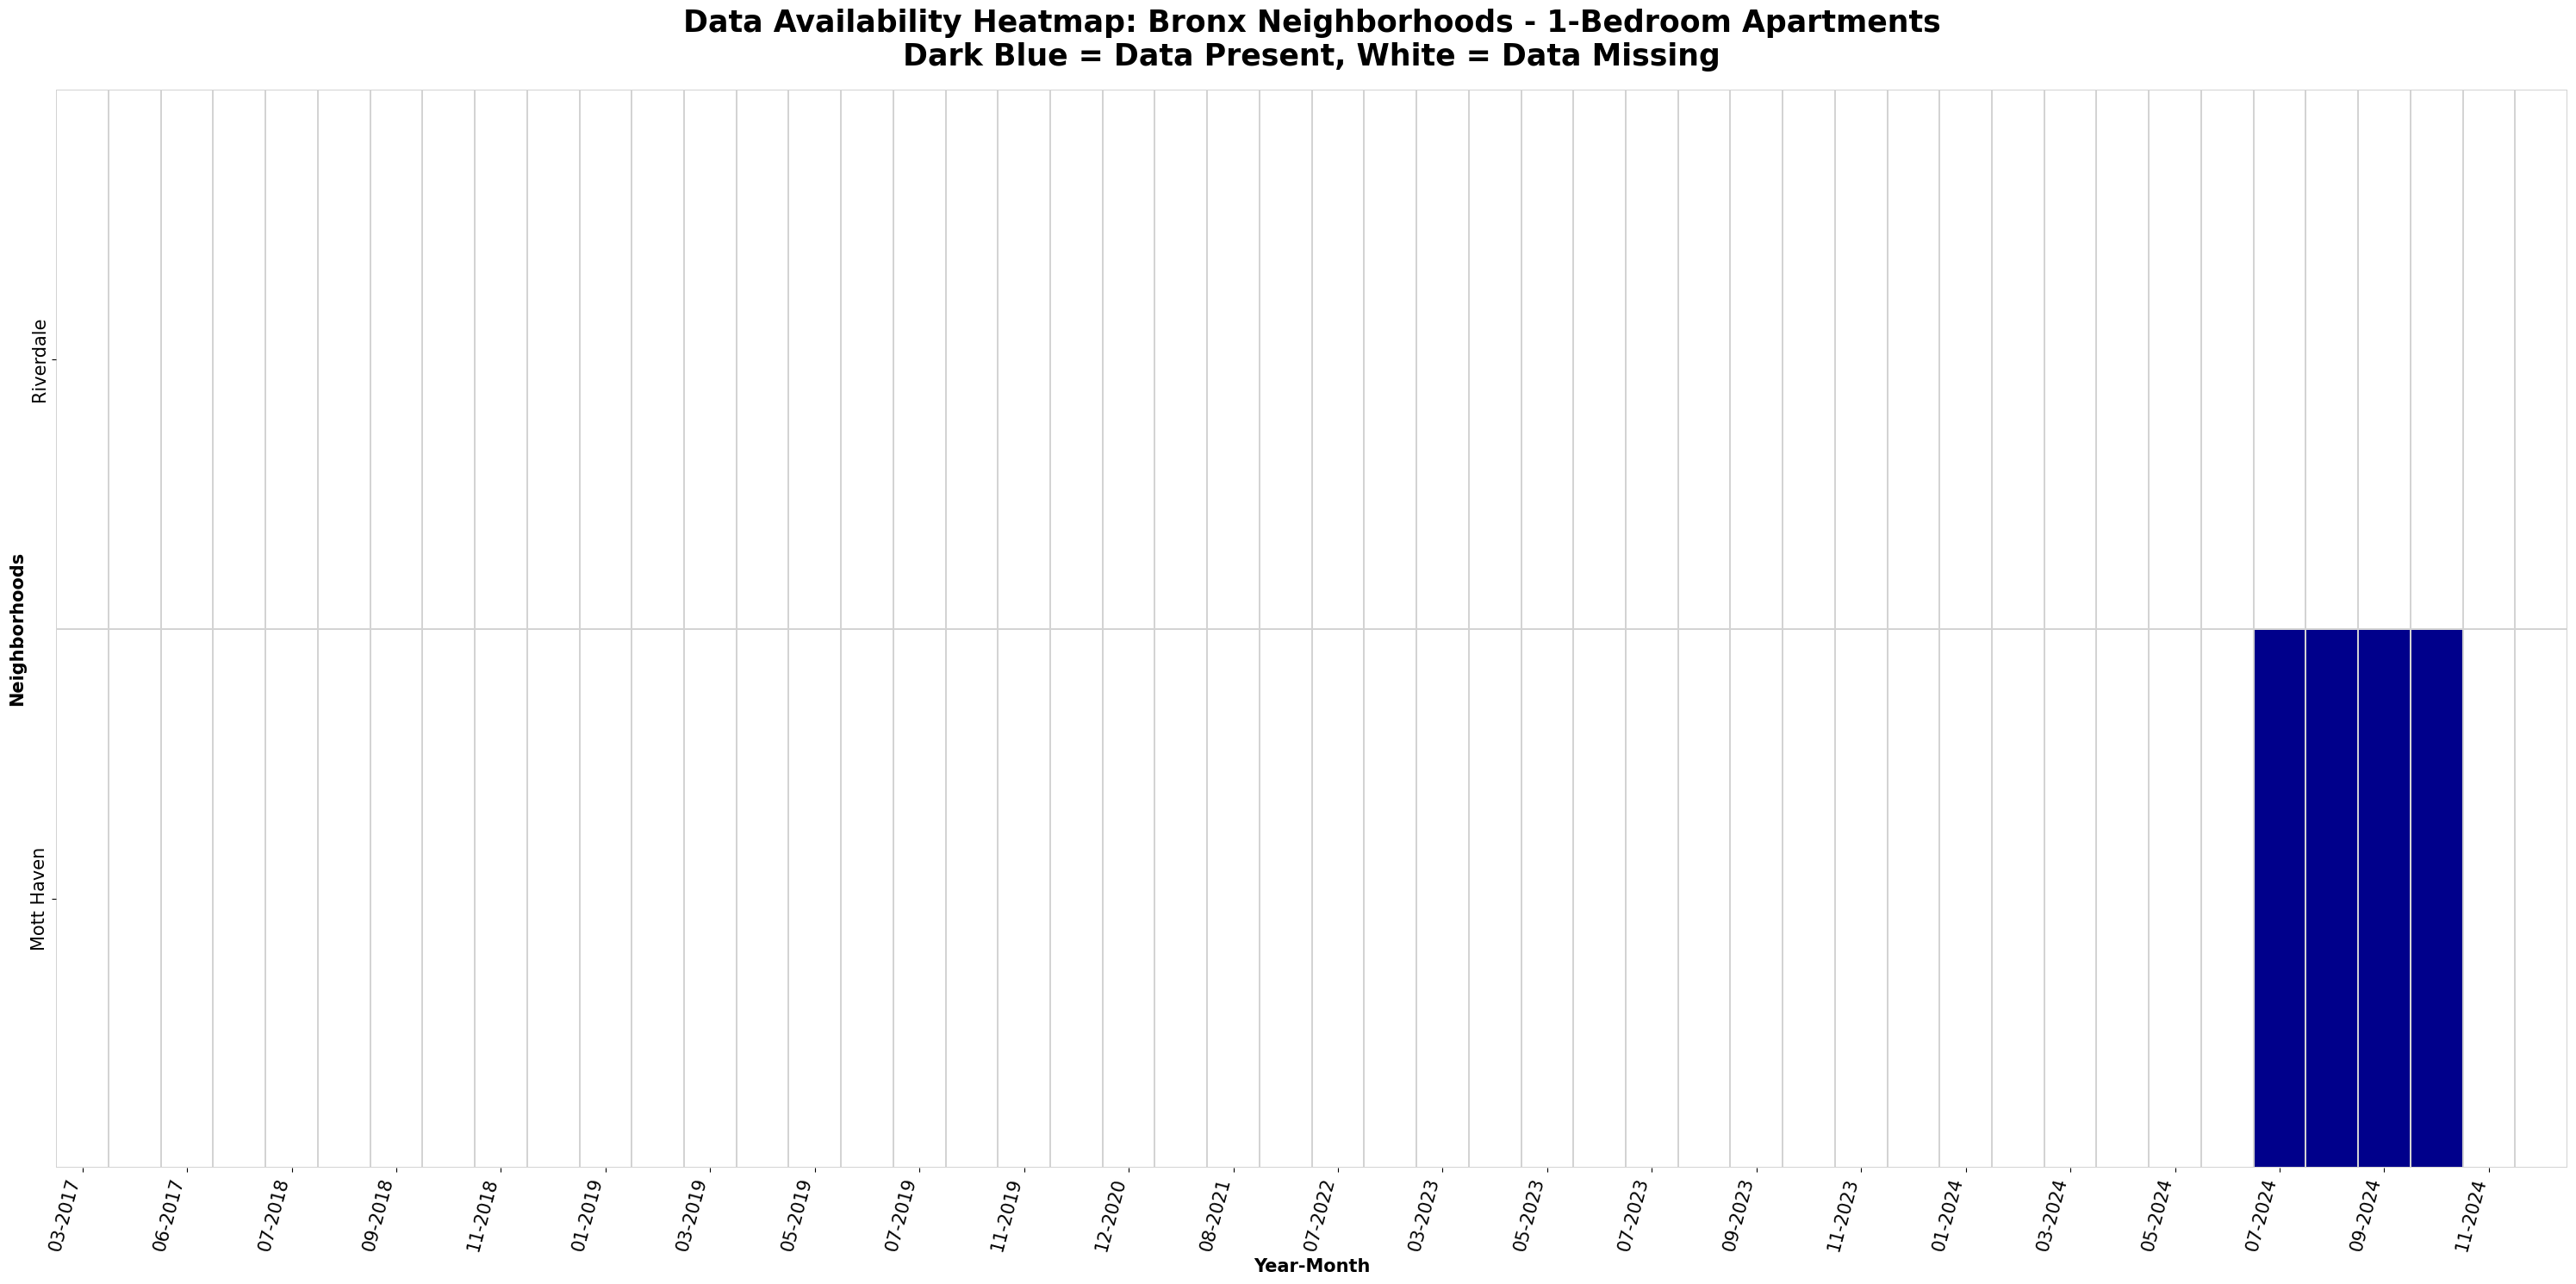

Data Availability Summary for Bronx:
Total data points: 96
Data present: 4.0 (4.2%)
Data missing: 92.0 (95.8%)
Number of neighborhoods: 2
Number of time periods: 48


In [13]:
for borough in boroughs:
    create_data_availability_heatmap(rent_df, borough, apt_type='1bdr', subtitle='1-Bedroom Apartments')

#### 3-Bedroom Apartments

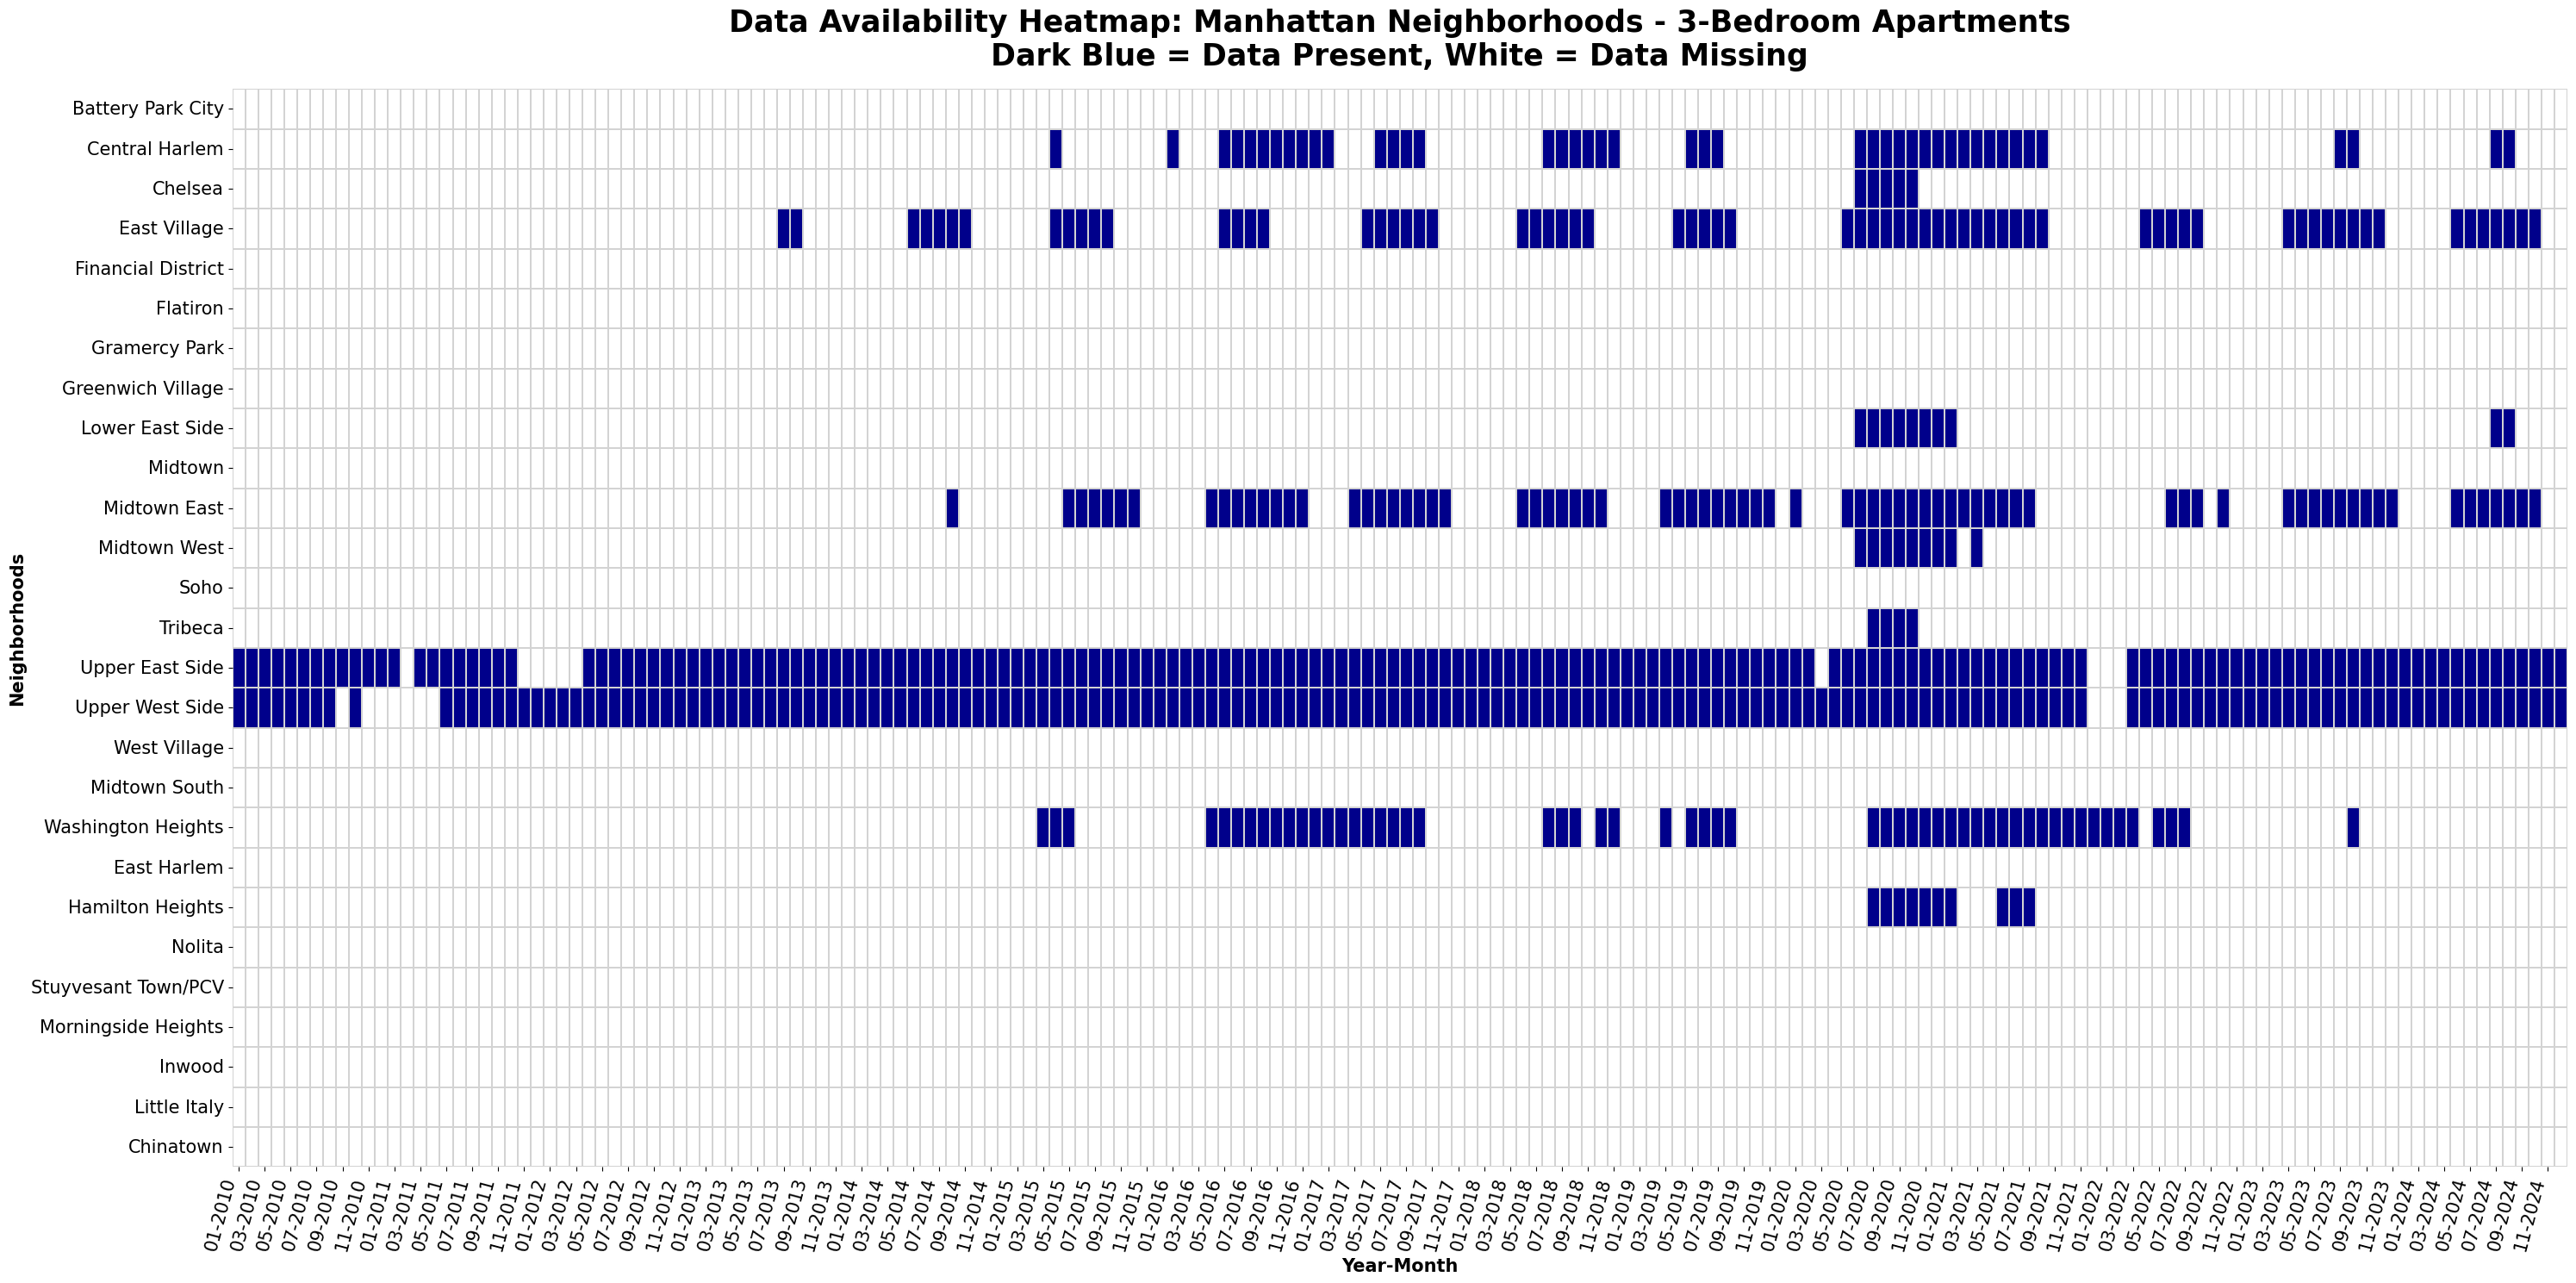

Data Availability Summary for Manhattan:
Total data points: 4860
Data present: 620.0 (12.8%)
Data missing: 4240.0 (87.2%)
Number of neighborhoods: 27
Number of time periods: 180


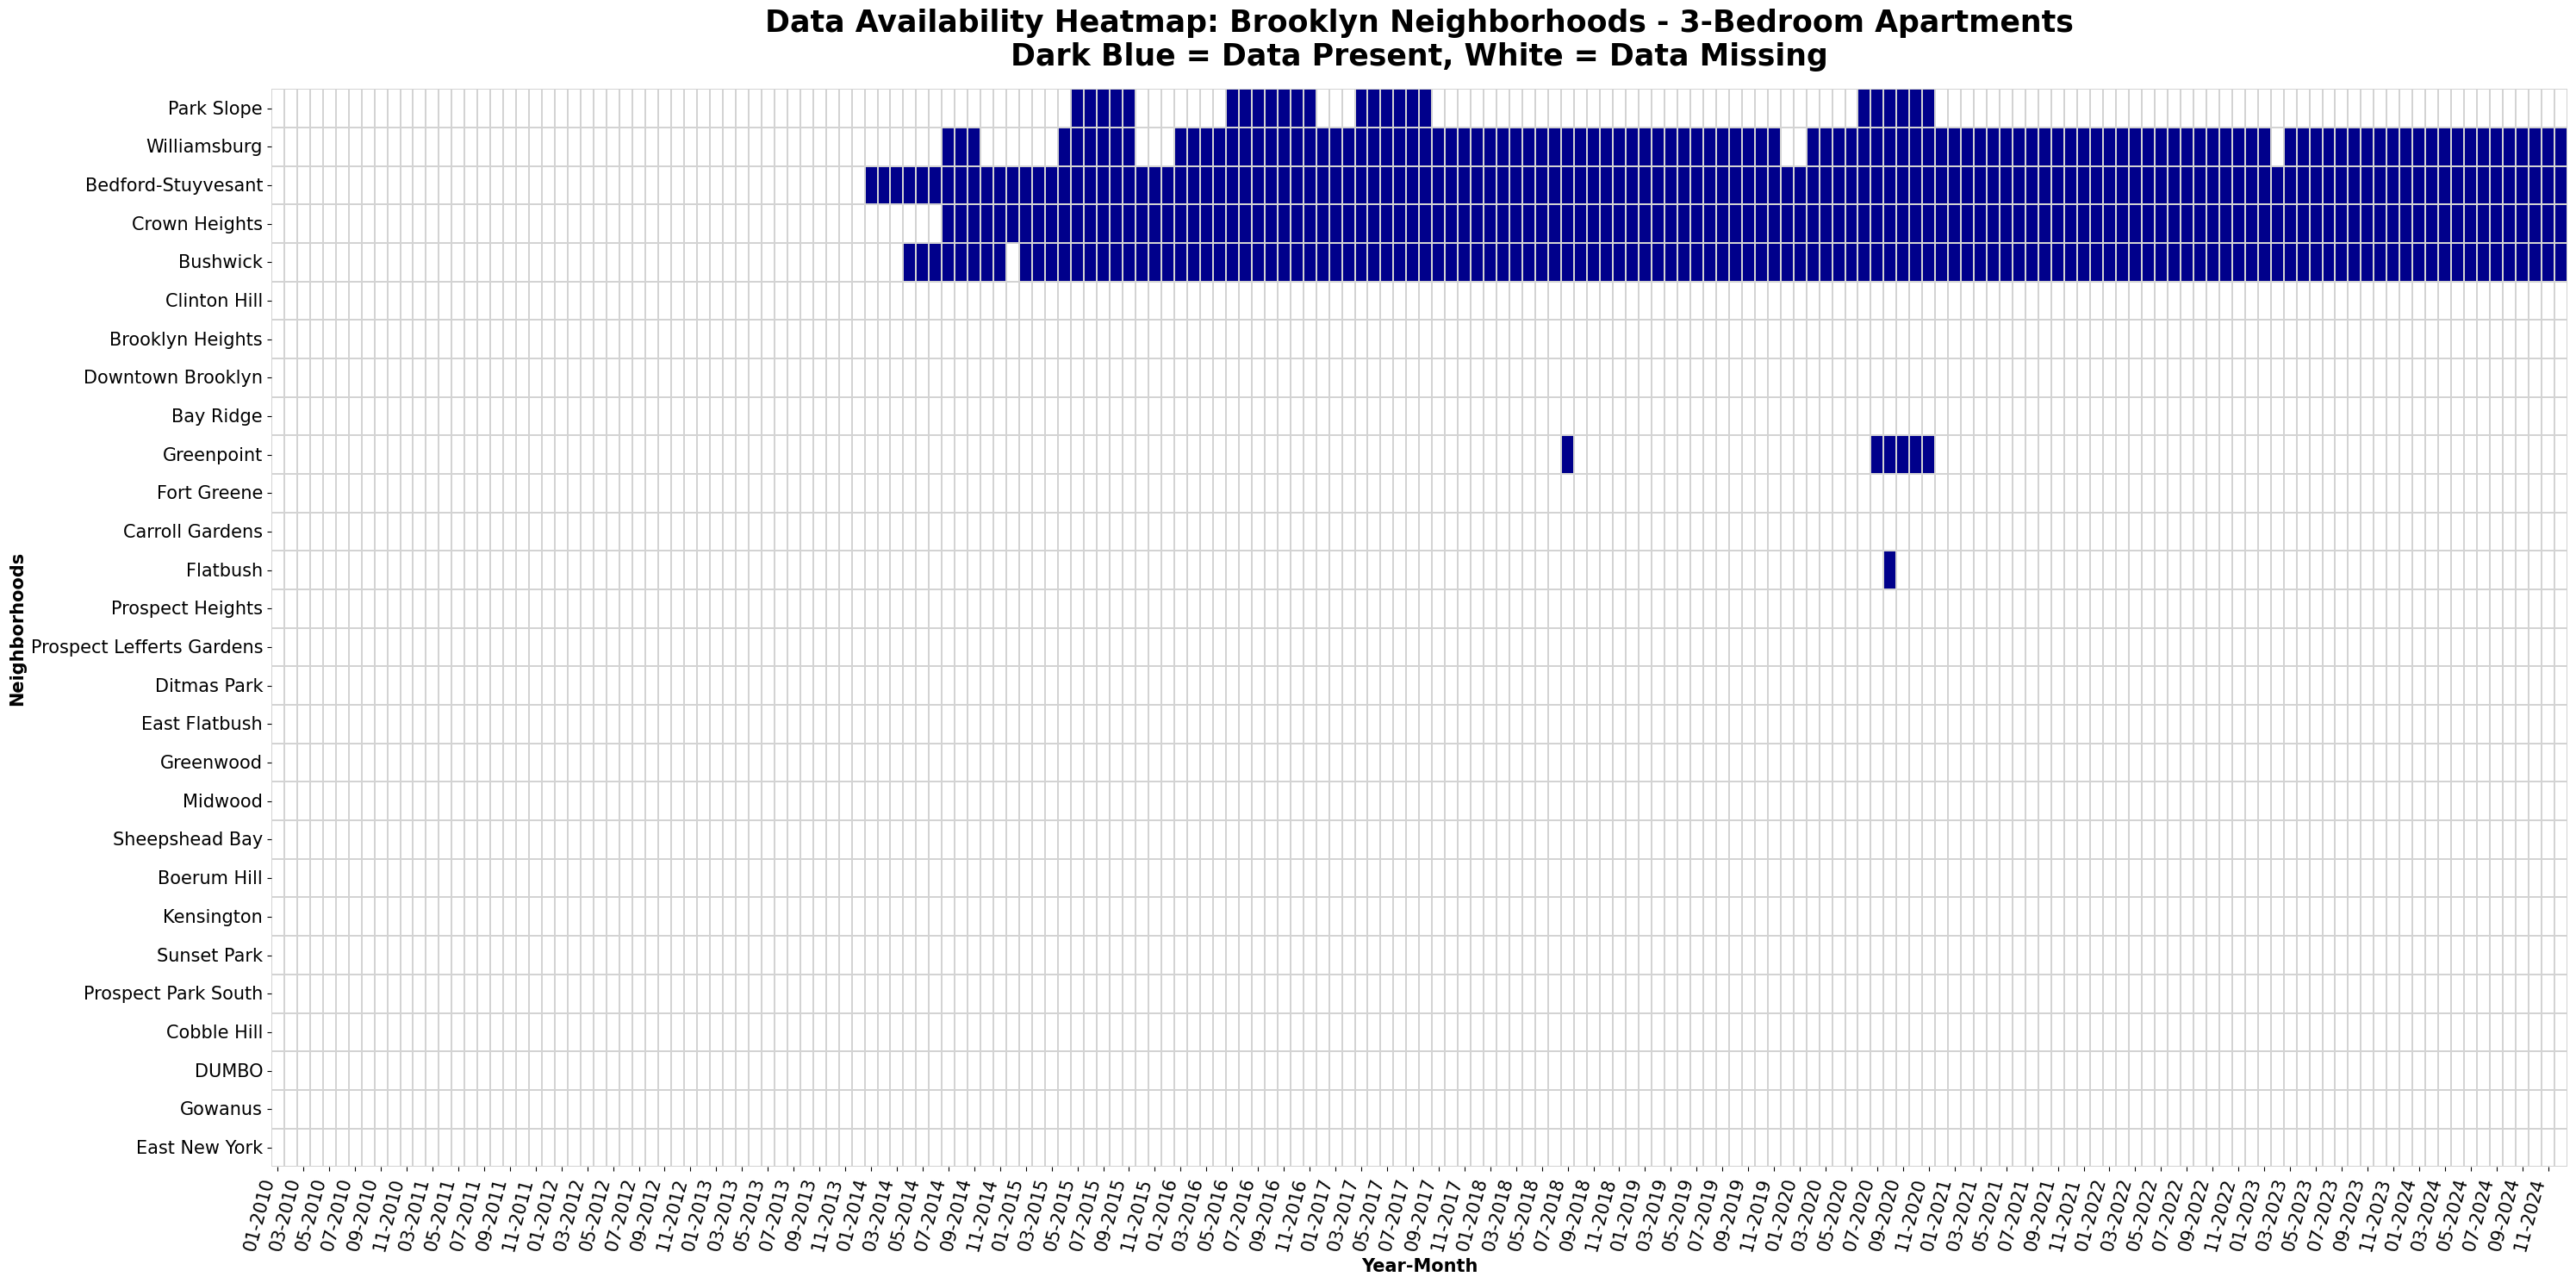

Data Availability Summary for Brooklyn:
Total data points: 4984
Data present: 531.0 (10.7%)
Data missing: 4453.0 (89.3%)
Number of neighborhoods: 28
Number of time periods: 178


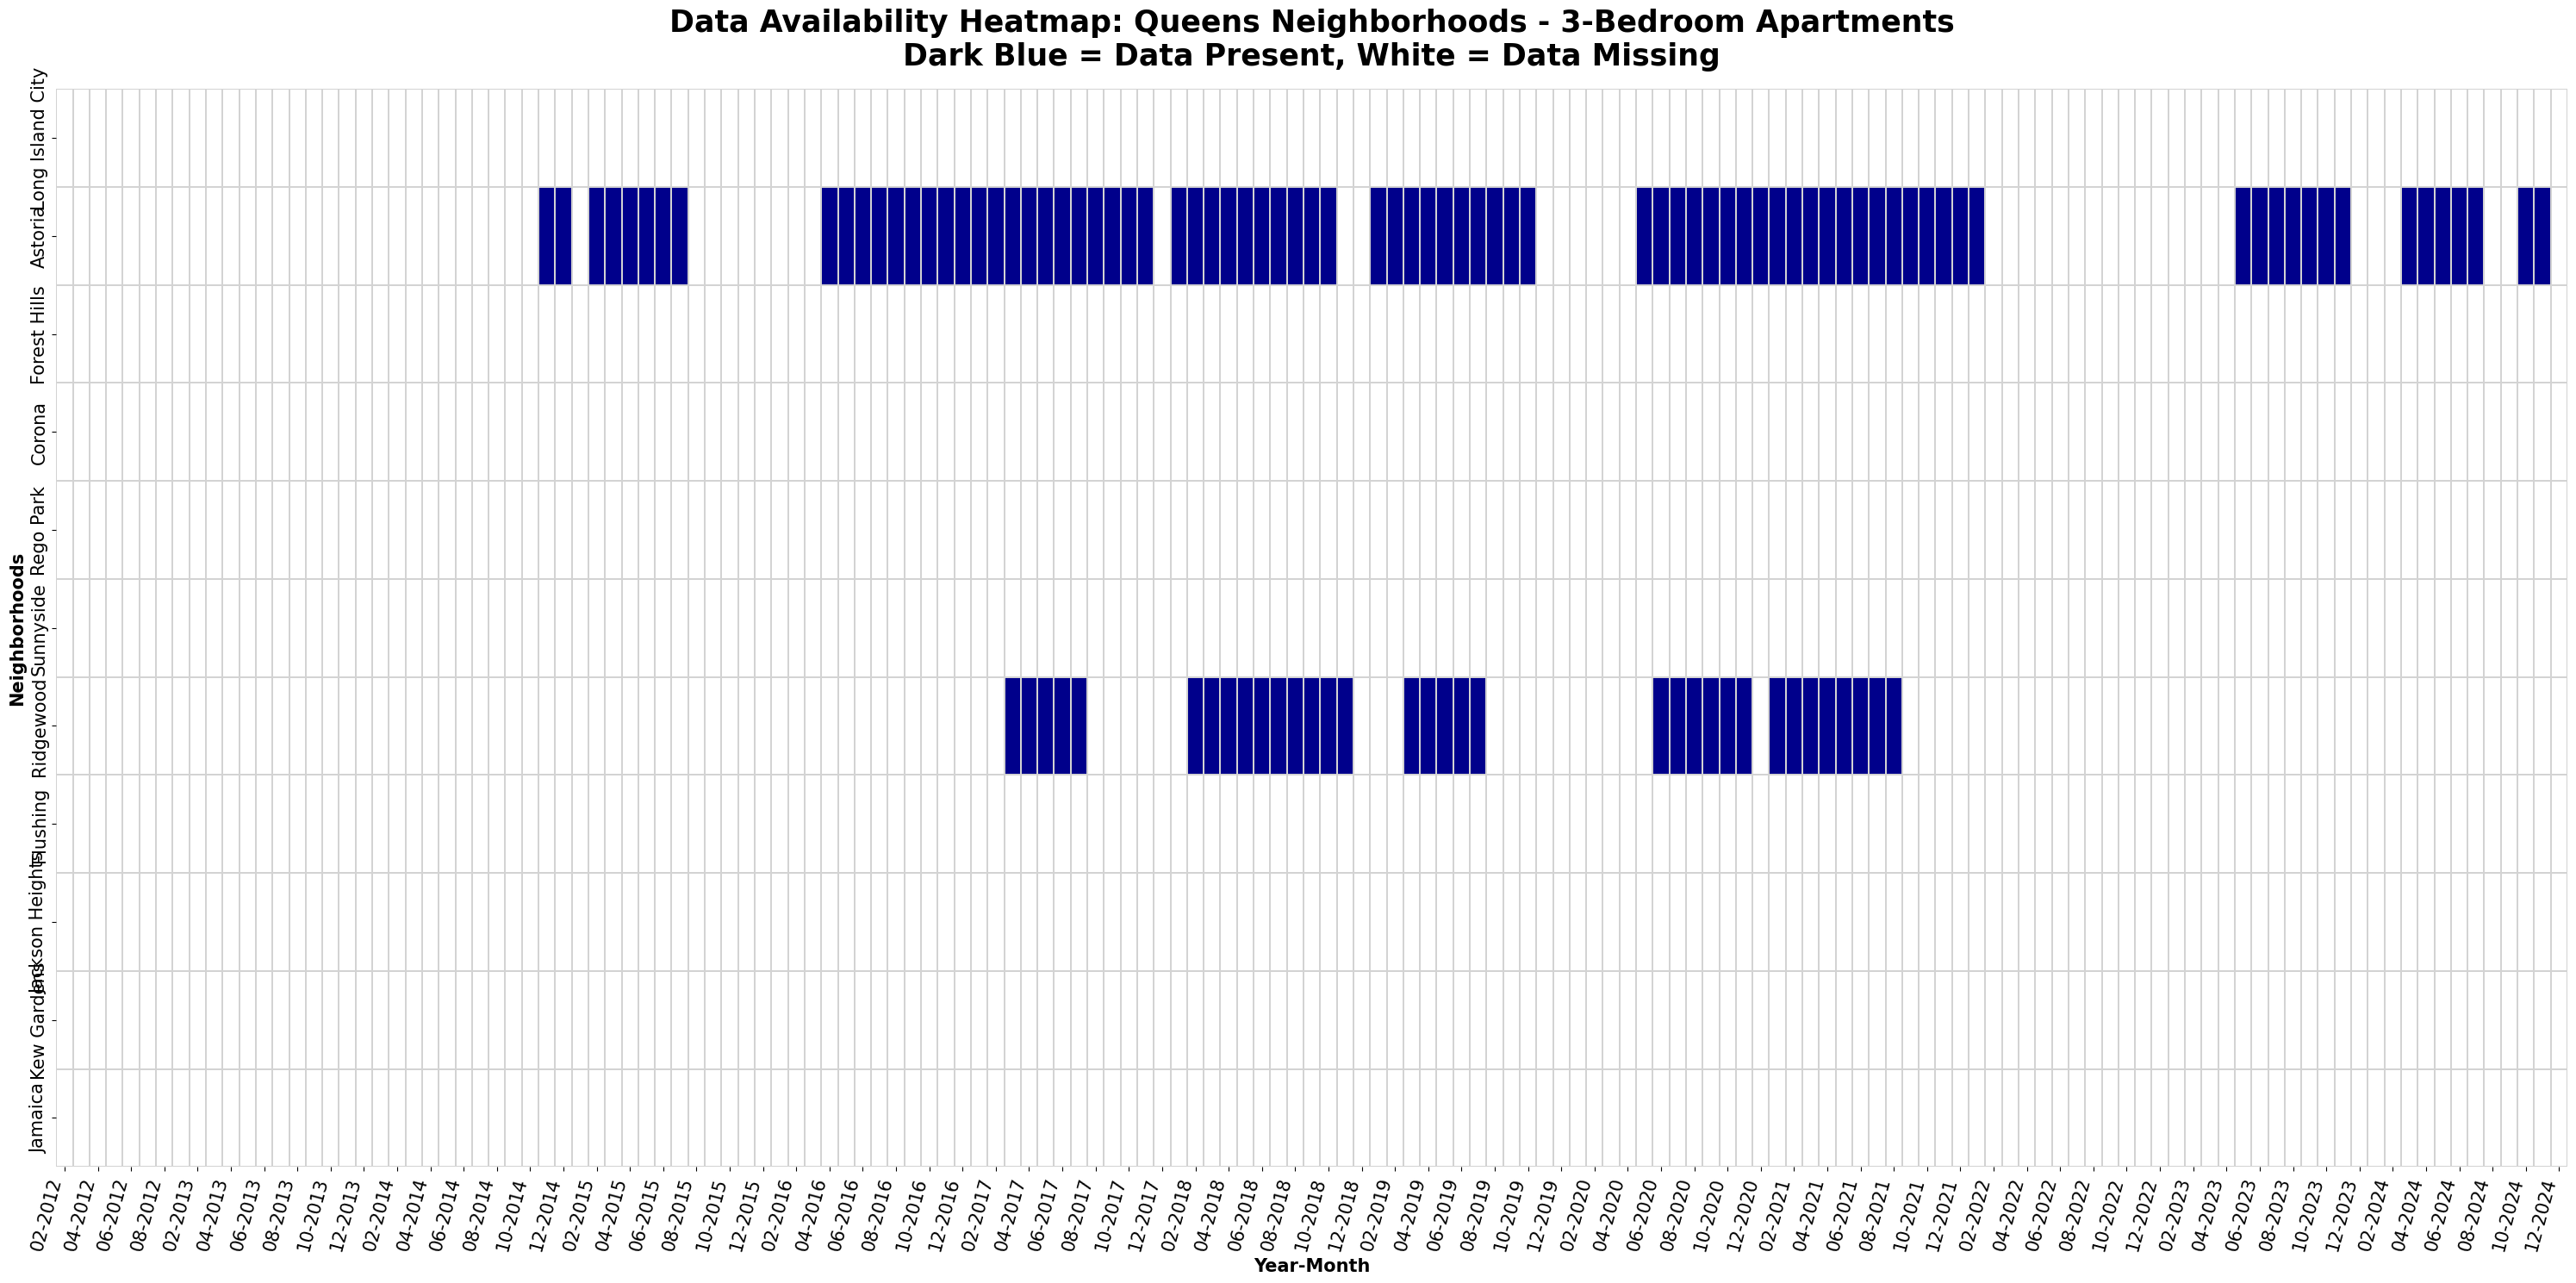

Data Availability Summary for Queens:
Total data points: 1661
Data present: 117.0 (7.0%)
Data missing: 1544.0 (93.0%)
Number of neighborhoods: 11
Number of time periods: 151


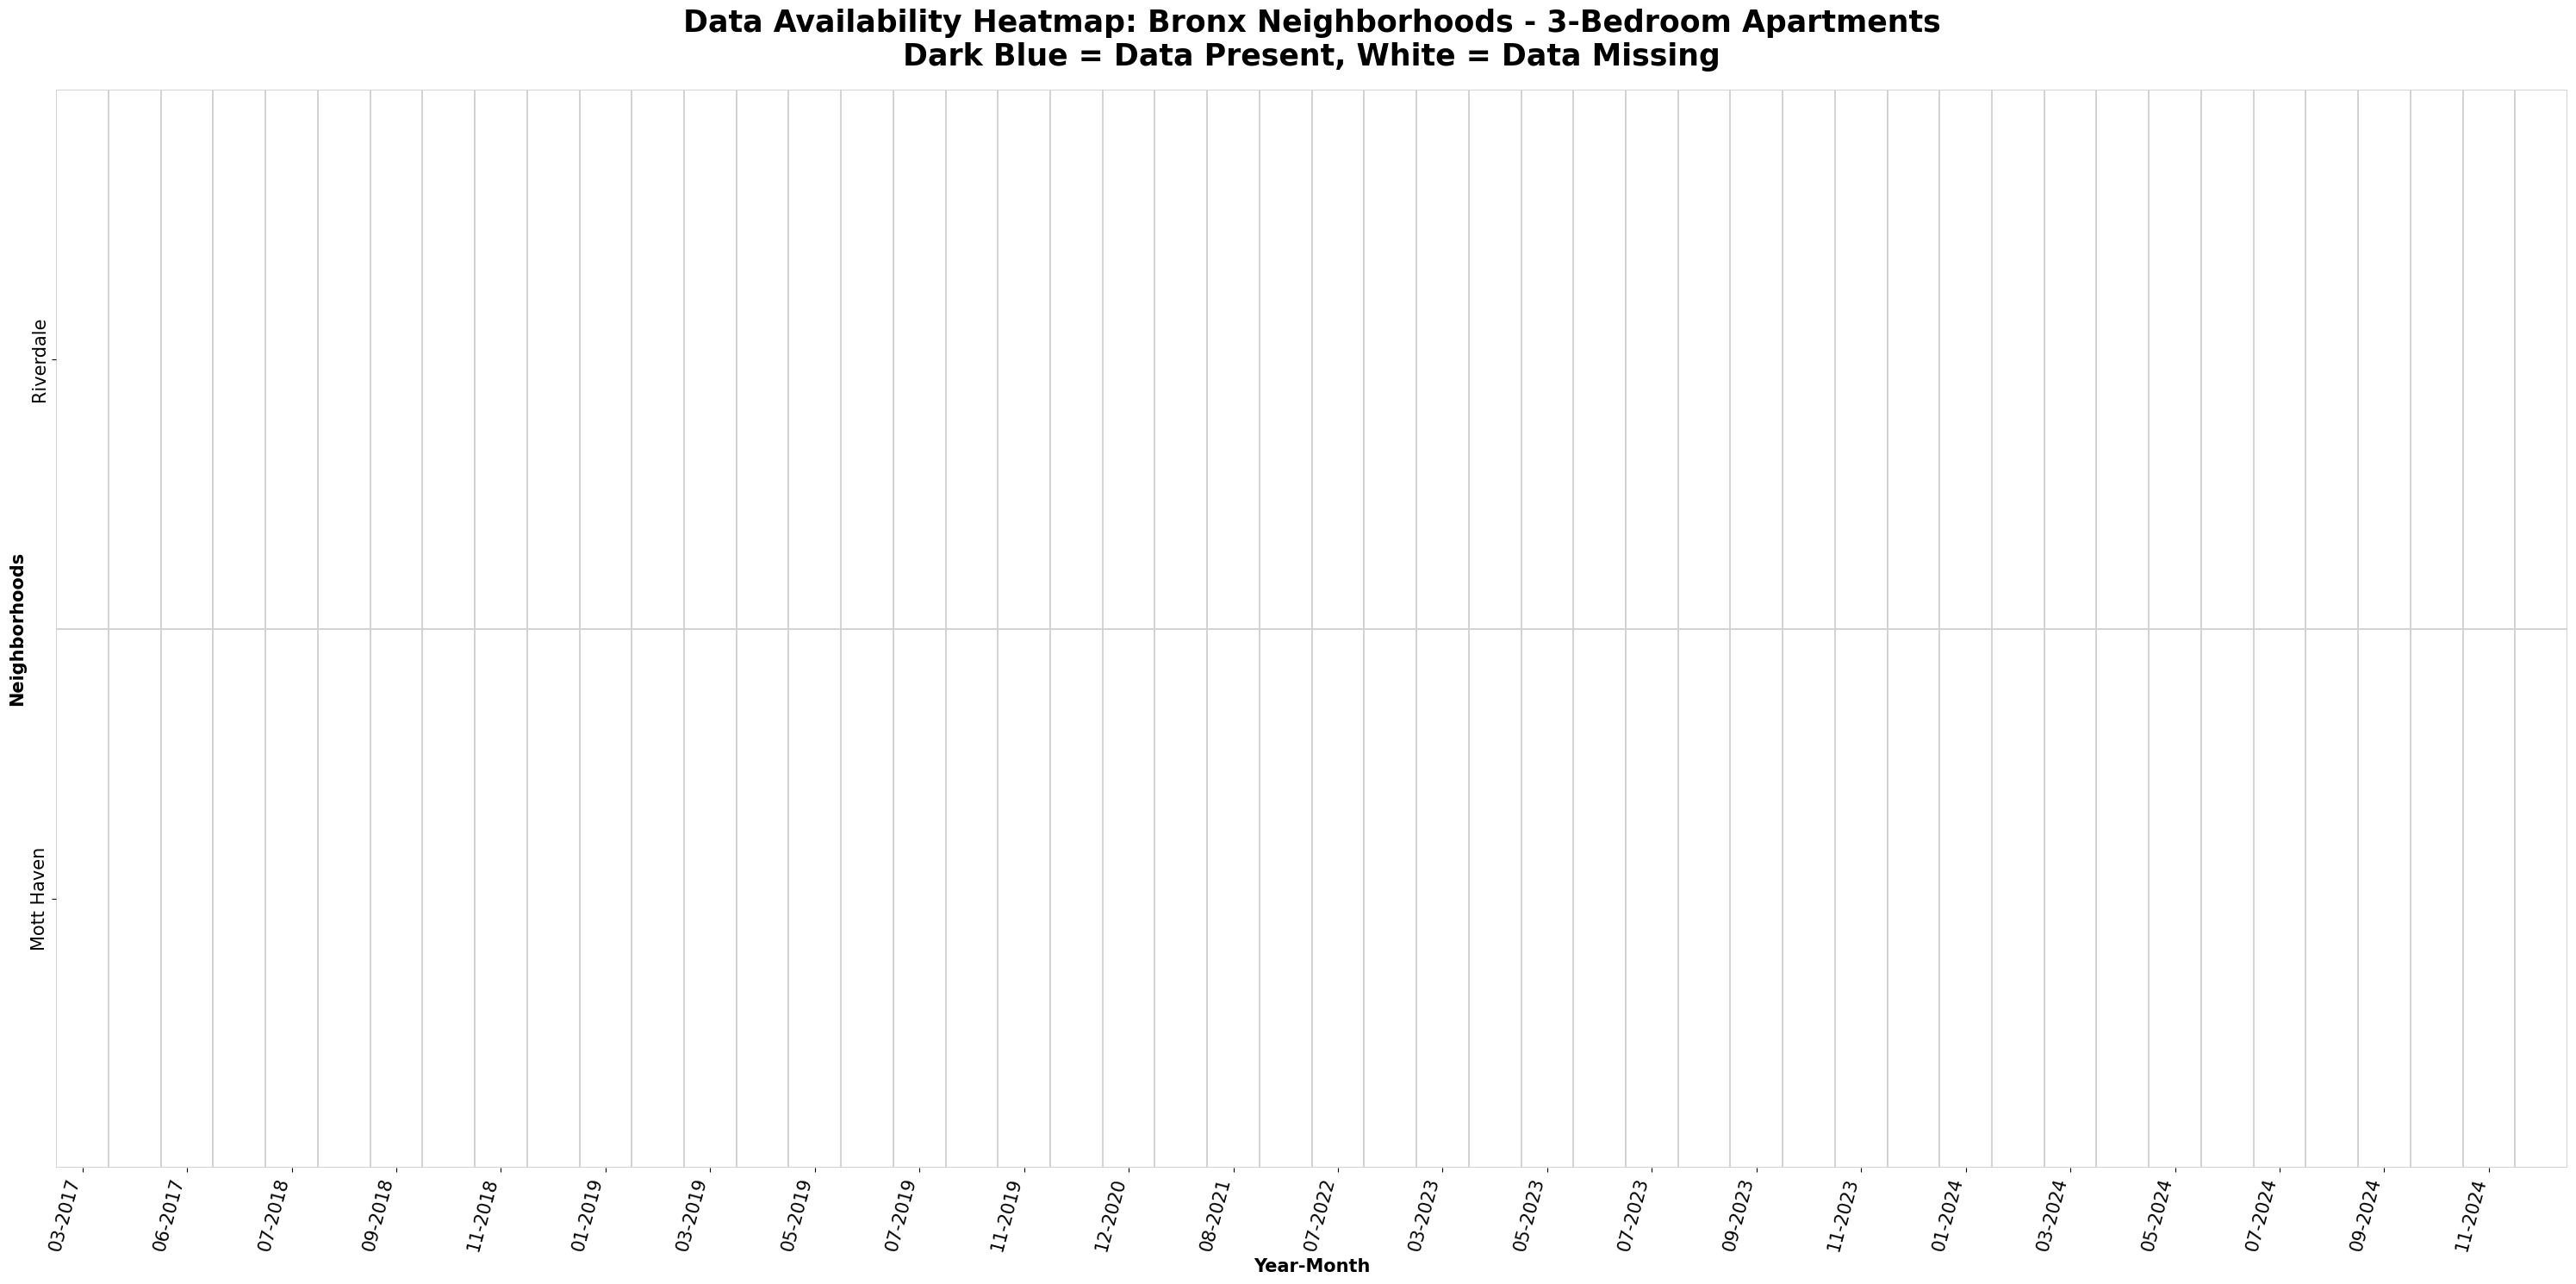

Data Availability Summary for Bronx:
Total data points: 96
Data present: 0.0 (0.0%)
Data missing: 96.0 (100.0%)
Number of neighborhoods: 2
Number of time periods: 48


In [14]:
for borough in boroughs:
    create_data_availability_heatmap(rent_df, borough, apt_type='3bdr', subtitle='3-Bedroom Apartments')

## Preliminary Rent Data Analysis

### Analyzing rent data for All Apartments

Let's look at a histogram of rent prices, at the borough level

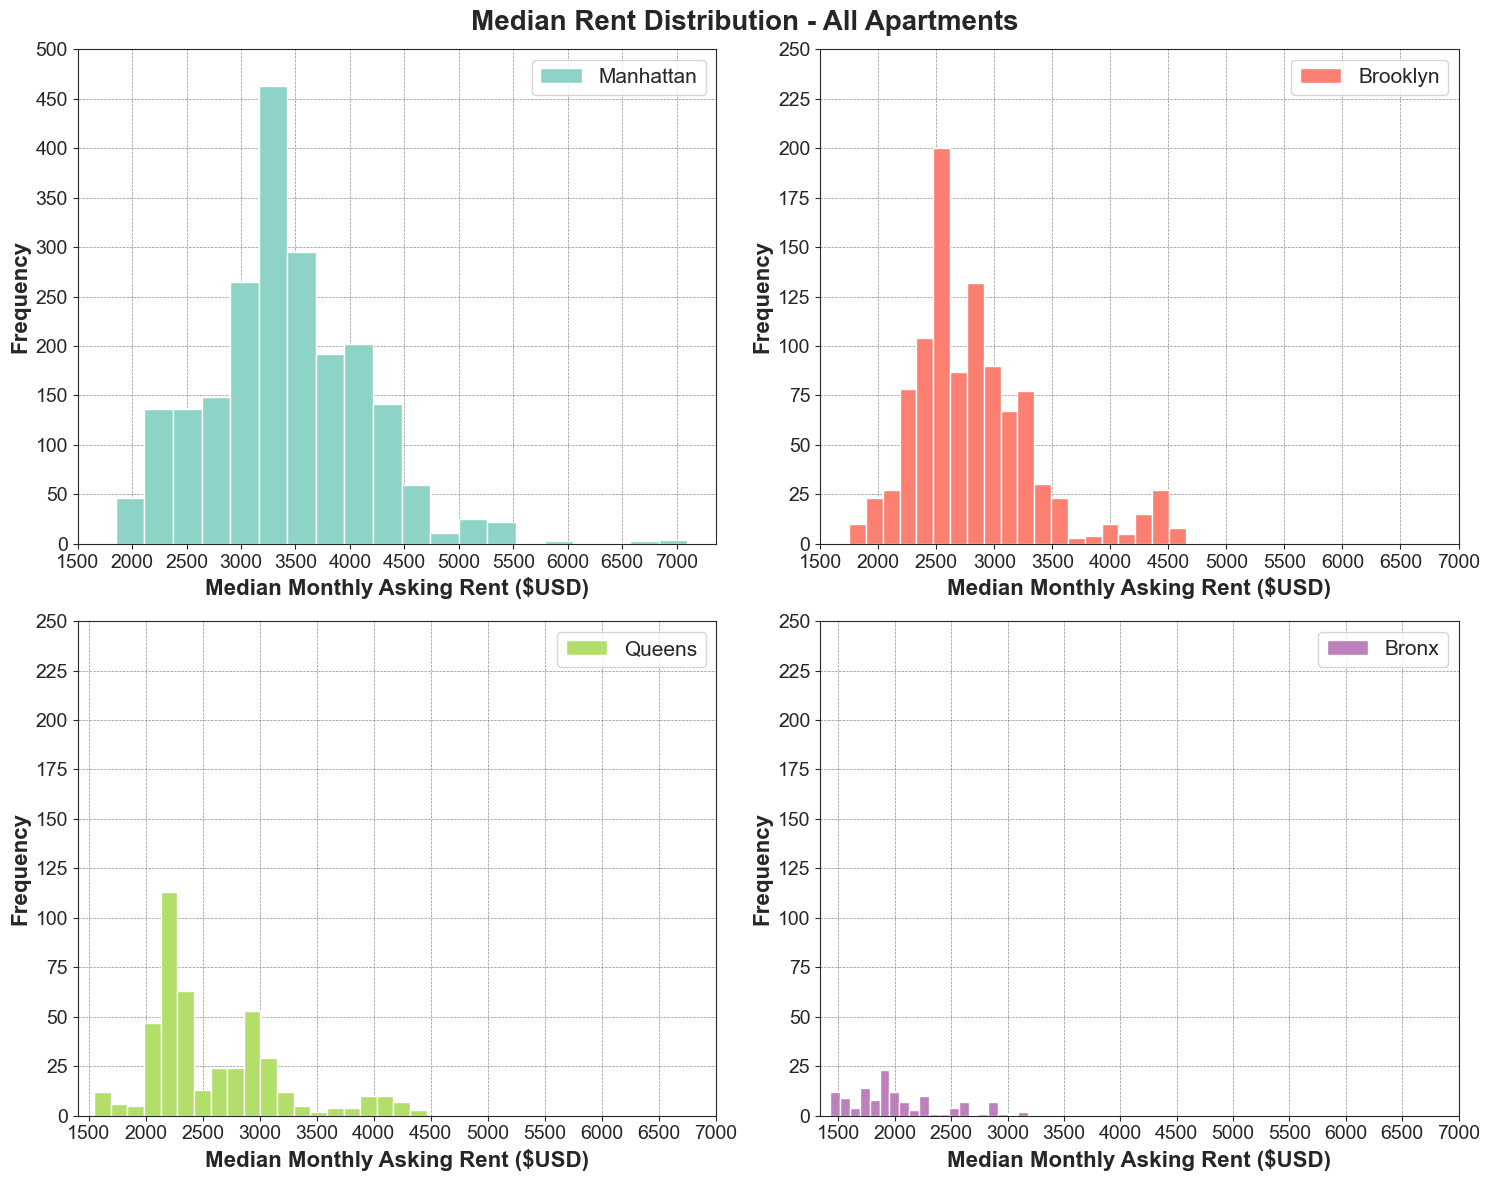

,count,mean,std,min,25%,50%,75%,max,variance,median
Manhattan,2153.0,3404.226660,724.967388,1850.0,2995.00,3350.0,3855.0,7100.0,525577.713239,3350.0
Brooklyn,1020.0,2828.325490,546.565691,1750.0,2494.25,2701.5,3100.0,4649.0,298734.054894,2701.5
Queens,446.0,2593.656951,598.157411,1550.0,2200.00,2300.0,2950.0,4463.0,357792.288794,2300.0
Bronx,126.0,2020.182540,412.503821,1425.0,1706.25,1930.0,2250.0,3180.0,170159.402413,1930.0


In [24]:
boroughs = ['Manhattan','Brooklyn','Queens','Bronx']
cmap = mpl.colormaps['Set3']
colors = cmap(np.linspace(0,1,5))
sns.set_style('ticks')
xticks = np.arange(1500,7250, 500)
yticks = np.arange(0,550,50)
stats = []

fig, axes = plt.subplots(2,2, figsize=(15,12))
axes = axes.flatten()  # for indexing

for i, borough in enumerate(boroughs):
    ax = axes[i]
    # subsetting borough-level data
    subset_df = rent_df[rent_df['borough'] == borough]
    # storing descriptive stats for later comparison
    subset_stats = subset_df['all_price'].describe()
    subset_stats = pd.concat([subset_stats,
                              pd.Series(subset_df['all_price'].var(), index=['variance']),
                              pd.Series(subset_df['all_price'].median(), index=['median'])])
    stats.append(subset_stats.rename(borough))

    
    ax.hist(subset_df['all_price'], bins=20, label=borough, color=colors[i])
    ax.legend(loc='upper right', fontsize=15)
    ax.set_xlabel('Median Monthly Asking Rent ($USD)', weight='bold', fontsize=16)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, fontsize=14)
    ax.set_ylabel('Frequency', weight='bold', fontsize=16)
    if borough == 'Manhattan':
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticks, fontsize=14)
    else:
        ax.set_yticks(yticks/2)
        ax.set_yticklabels((yticks/2).astype('int'), fontsize=14)
    ax.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)


plt.suptitle('Median Rent Distribution - All Apartments', fontsize=20, weight='bold')
plt.tight_layout() 
plt.show()
# creating a dataframe of borough-level stats
pd.DataFrame(stats)

Manhattan rent prices have an approx. Normal/Gaussian distribution, with a slight right skew. There is a clear modal peak around $3250, and moderate variance with a high-end tail at $5500+.

Brooklyn rent prices have a Right-Skewed distribution. There is a modal peak around $2500-$3000, and wide variance with notably high frequency even at higher price points from $4000-$5000.

Queens rent prices are Strongly Right-Skewed, with possible Bimodal characteristics. There is a dominant peak around $2250, and a secondary peak around $3000.

The Bronx rent prices are Extremely Right-Skewed, with very sparse data. There's a sharp peak around $1800-$2000, and very few observations above $3000. 

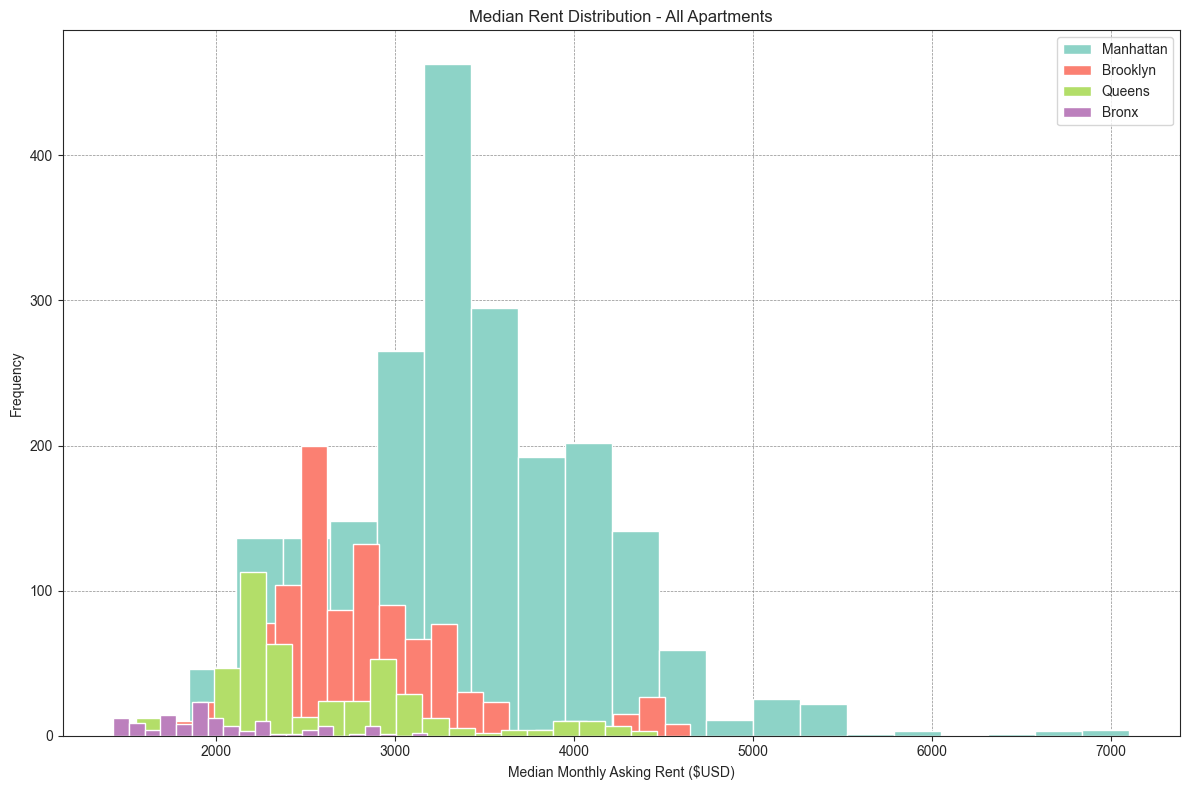

In [25]:
boroughs = ['Manhattan','Brooklyn','Queens','Bronx']
cmap = mpl.colormaps['Set3']
colors = cmap(np.linspace(0,1,5))
sns.set_style('ticks')

plt.figure(figsize=(12,8))
for i, borough in enumerate(boroughs):
    subset_df = rent_df[rent_df['borough'] == borough]
    plt.hist(subset_df['all_price'], bins=20, label=borough, color=colors[i])

plt.legend(loc='upper right')
plt.title('Median Rent Distribution - All Apartments')
plt.xlabel('Median Monthly Asking Rent ($USD)')
plt.ylabel('Frequency')
plt.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)
plt.tight_layout() 
plt.show()

Let's look at a time series of monthly average apartment rental prices, at the borough-level

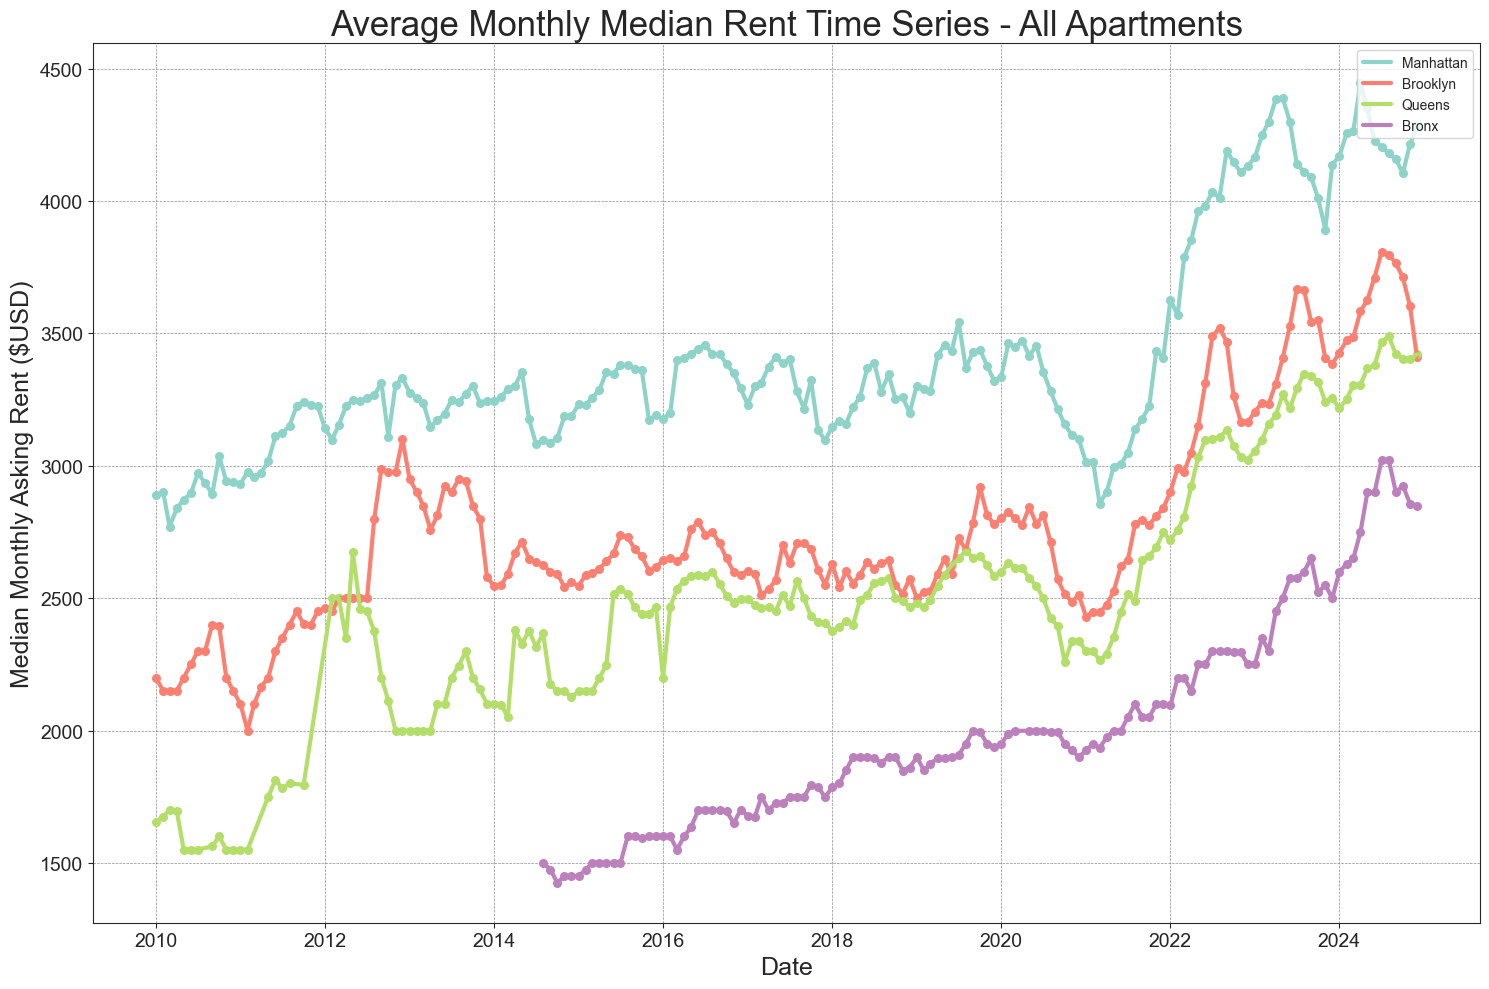

In [26]:
boroughs = ['Manhattan','Brooklyn','Queens','Bronx']
cmap = mpl.colormaps['Set3']
colors = cmap(np.linspace(0,1,5))
sns.set_style('ticks')

plt.figure(figsize=(15,10))
for i, borough in enumerate(boroughs):
    borough_df = rent_df[rent_df['borough'] == borough]
    subset_df = borough_df.groupby(['year','month'])['all_price'].mean().reset_index()
    subset_df['date'] = pd.to_datetime(subset_df[['year', 'month']].assign(day=1))
    plt.plot(subset_df['date'], subset_df['all_price'], label=borough, color=colors[i],linewidth=3)
    plt.scatter(subset_df['date'], subset_df['all_price'], color=colors[i], s=30)

plt.legend(loc='upper right')
plt.title('Average Monthly Median Rent Time Series - All Apartments', fontsize=25)
plt.xlabel('Date', fontsize=18)
plt.xticks(fontsize=14)
plt.ylabel('Median Monthly Asking Rent ($USD)', fontsize=18)
plt.yticks(fontsize=14)
plt.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)
plt.tight_layout() 
plt.show()

Let's see how rent prices fluctuate monthly

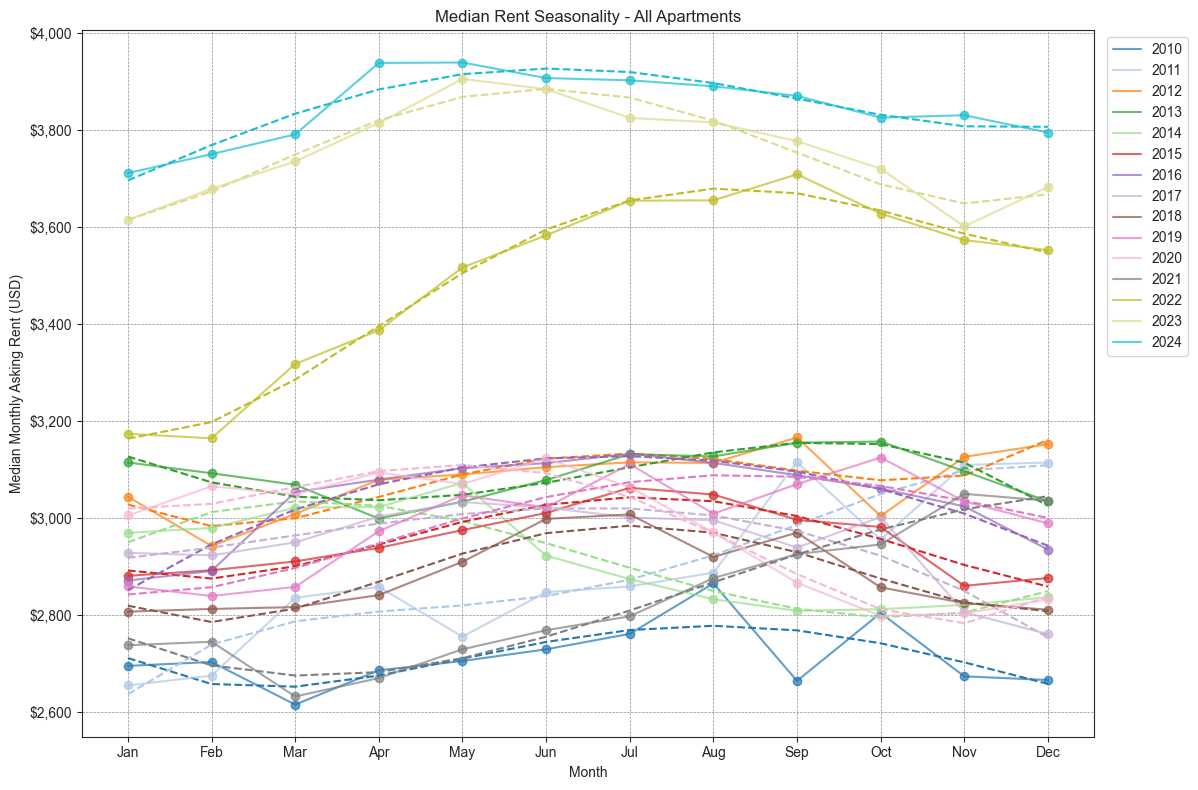

In [27]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
years = rent_df['year'].unique()
cmap = mpl.colormaps['tab20']
colors = cmap(np.linspace(0,1,len(years)+1))

plt.figure(figsize=(12,8))
for i, year in enumerate(years):
    monthly_rent = rent_df[rent_df['year'] == year][['month','all_price']].groupby('month').mean()
    plt.plot(months, monthly_rent, color=colors[i], label=year, alpha=0.7)
    plt.scatter(months, monthly_rent, color=colors[i], alpha=0.7)
    # calculating a polynomial to fit the seasonal trend
    coeff = np.polyfit(np.arange(len(months)), monthly_rent, 4)
    trend_fx = np.poly1d(coeff.squeeze())
    plt.plot(months, trend_fx(np.arange(len(months))), color=colors[i], ls='--')

plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1))
plt.title('Median Rent Seasonality - All Apartments')
plt.ylabel('Median Monthly Asking Rent (USD)')
plt.xlabel('Month')
# Format y-axis to show dollar signs
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)
plt.tight_layout() 
plt.show()

Median apartment rent prices ranged between $2300 and $2800 between 2010 and 2019.

Then, they shifted upwards ranging between $2800 and $3500 after 2021.

Let's take a closer look at this decadal shift.

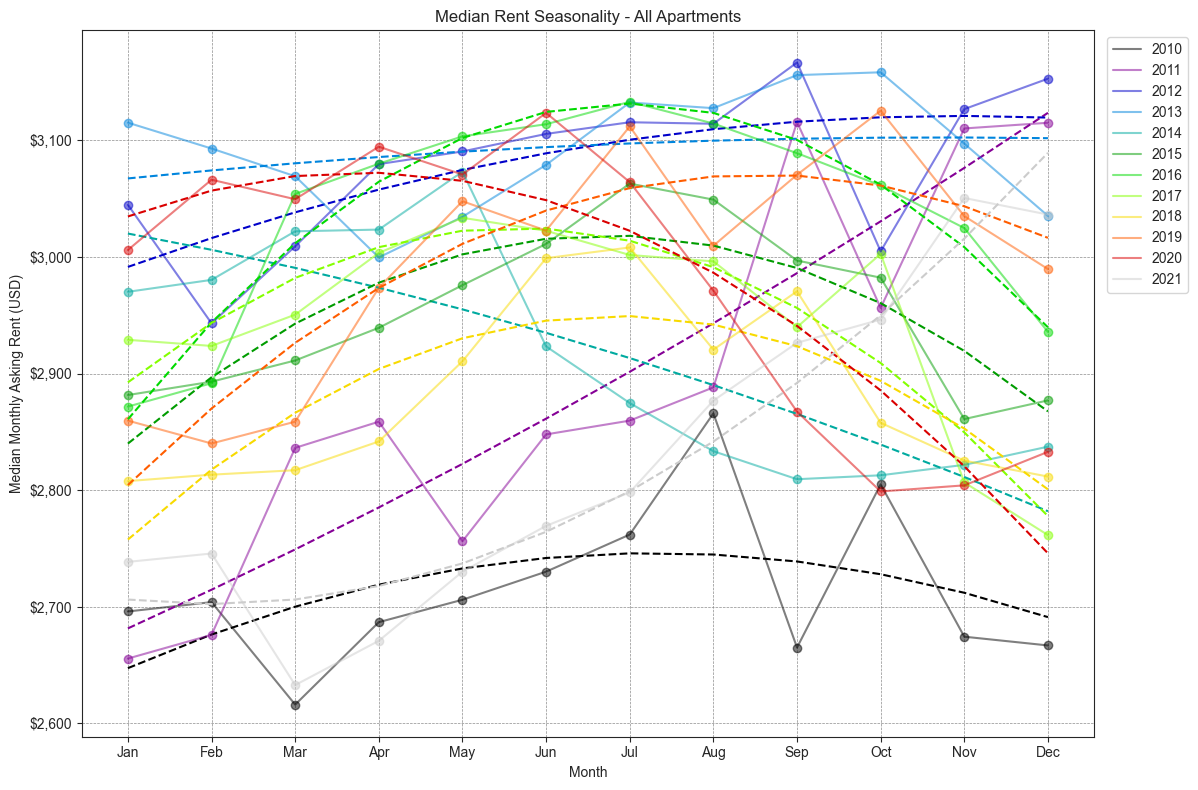

In [28]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
years = rent_df['year'].unique()[:12]
cmap = mpl.colormaps['nipy_spectral']
colors = cmap(np.linspace(0,1,len(years)))

plt.figure(figsize=(12,8))
for i, year in enumerate(years):
    monthly_rent = rent_df[rent_df['year'] == year][['month','all_price']].groupby('month').mean()
    plt.plot(months, monthly_rent, color=colors[i], label=year, alpha=0.5)
    plt.scatter(months, monthly_rent, color=colors[i], alpha=0.5)
    # calculating a polynomial to fit the seasonal trend
    coeff = np.polyfit(np.arange(len(months)), monthly_rent, 2)
    trend_fx = np.poly1d(coeff.squeeze())
    plt.plot(months, trend_fx(np.arange(len(months))), color=colors[i], ls='--')

plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1))
plt.title('Median Rent Seasonality - All Apartments')
plt.ylabel('Median Monthly Asking Rent (USD)')
plt.xlabel('Month')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)
plt.tight_layout() 
plt.show()

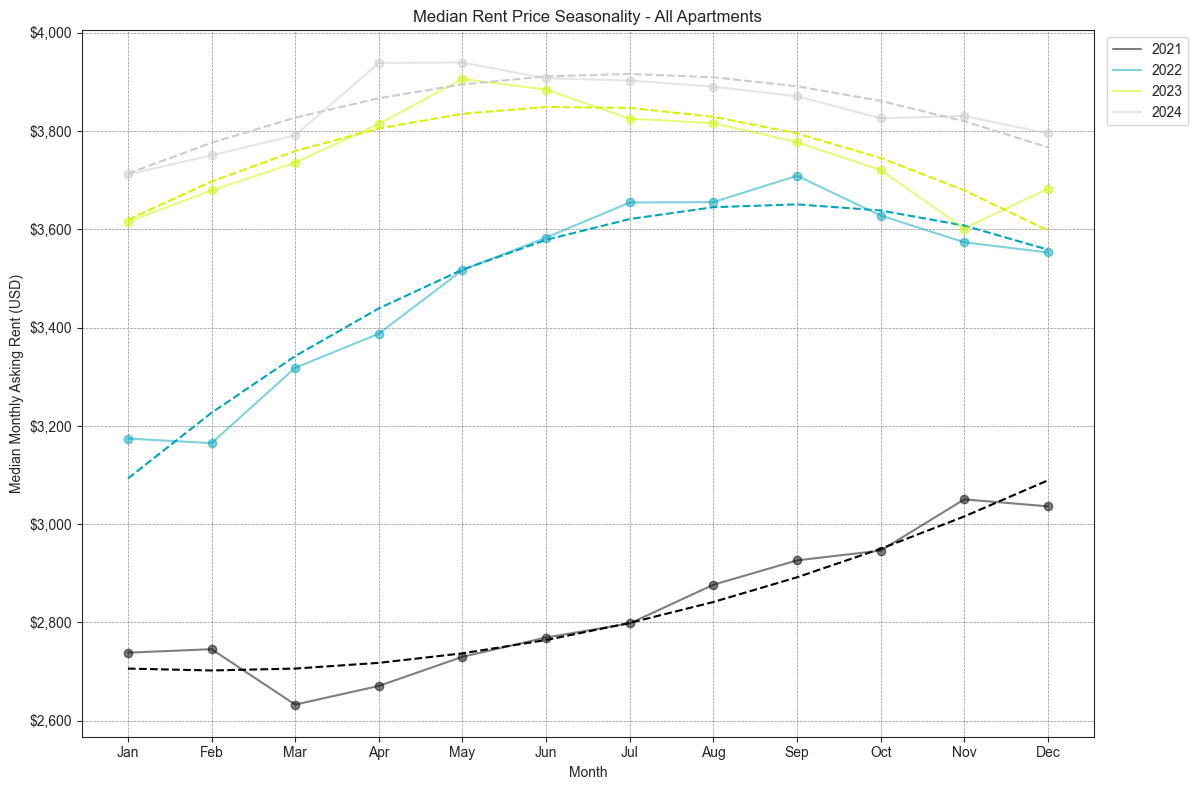

In [29]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
years = rent_df['year'].unique()[11:]
cmap = mpl.colormaps['nipy_spectral']
colors = cmap(np.linspace(0,1,len(years)))

plt.figure(figsize=(12,8))
for i, year in enumerate(years):
    monthly_rent = rent_df[rent_df['year'] == year][['month','all_price']].groupby('month').mean()
    plt.plot(months, monthly_rent, color=colors[i], label=year, alpha=0.5)
    plt.scatter(months, monthly_rent, color=colors[i], alpha=0.5)
    # calculating a polynomial to fit the seasonal trend
    coeff = np.polyfit(np.arange(len(months)), monthly_rent, 2)
    trend_fx = np.poly1d(coeff.squeeze())
    plt.plot(months, trend_fx(np.arange(len(months))), color=colors[i], ls='--')

plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1))
plt.title('Median Rent Price Seasonality - All Apartments')
plt.ylabel('Median Monthly Asking Rent (USD)')
plt.xlabel('Month')
# Format y-axis to show dollar signs
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)
plt.tight_layout() 
plt.show()

### Analyzing rent data for 1-Bedroom Apartments

Let's look at a histogram of rent prices, at the borough level

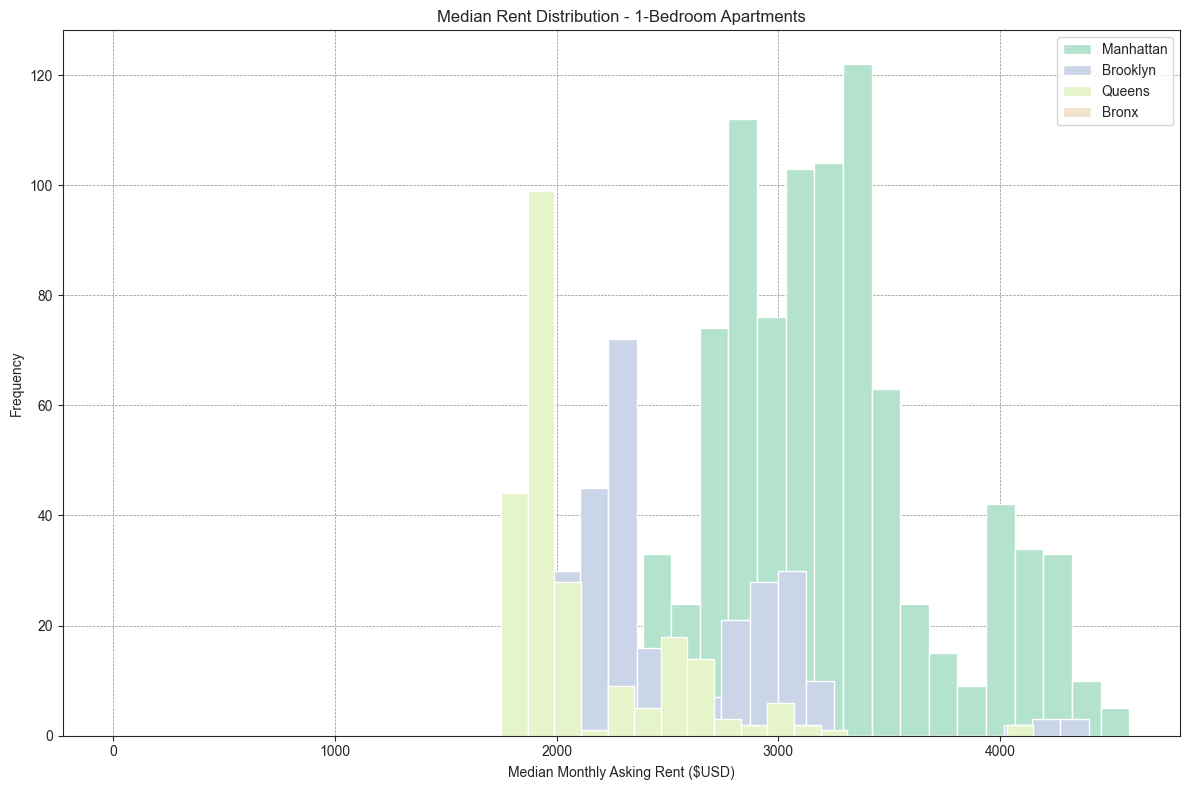

In [30]:
boroughs = ['Manhattan','Brooklyn','Queens','Bronx']
cmap = mpl.colormaps['Pastel2']
colors = cmap(np.linspace(0,1,5))

plt.figure(figsize=(12,8))
for i, borough in enumerate(boroughs):
    subset_df = rent_df[rent_df['borough'] == borough]
    plt.hist(subset_df['1bdr_price'].dropna(), bins=20, label=borough, color=colors[i])

plt.legend(loc='upper right')
plt.title('Median Rent Distribution - 1-Bedroom Apartments')
plt.xlabel('Median Monthly Asking Rent ($USD)')
plt.ylabel('Frequency')
plt.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)
plt.tight_layout() 
plt.show()

Let's look at a time series of apartment rental prices, at the borough-level

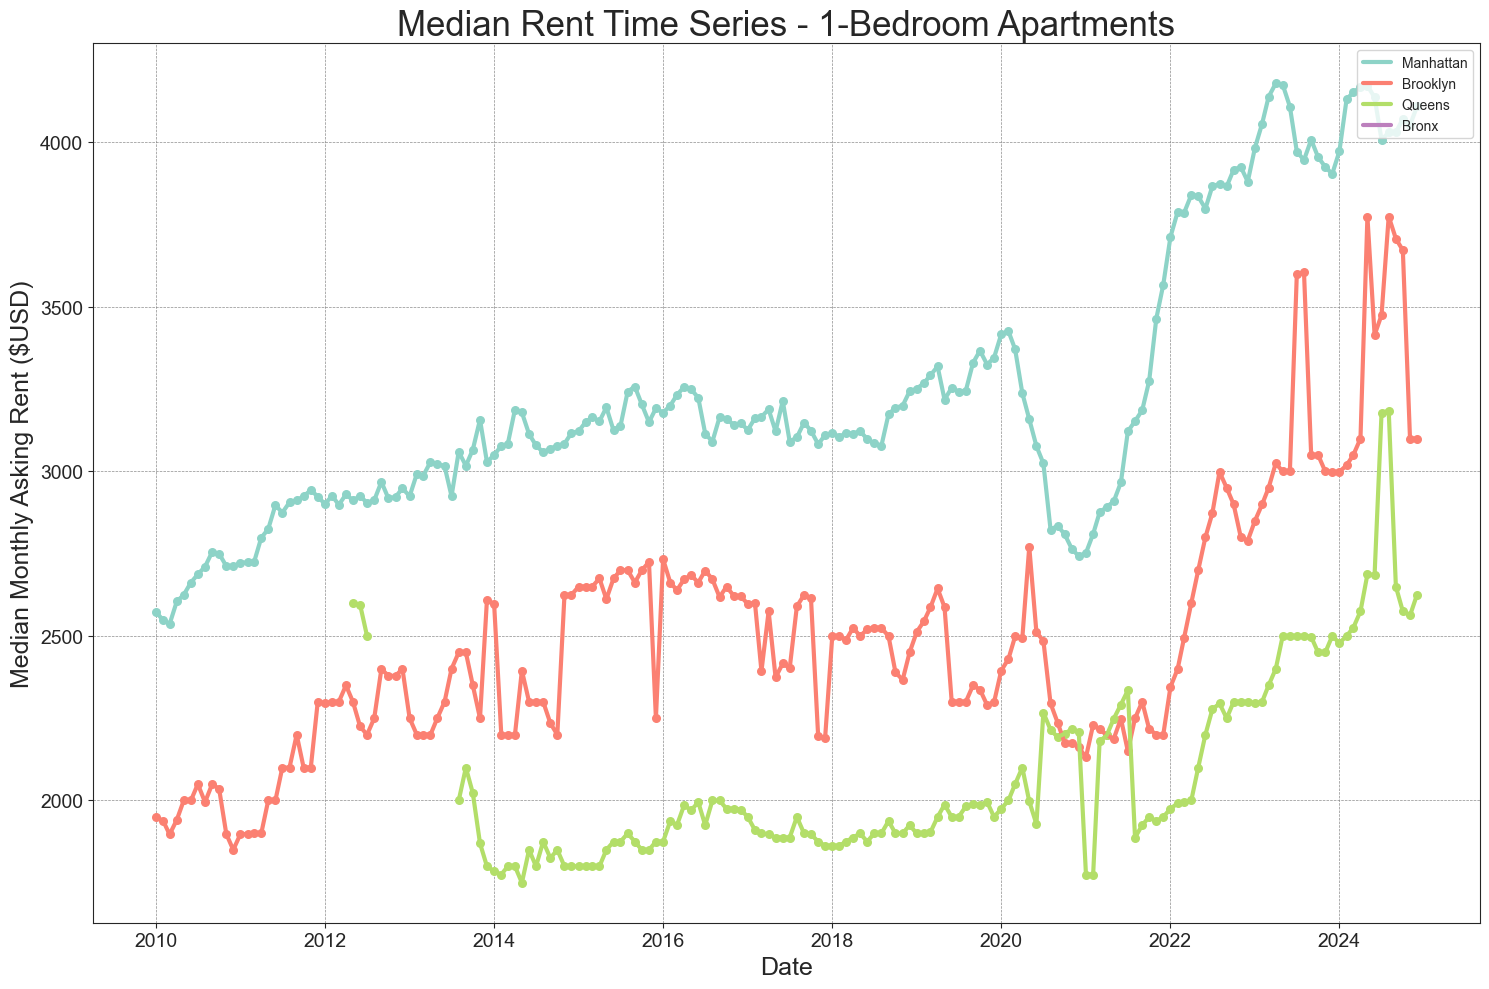

In [31]:
boroughs = ['Manhattan','Brooklyn','Queens','Bronx']
cmap = mpl.colormaps['Set3']
colors = cmap(np.linspace(0,1,5))
sns.set_style('ticks')

plt.figure(figsize=(15,10))
for i, borough in enumerate(boroughs):
    borough_df = rent_df[rent_df['borough'] == borough]
    subset_df = borough_df.groupby(['year','month'])['1bdr_price'].mean().reset_index()
    subset_df['date'] = pd.to_datetime(subset_df[['year', 'month']].assign(day=1))
    plt.plot(subset_df['date'], subset_df['1bdr_price'], label=borough, color=colors[i],linewidth=3)
    plt.scatter(subset_df['date'], subset_df['1bdr_price'], color=colors[i], s=30)

plt.legend(loc='upper right')
plt.title('Median Rent Time Series - 1-Bedroom Apartments', fontsize=25)
plt.xlabel('Date', fontsize=18)
plt.xticks(fontsize=14)
plt.ylabel('Median Monthly Asking Rent ($USD)', fontsize=18)
plt.yticks(fontsize=14)
plt.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)
plt.tight_layout() 
plt.show()

Let's see how rent prices fluctuate monthly

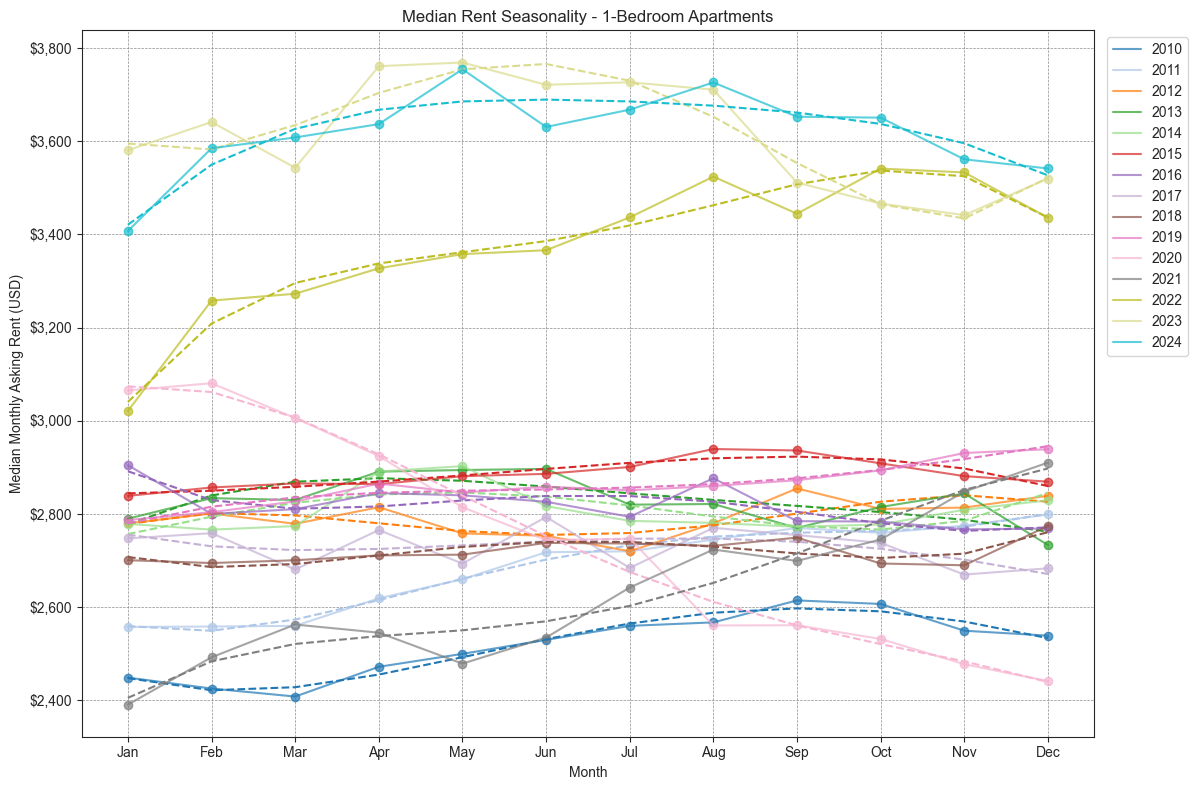

In [32]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
years = rent_df['year'].unique()
cmap = mpl.colormaps['tab20']
colors = cmap(np.linspace(0,1,len(years)+1))

plt.figure(figsize=(12,8))
for i, year in enumerate(years):
    monthly_rent = rent_df[rent_df['year'] == year][['month','1bdr_price']].groupby('month').mean()
    plt.plot(months, monthly_rent, color=colors[i], label=year, alpha=0.7)
    plt.scatter(months, monthly_rent, color=colors[i], alpha=0.7)
    # calculating a polynomial to fit the seasonal trend
    coeff = np.polyfit(np.arange(len(months)), monthly_rent, 4)
    trend_fx = np.poly1d(coeff.squeeze())
    plt.plot(months, trend_fx(np.arange(len(months))), color=colors[i], ls='--')

plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1))
plt.title('Median Rent Seasonality - 1-Bedroom Apartments')
plt.ylabel('Median Monthly Asking Rent (USD)')
plt.xlabel('Month')
# Format y-axis to show dollar signs
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)
plt.tight_layout() 
plt.show()

We're seeing a trend that is similar to what we saw earlier while looking at all apartment data:

Median 1-bedroom apartment rent prices went through a decadal shift before and after 2021.

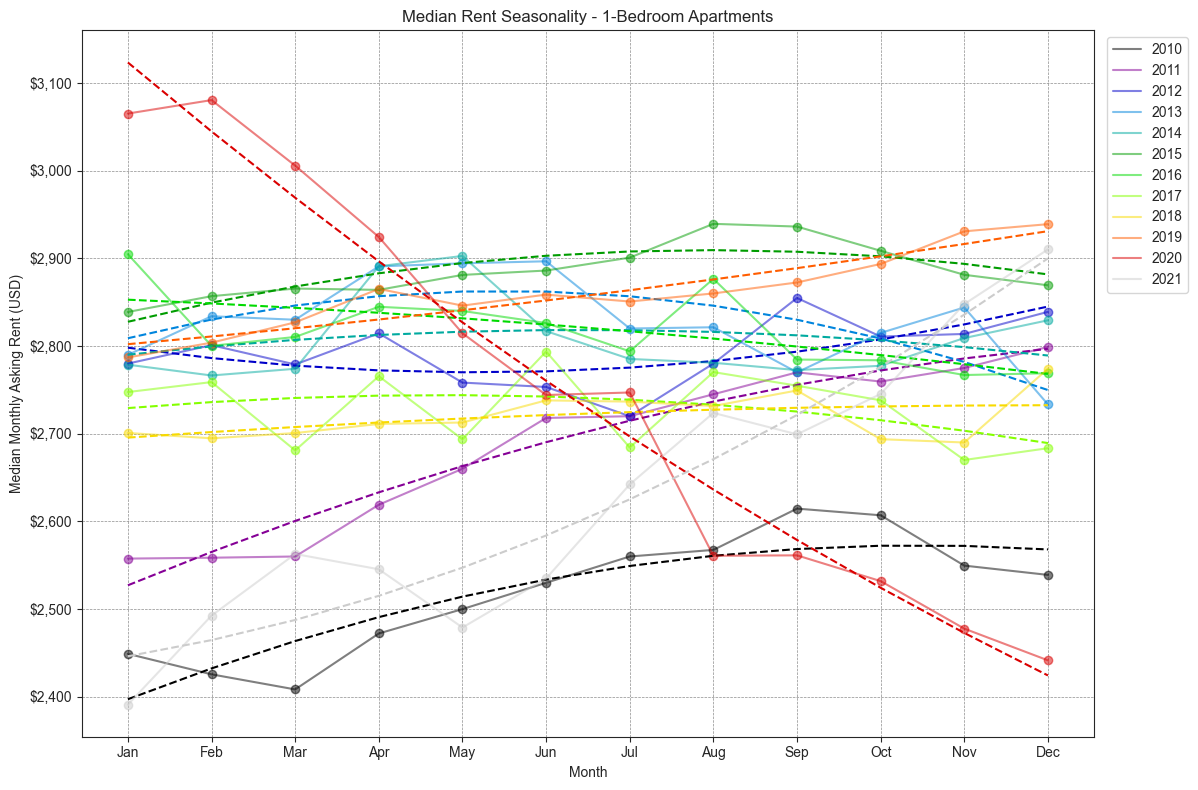

In [33]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
years = rent_df['year'].unique()[:12]
cmap = mpl.colormaps['nipy_spectral']
colors = cmap(np.linspace(0,1,len(years)))

plt.figure(figsize=(12,8))
for i, year in enumerate(years):
    monthly_rent = rent_df[rent_df['year'] == year][['month','1bdr_price']].groupby('month').mean()
    plt.plot(months, monthly_rent, color=colors[i], label=year, alpha=0.5)
    plt.scatter(months, monthly_rent, color=colors[i], alpha=0.5)
    # calculating a polynomial to fit the seasonal trend
    coeff = np.polyfit(np.arange(len(months)), monthly_rent, 2)
    trend_fx = np.poly1d(coeff.squeeze())
    plt.plot(months, trend_fx(np.arange(len(months))), color=colors[i], ls='--')

plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1))
plt.title('Median Rent Seasonality - 1-Bedroom Apartments')
plt.ylabel('Median Monthly Asking Rent (USD)')
plt.xlabel('Month')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)
plt.tight_layout() 
plt.show()

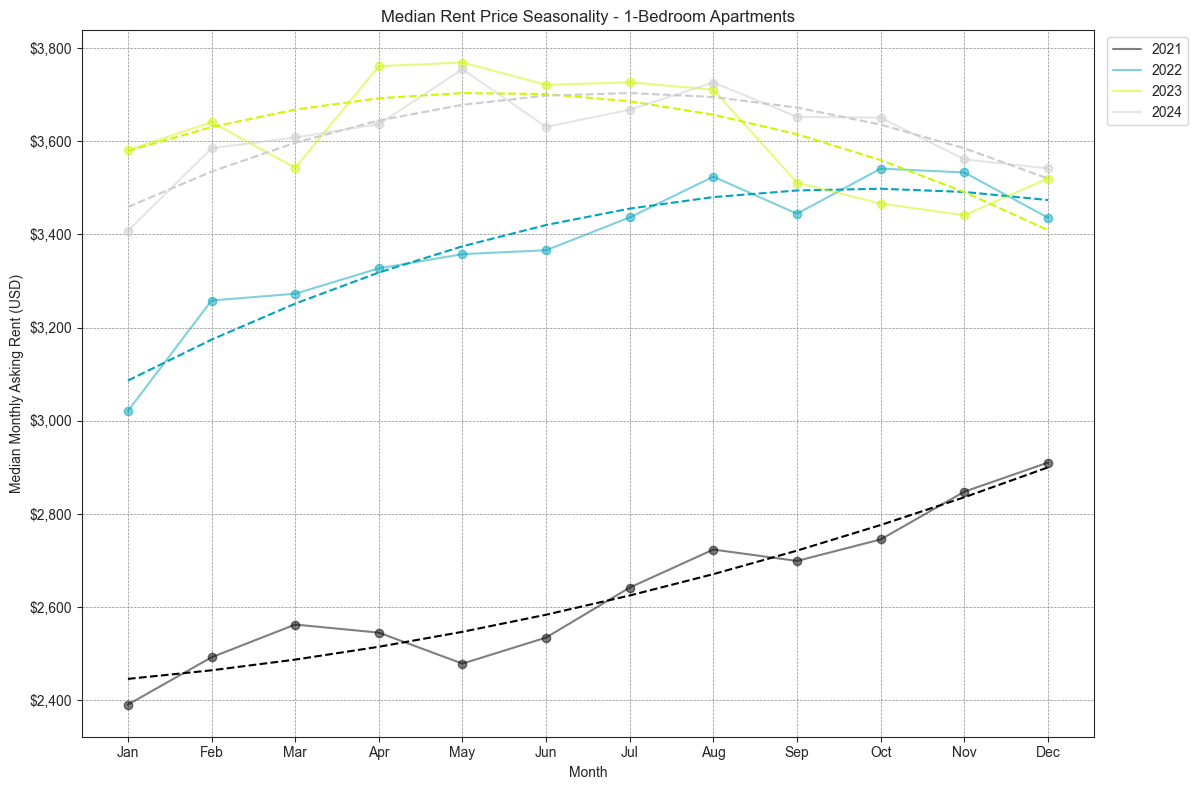

In [259]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
years = rent_df['year'].unique()[11:]
cmap = mpl.colormaps['nipy_spectral']
colors = cmap(np.linspace(0,1,len(years)))

plt.figure(figsize=(12,8))
for i, year in enumerate(years):
    monthly_rent = rent_df[rent_df['year'] == year][['month','1bdr_price']].groupby('month').mean()
    plt.plot(months, monthly_rent, color=colors[i], label=year, alpha=0.5)
    plt.scatter(months, monthly_rent, color=colors[i], alpha=0.5)
    # calculating a polynomial to fit the seasonal trend
    coeff = np.polyfit(np.arange(len(months)), monthly_rent, 2)
    trend_fx = np.poly1d(coeff.squeeze())
    plt.plot(months, trend_fx(np.arange(len(months))), color=colors[i], ls='--')

plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1))
plt.title('Median Rent Price Seasonality - 1-Bedroom Apartments')
plt.ylabel('Median Monthly Asking Rent (USD)')
plt.xlabel('Month')
# Format y-axis to show dollar signs
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)
plt.tight_layout() 
plt.show()

### Analyzing rent data for 3-Bedroom Apartments

Let's look at a histogram of rent prices, at the borough level

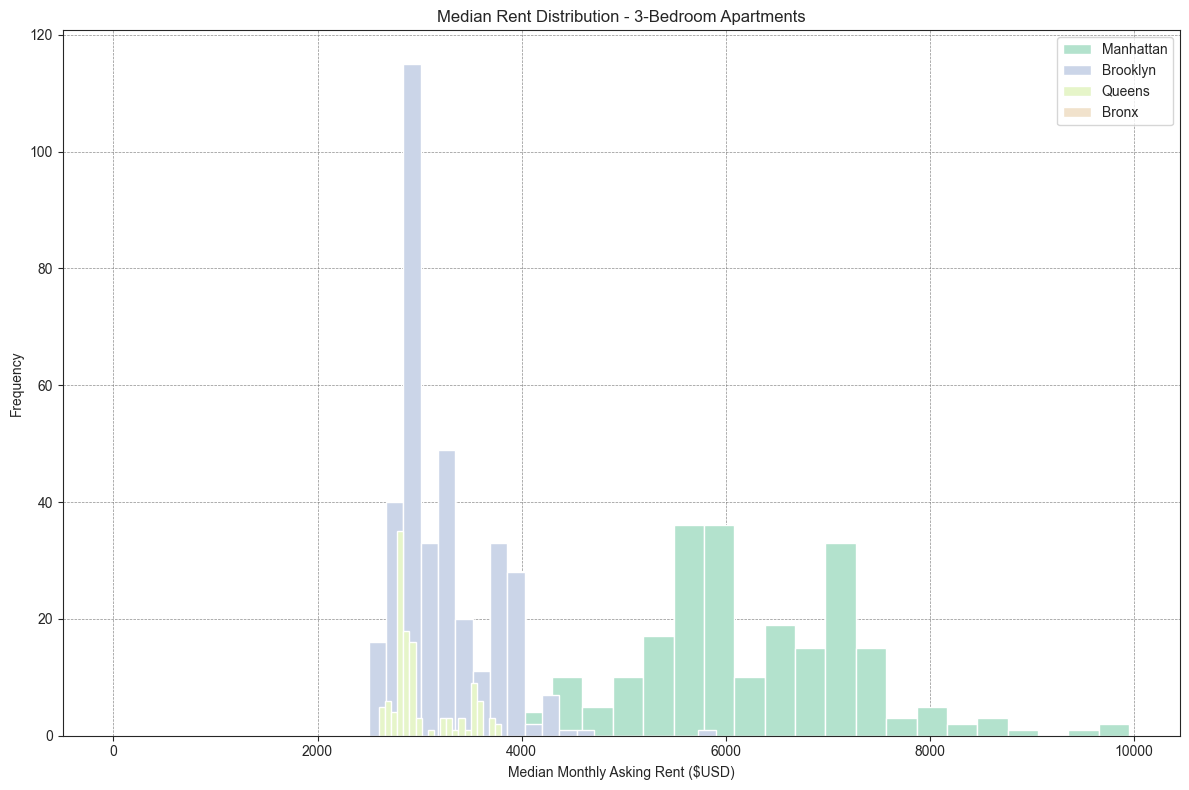

In [34]:
boroughs = ['Manhattan','Brooklyn','Queens','Bronx']
cmap = mpl.colormaps['Pastel2']
colors = cmap(np.linspace(0,1,5))

plt.figure(figsize=(12,8))
for i, borough in enumerate(boroughs):
    subset_df = rent_df[rent_df['borough'] == borough]
    plt.hist(subset_df['3bdr_price'].dropna(), bins=20, label=borough, color=colors[i])

plt.legend(loc='upper right')
plt.title('Median Rent Distribution - 3-Bedroom Apartments')
plt.xlabel('Median Monthly Asking Rent ($USD)')
plt.ylabel('Frequency')
plt.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)
plt.tight_layout() 
plt.show()

Let's look at a time series of apartment rental prices, at the borough-level

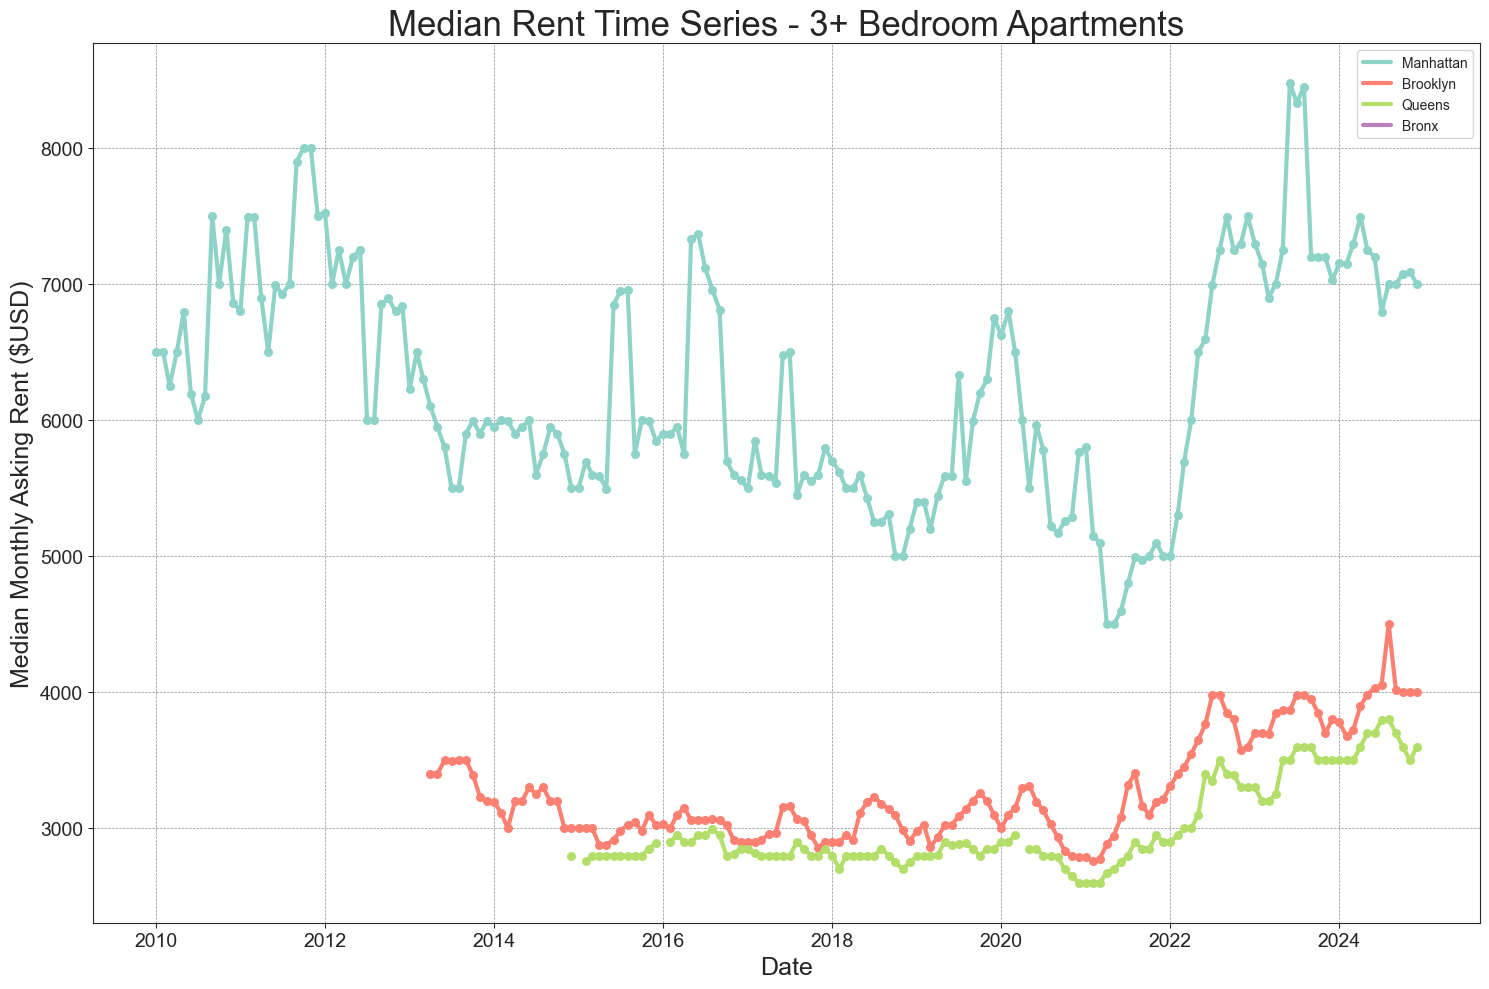

In [35]:
boroughs = ['Manhattan','Brooklyn','Queens','Bronx']
cmap = mpl.colormaps['Set3']
colors = cmap(np.linspace(0,1,5))
sns.set_style('ticks')

plt.figure(figsize=(15,10))
for i, borough in enumerate(boroughs):
    borough_df = rent_df[rent_df['borough'] == borough]
    subset_df = borough_df.groupby(['year','month'])['3bdr_price'].mean().reset_index()
    subset_df['date'] = pd.to_datetime(subset_df[['year', 'month']].assign(day=1))
    plt.plot(subset_df['date'], subset_df['3bdr_price'], label=borough, color=colors[i],linewidth=3)
    plt.scatter(subset_df['date'], subset_df['3bdr_price'], color=colors[i], s=30)

plt.legend(loc='upper right')
plt.title('Median Rent Time Series - 3+ Bedroom Apartments', fontsize=25)
plt.xlabel('Date', fontsize=18)
plt.xticks(fontsize=14)
plt.ylabel('Median Monthly Asking Rent ($USD)', fontsize=18)
plt.yticks(fontsize=14)
plt.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)
plt.tight_layout() 
plt.show()

Let's see how rent prices fluctuate monthly

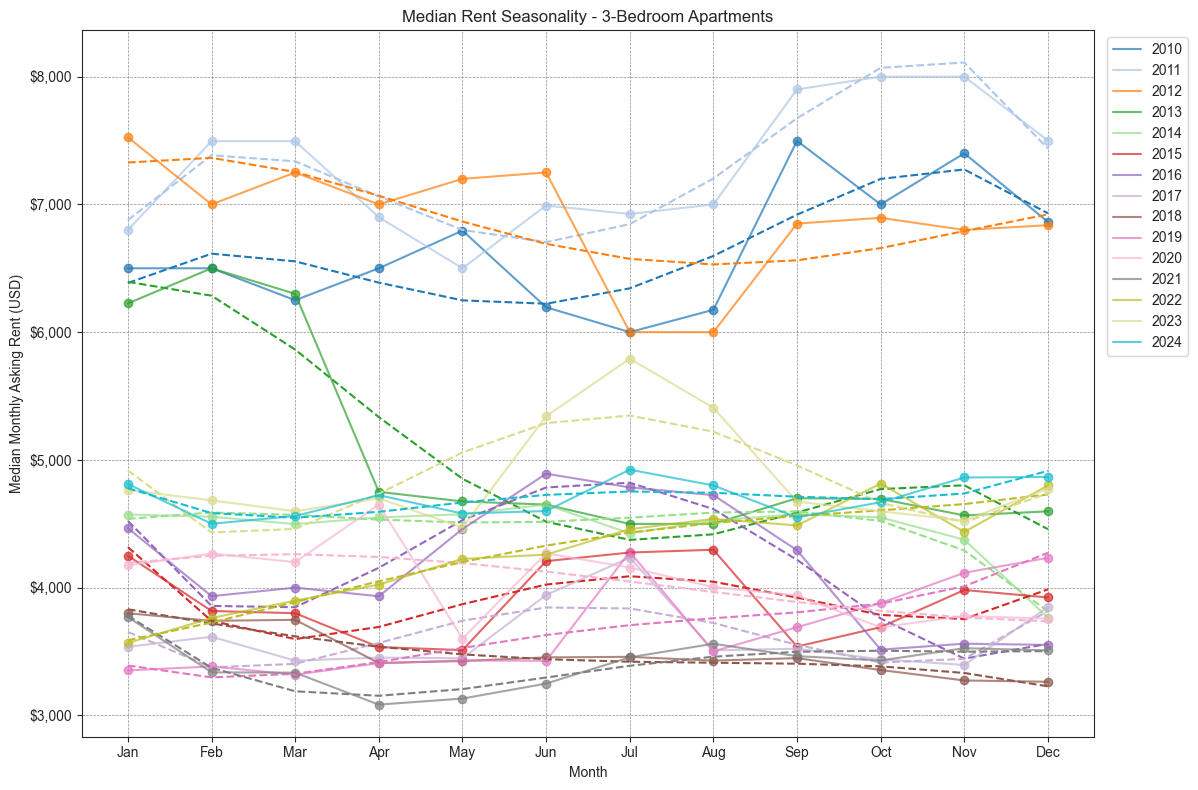

In [36]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
years = rent_df['year'].unique()
cmap = mpl.colormaps['tab20']
colors = cmap(np.linspace(0,1,len(years)+1))

plt.figure(figsize=(12,8))
for i, year in enumerate(years):
    monthly_rent = rent_df[rent_df['year'] == year][['month','3bdr_price']].groupby('month').mean()
    plt.plot(months, monthly_rent, color=colors[i], label=year, alpha=0.7)
    plt.scatter(months, monthly_rent, color=colors[i], alpha=0.7)
    # calculating a polynomial to fit the seasonal trend
    coeff = np.polyfit(np.arange(len(months)), monthly_rent, 4)
    trend_fx = np.poly1d(coeff.squeeze())
    plt.plot(months, trend_fx(np.arange(len(months))), color=colors[i], ls='--')

plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1))
plt.title('Median Rent Seasonality - 3-Bedroom Apartments')
plt.ylabel('Median Monthly Asking Rent (USD)')
plt.xlabel('Month')
# Format y-axis to show dollar signs
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)
plt.tight_layout() 
plt.show()

3-bedroom apartments have a more complex story regarding monthly price fluctuations over time.

It appears that the years 2010-2013 have higher asking rent prices than the following years leading up to 2020.

Then, we see a a price shift similar to that of the 1-bedroom and all-apartment datasets, however, the gap between the 2 groups isn't as large as approx. $1000. This likely has to do with lower demand for apartments with 3+ bedrooms.

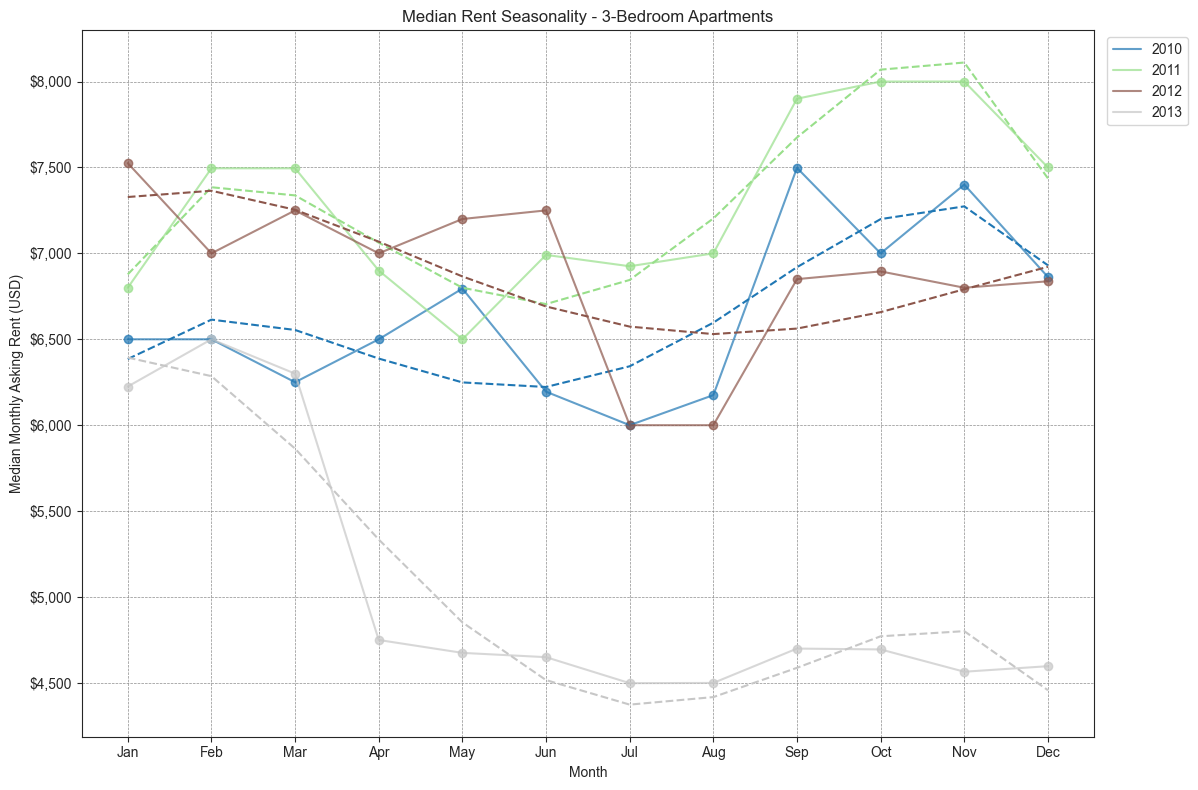

In [37]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
years = rent_df['year'].unique()[:4]
cmap = mpl.colormaps['tab20']
colors = cmap(np.linspace(0,1,len(years)+1))

plt.figure(figsize=(12,8))
for i, year in enumerate(years):
    monthly_rent = rent_df[rent_df['year'] == year][['month','3bdr_price']].groupby('month').mean()
    plt.plot(months, monthly_rent, color=colors[i], label=year, alpha=0.7)
    plt.scatter(months, monthly_rent, color=colors[i], alpha=0.7)
    # calculating a polynomial to fit the seasonal trend
    coeff = np.polyfit(np.arange(len(months)), monthly_rent, 4)
    trend_fx = np.poly1d(coeff.squeeze())
    plt.plot(months, trend_fx(np.arange(len(months))), color=colors[i], ls='--')

plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1))
plt.title('Median Rent Seasonality - 3-Bedroom Apartments')
plt.ylabel('Median Monthly Asking Rent (USD)')
plt.xlabel('Month')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)
plt.tight_layout() 
plt.show()

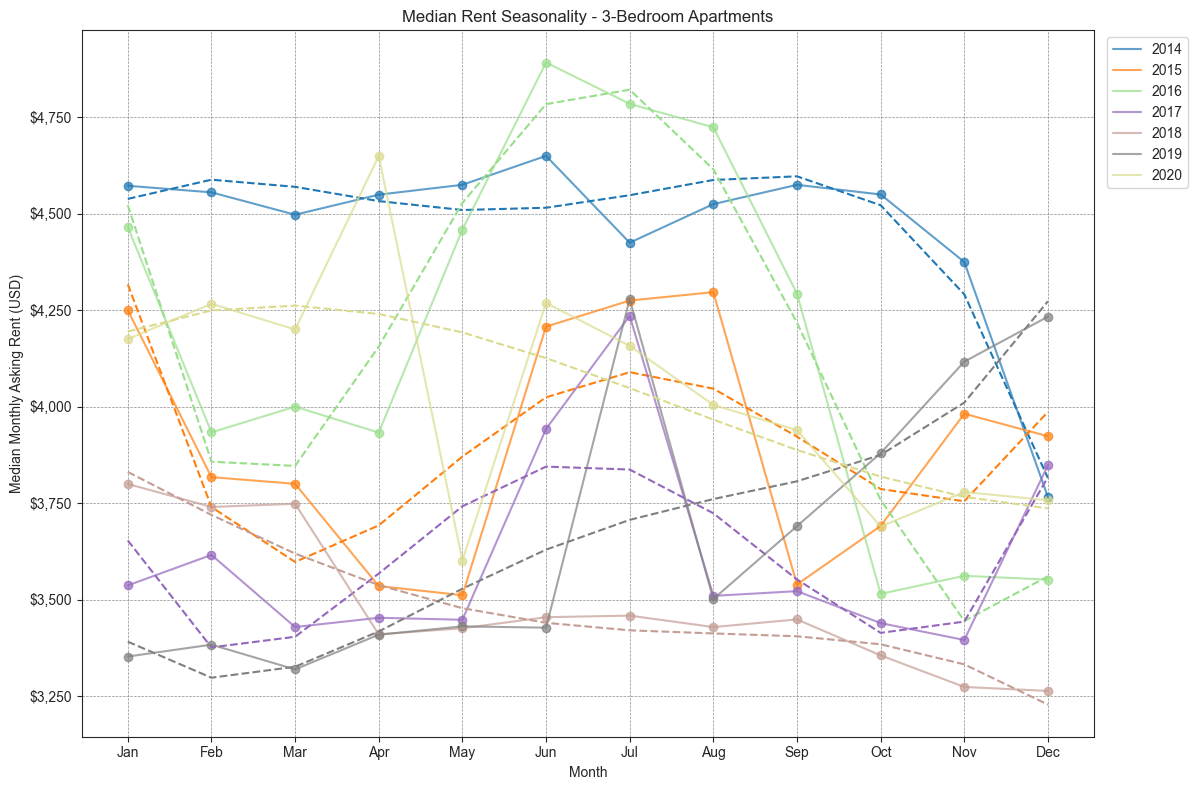

In [269]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
years = rent_df['year'].unique()[4:11]
cmap = mpl.colormaps['tab20']
colors = cmap(np.linspace(0,1,len(years)+1))

plt.figure(figsize=(12,8))
for i, year in enumerate(years):
    monthly_rent = rent_df[rent_df['year'] == year][['month','3bdr_price']].groupby('month').mean()
    plt.plot(months, monthly_rent, color=colors[i], label=year, alpha=0.7)
    plt.scatter(months, monthly_rent, color=colors[i], alpha=0.7)
    # calculating a polynomial to fit the seasonal trend
    coeff = np.polyfit(np.arange(len(months)), monthly_rent, 4)
    trend_fx = np.poly1d(coeff.squeeze())
    plt.plot(months, trend_fx(np.arange(len(months))), color=colors[i], ls='--')

plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1))
plt.title('Median Rent Seasonality - 3-Bedroom Apartments')
plt.ylabel('Median Monthly Asking Rent (USD)')
plt.xlabel('Month')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)
plt.tight_layout() 
plt.show()

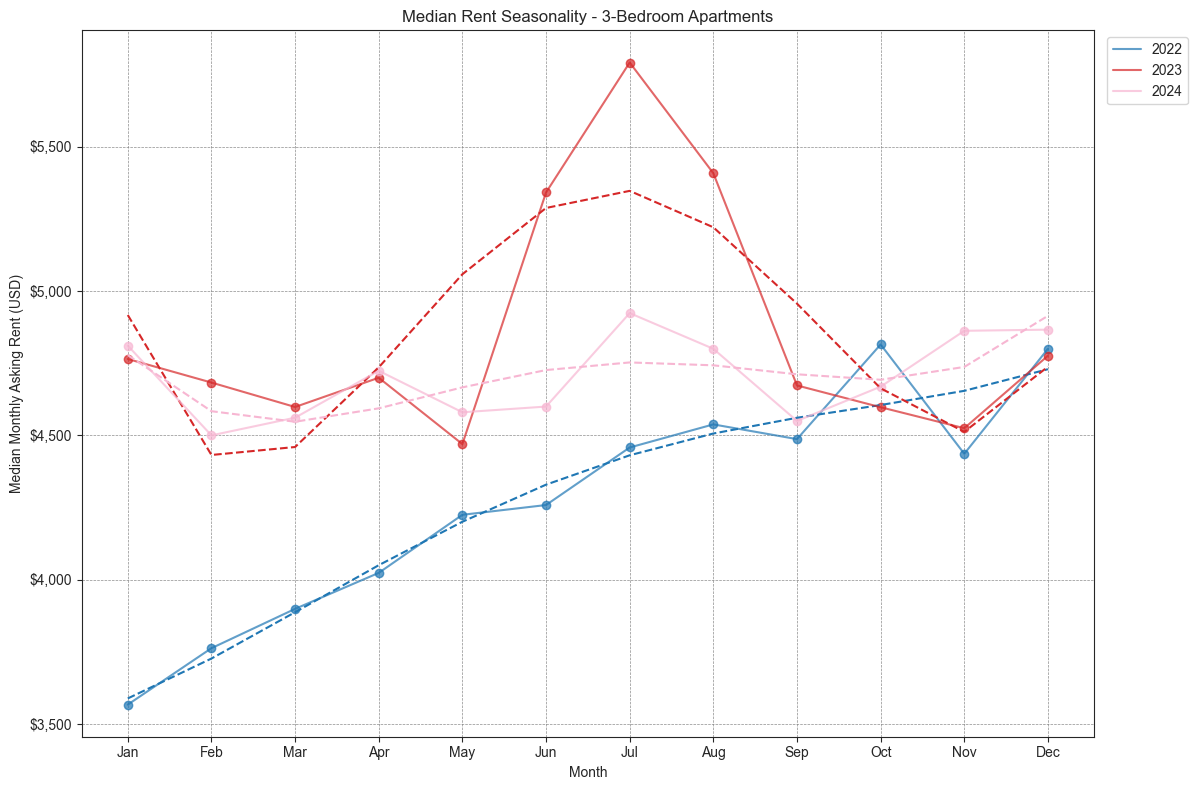

In [38]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
years = rent_df['year'].unique()[12:]
cmap = mpl.colormaps['tab20']
colors = cmap(np.linspace(0,1,len(years)+1))

plt.figure(figsize=(12,8))
for i, year in enumerate(years):
    monthly_rent = rent_df[rent_df['year'] == year][['month','3bdr_price']].groupby('month').mean()
    plt.plot(months, monthly_rent, color=colors[i], label=year, alpha=0.7)
    plt.scatter(months, monthly_rent, color=colors[i], alpha=0.7)
    # calculating a polynomial to fit the seasonal trend
    coeff = np.polyfit(np.arange(len(months)), monthly_rent, 4)
    trend_fx = np.poly1d(coeff.squeeze())
    plt.plot(months, trend_fx(np.arange(len(months))), color=colors[i], ls='--')

plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1))
plt.title('Median Rent Seasonality - 3-Bedroom Apartments')
plt.ylabel('Median Monthly Asking Rent (USD)')
plt.xlabel('Month')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)
plt.tight_layout() 
plt.show()

## Load/Uploading Dataset to BigQuery

In [13]:
# configuration
PROJECT_ID = "rent-affordability"
DATASET = "nyc_analysis"
TABLE_ID = f"{PROJECT_ID}.{DATASET}.staging_median_rent"
EXPIRATION = datetime.now(timezone.utc) + timedelta(days=59)

# load credentials
service_account_info = json.loads(os.environ["GOOGLE_CREDENTIALS_JSON"])
credentials = service_account.Credentials.from_service_account_info(service_account_info)
# initialize client
client = bigquery.Client(project=PROJECT_ID, credentials=credentials)
job_config = bigquery.LoadJobConfig(autodetect=True, # infer  table schema
                                    write_disposition="WRITE_TRUNCATE") # overwrite

job = client.load_table_from_dataframe(rent_df, TABLE_ID, job_config=job_config)
job.result() # ensures the script waits for the job to complete

# 5a. check if the upload was successful
if job.state == 'DONE':
    if job.error_result:
        print(f"Job completed with errors: {job.error_result}")
    else:
        print(f"Job completed successfully. Loaded {job.output_rows} rows to {TABLE_ID}")
else:
    print(f"Job state: {job.state}")

Job completed successfully. Loaded 7146 rows to rent-affordability.nyc_analysis.staging_median_rent


# Importing, Visualizing/Understanding, Preprocessing, and Uploading Income Data

## Extract/Import Income Datasets

In [14]:
# 1. Downloading ACS data using Census API
ACS_Tables = [
    'B19013_001E',  # All HHs - median income
    'B19202_001E',  # 1-person HH - median income
    'B19131_002E',  # Married HHs w/ children - median income
    'B19131_005E',  # Other HHs w/ children - median income (foster, grandparents, etc.)
    ]

# Importing Median Income for All Households (B19013_001E)
median_HH_income_all = Import_ACS_Table(os.getenv('CENSUS_API'), 36,
                                        ACS_Tables[0])

# Importing Median Income for Single Adult Households (B19202_001E)
median_HH_income_singles = Import_ACS_Table(os.getenv('CENSUS_API'), 36,
                                            ACS_Tables[1])

# Importing Median Income for Married Households w/ Children (B19131_002E)
median_HH_income_married_kids = Import_ACS_Table(os.getenv('CENSUS_API'), 36,
                                            ACS_Tables[2])

# Importing Median Income for Other Households w/ Children (B19131_005E)
median_HH_income_other_kids = Import_ACS_Table(os.getenv('CENSUS_API'), 36,
                                            ACS_Tables[3])

median_HH_income_all

,NAME,B19013_001E,state,public use microdata area,year
0,NYC-Brooklyn Community District 1--Greenpoint ...,101442,36,04001,2021
1,NYC-Brooklyn Community District 1--Greenpoint ...,50298,36,04001,2012
2,NYC-Brooklyn Community District 1--Greenpoint ...,52419,36,04001,2013
3,NYC-Brooklyn Community District 1--Greenpoint ...,57818,36,04001,2014
4,NYC-Brooklyn Community District 1--Greenpoint ...,67107,36,04001,2015
...,...,...,...,...,...
415,NYC-Queens Community District 9--Richmond Hill...,66531,36,04111,2016
416,NYC-Queens Community District 9--Richmond Hill...,69916,36,04111,2017
417,NYC-Queens Community District 9--Richmond Hill...,71796,36,04111,2018
418,NYC-Queens Community District 9--Richmond Hill...,75207,36,04111,2021


The U.S. Census does not provide a count of households represented in each annual income estimate. They utilize a weighted methodolgy, so income estimates are representative of the thousands/millions of people represented in each Public-Use Microdata Area. 

## Tidy Income Datasets

All income datasets are already in tidy format (yay)! So, let's simply merge them and modify the column names and organization to improve usability.

In [15]:
#  merging tables with income data
income_dfs = [median_HH_income_all,
              median_HH_income_singles,
              median_HH_income_other_kids,
              median_HH_income_married_kids
]

for idx, df in enumerate(income_dfs):
    if idx == 0:
        merged_table = pd.merge(df, income_dfs[idx+1], how='inner',
                                on=['NAME','public use microdata area', 'year', 'state']
                                )
    elif idx == (len(income_dfs)-1):
        break
    else:
        merged_table = pd.merge(merged_table, income_dfs[idx+1], how='inner', # type: ignore
                                on=['NAME','public use microdata area', 'year', 'state']
                                )

# Rename columns for easier querying
merged_table.rename(columns={"B19013_001E":"all_HHs",
                             "B19202_001E":"singles",
                             "B19131_002E":"married_kids",
                             "B19131_005E":"other_kids",
                             "NAME": "district",
                             "public use microdata area": "PUMA"
}, inplace=True)


cols = list(merged_table.columns)
# move income columns to right side of df
cols.insert(5, cols[1])
del cols[1:3]
income_df = merged_table[cols]
income_df

,district,PUMA,year,all_HHs,singles,other_kids,married_kids
0,NYC-Brooklyn Community District 1--Greenpoint ...,04001,2021,101442,94782,None,None
1,NYC-Brooklyn Community District 1--Greenpoint ...,04001,2012,50298,56697,None,None
2,NYC-Brooklyn Community District 1--Greenpoint ...,04001,2013,52419,52746,None,None
3,NYC-Brooklyn Community District 1--Greenpoint ...,04001,2014,57818,61330,None,None
4,NYC-Brooklyn Community District 1--Greenpoint ...,04001,2015,67107,68720,None,None
...,...,...,...,...,...,...,...
415,NYC-Queens Community District 9--Richmond Hill...,04111,2016,66531,41825,20,23295
416,NYC-Queens Community District 9--Richmond Hill...,04111,2017,69916,42685,76,20952
417,NYC-Queens Community District 9--Richmond Hill...,04111,2018,71796,50407,114,23154
418,NYC-Queens Community District 9--Richmond Hill...,04111,2021,75207,57025,None,None


## Transform/Preprocess Income Datasets

In [16]:
# Let's explicitly set the data type for all columns
income_df = income_df.convert_dtypes()
income_df['all_HHs'] = income_df['all_HHs'].astype('Int64')
income_df['singles'] = income_df['singles'].astype('Int64')
income_df['other_kids'] = income_df['other_kids'].astype('Int64')
income_df['married_kids'] = income_df['married_kids'].astype('Int64')
print(income_df.dtypes)

district        string[python]
PUMA            string[python]
year                     Int64
all_HHs                  Int64
singles                  Int64
other_kids               Int64
married_kids             Int64
dtype: object


### Let's Visualize Present/Missing Data


Processing Brooklyn...
  All Households: 180.0/360 data points (50.0% coverage)
  Single Adults: 180.0/360 data points (50.0% coverage)
  Married Families w. Children: 58.0/360 data points (16.1% coverage)
  Other Families w. Children: 58.0/360 data points (16.1% coverage)


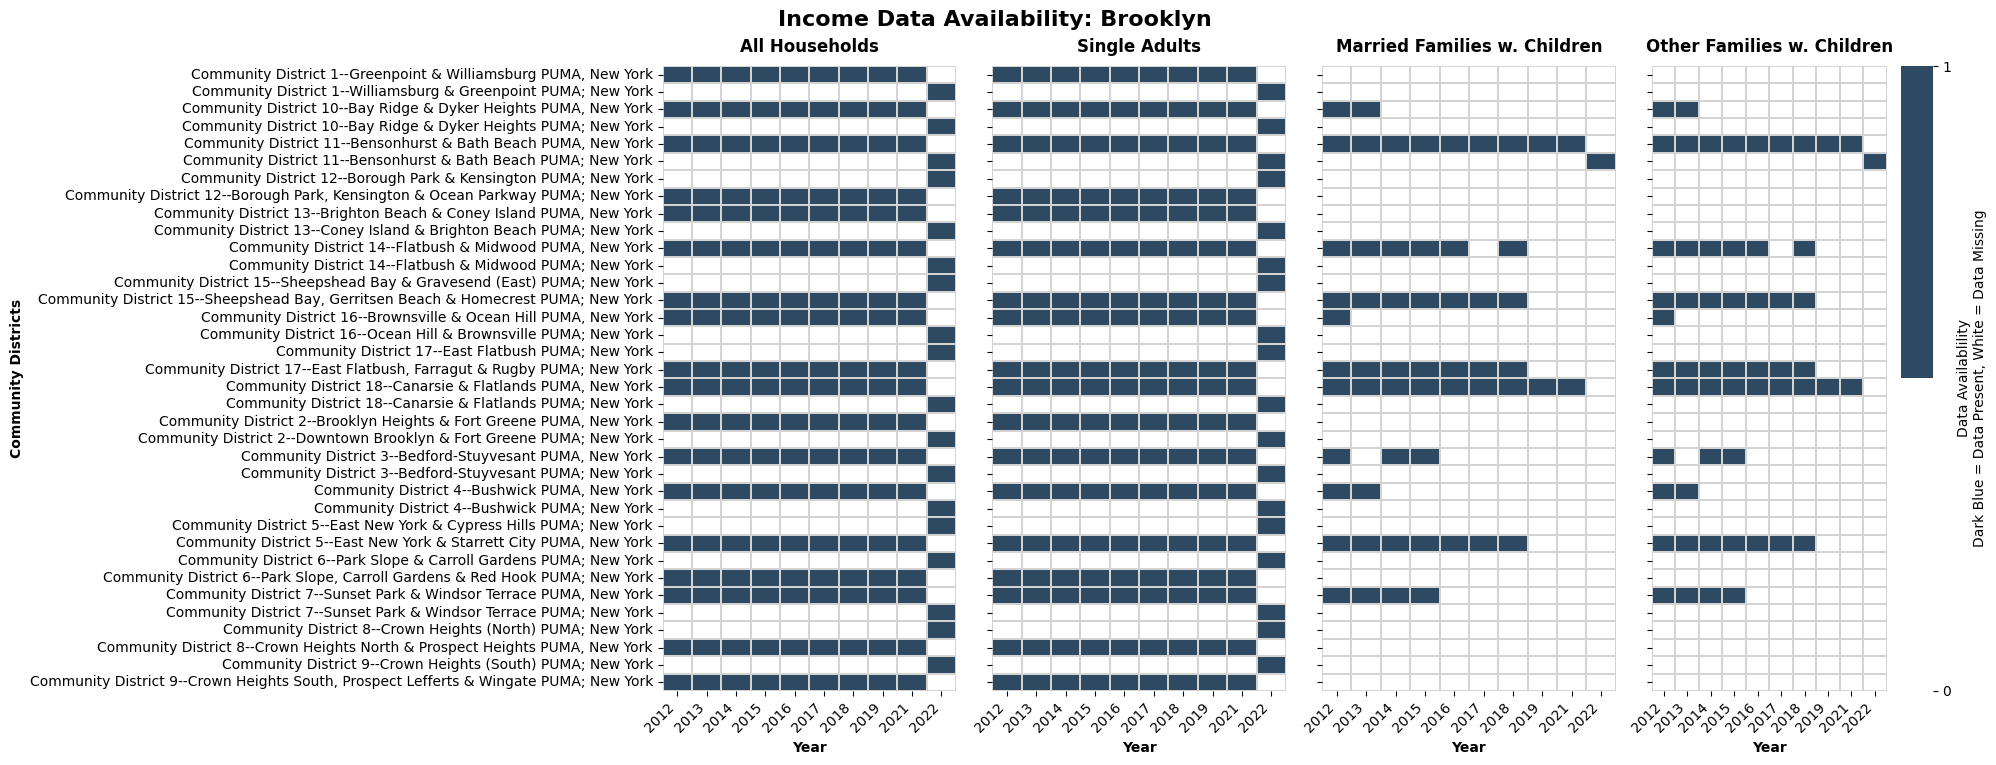


Processing Manhattan...
  All Households: 100.0/200 data points (50.0% coverage)
  Single Adults: 100.0/200 data points (50.0% coverage)
  Married Families w. Children: 4.0/200 data points (2.0% coverage)
  Other Families w. Children: 4.0/200 data points (2.0% coverage)


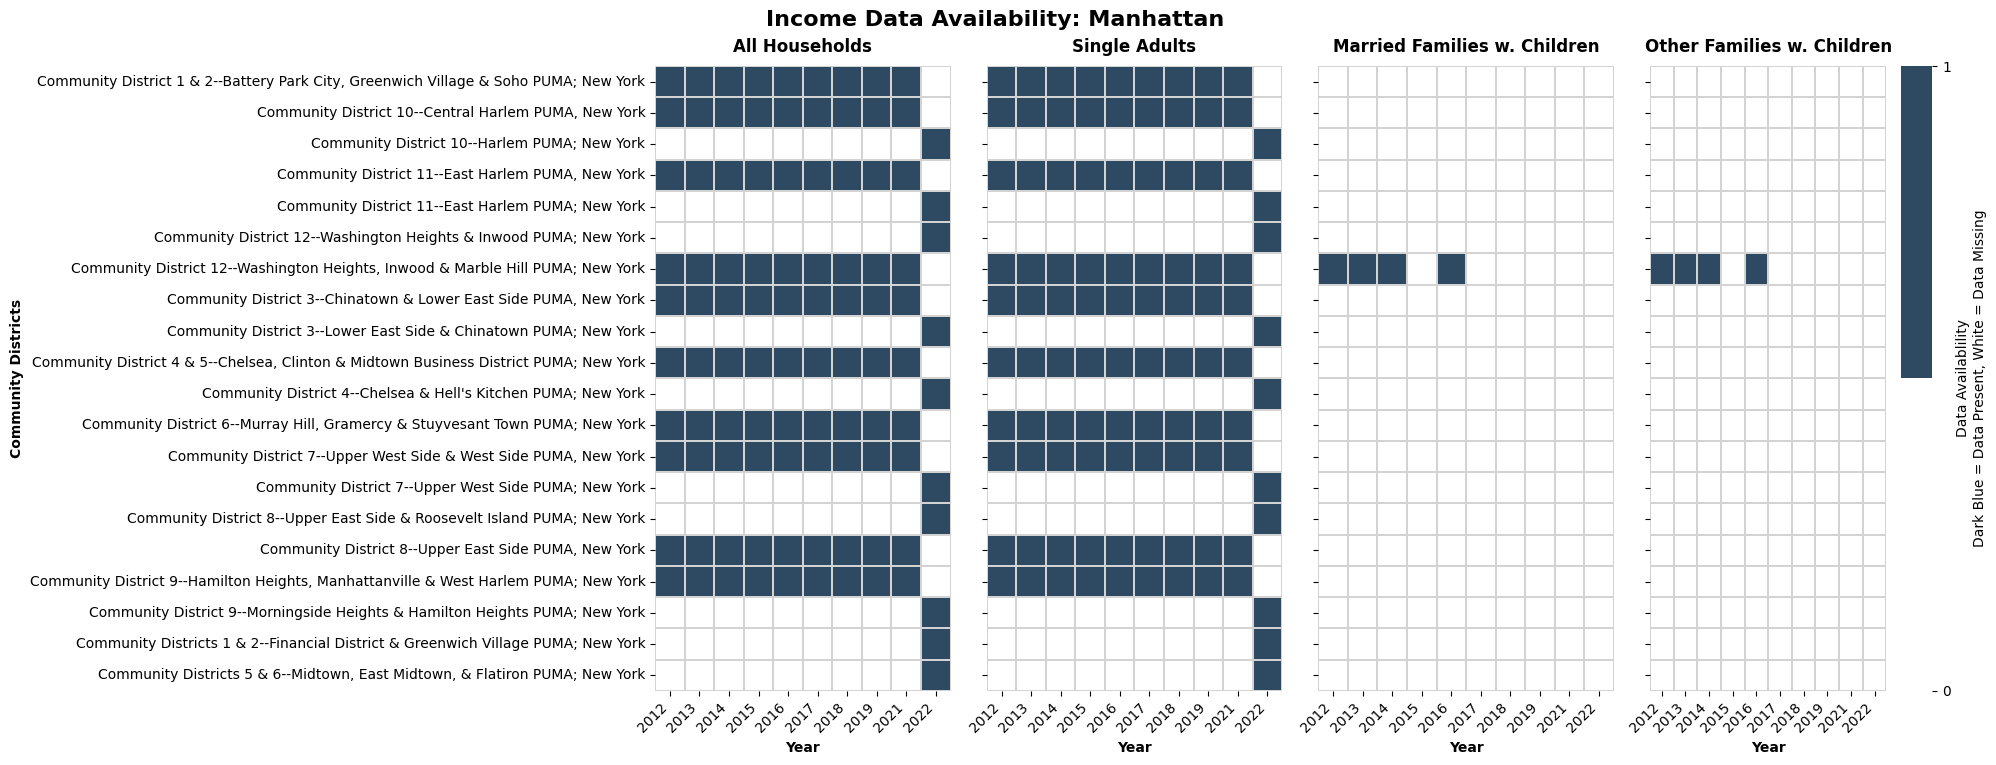


Processing Queens...
  All Households: 140.0/280 data points (50.0% coverage)
  Single Adults: 140.0/280 data points (50.0% coverage)
  Married Families w. Children: 56.0/280 data points (20.0% coverage)
  Other Families w. Children: 56.0/280 data points (20.0% coverage)


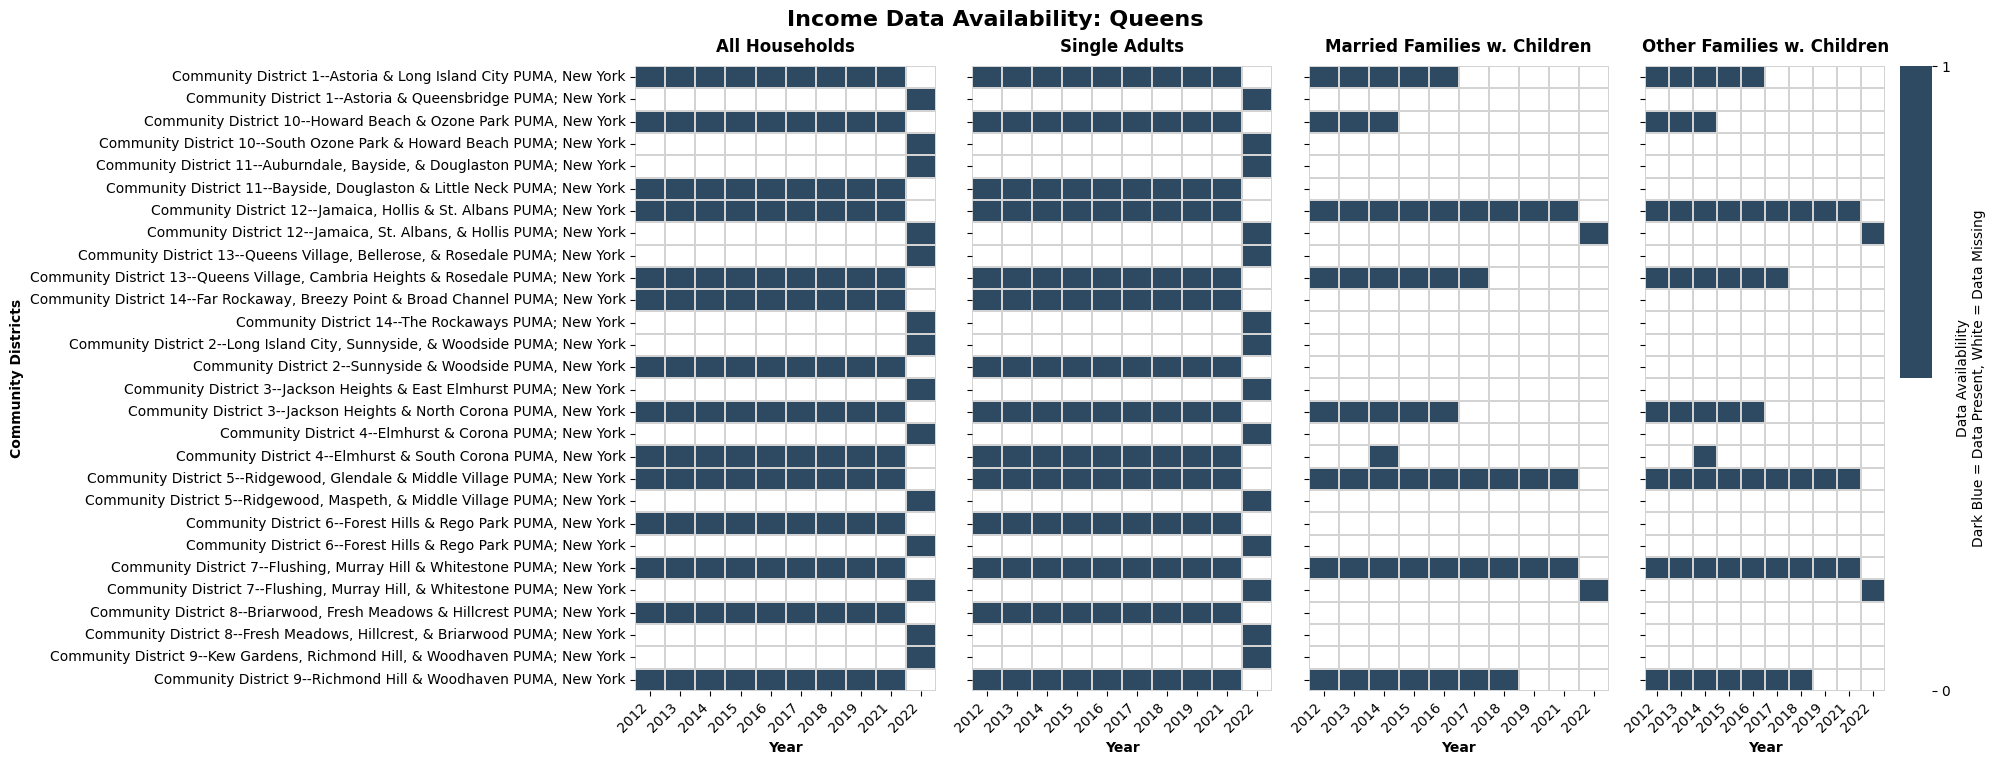

In [ ]:
def create_income_data_availability_heatmaps(income_df, figsize_per_borough=(20, 8)):
    """
    Creates data availability heatmaps for income data across all boroughs and household types.
    
    Parameters:
    ------
    median_income_df : pandas.DataFrame
        The income dataframe with columns: district, PUMA, year, 
         all_HHs, singles, married_kids, other_kids
    figsize_per_borough : tuple
        Figure size for each borough's plot
    """
    
    # Define the household type columns
    household_types = ['all_HHs', 'singles', 'married_kids', 'other_kids']
    household_labels = ['All Households', 'Single Adults', 'Married Families w. Children', 'Other Families w. Children']

    # Extract borough from distruct column 
    income_df['borough'] = income_df['district'].str.extract(r'NYC-([^-]+)')[0].str.split(' Community ', expand=True)[0]
    
    # Get unique boroughs and years
    boroughs = income_df['borough'].unique()
    years = sorted(income_df['year'].unique())
    
    # Custom colormap: white for missing, dark blue for present
    colors = ['white', '#2E4A62']
    custom_cmap = mpl.colors.ListedColormap(colors)
    
    # Create a figure for each borough
    for borough in boroughs:
        if pd.isna(borough):
            continue
            
        print(f"\nProcessing {borough}...")
        
        # Filter data for current borough
        borough_data = income_df[income_df['borough'] == borough].copy()
        
        # Get unique districts for this borough
        districts = sorted(borough_data['district'].unique())
        
        # Create figure with 4 subplots (one for each household type)
        fig, axes = plt.subplots(1, 4, figsize=figsize_per_borough, sharey=True)
        fig.suptitle(f'Income Data Availability: {borough}', 
                    fontsize=16, fontweight='bold', y=0.95)
        
        # Create availability matrix for each household type
        for idx, (hh_type, hh_label) in enumerate(zip(household_types, household_labels)):
            # Initialize availability matrix (districts x years)
            availability_matrix = np.zeros((len(districts), len(years)))
            
            # Fill the matrix
            for district_idx, district in enumerate(districts):
                for year_idx, year in enumerate(years):
                    # Find the row for this district and year
                    mask = (borough_data['district'] == district) & (borough_data['year'] == year)
                    matching_rows = borough_data[mask]
                    
                    if len(matching_rows) > 0:
                        value = matching_rows[hh_type].iloc[0]
                        if pd.notna(value) and str(value).lower() != 'none':
                            availability_matrix[district_idx, year_idx] = 1
                    # If no matching row or value is NaN/None, it remains 0
            
            # Create heatmap for this household type
            ax = axes[idx]
            
            # Create the heatmap
            sns.heatmap(availability_matrix,
                       cmap=custom_cmap,
                       ax=ax,
                       cbar_kws={'label': 'Data Availablility\nDark Blue = Data Present, White = Data Missing',
                                  'ticks': [0, 1]} if idx == 3 else {'ticks': [0, 1]},
                       xticklabels=years,
                       yticklabels=['Community'+district.split(' Community')[1] for district in districts],
                       linewidths=0.1,
                       linecolor='lightgray',
                       cbar=idx == 3, # Only show colorbar on the last subplot
                       vmin=0,  # Explicitly set color range
                       vmax=1)  
            
            # Customize subplot
            ax.set_title(hh_label, fontsize=12, fontweight='bold', pad=10)
            ax.set_xlabel('Year', fontsize=10, fontweight='bold')
            if idx == 0:
                ax.set_ylabel('Community Districts', fontsize=10, fontweight='bold')
            
            # Rotate x-axis labels
            ax.set_xticklabels(years, rotation=45, ha='right')
            
            # Calculate and print summary for this subplot
            total_cells = availability_matrix.size
            present_data = np.sum(availability_matrix)
            coverage_pct = (present_data / total_cells * 100) if total_cells > 0 else 0
            
            print(f"  {hh_label}: {present_data}/{total_cells} data points ({coverage_pct:.1f}% coverage)")
        
        # Adjust layout
        plt.tight_layout()
        plt.subplots_adjust(top=0.88)  # Make room for suptitle
        
        # Show the plot
        plt.show()
    
    return

create_income_data_availability_heatmaps(income_df)


We can see that it's going to be easy to calculate affordability metrics for 'All Households' and 'Single Adult' populations, however, there is limited coverage of median income for both groups of family populations. Brooklyn and Queens are boroughs with the best data for those family populations, so we will assess affordability for families based on the income and rent data for those 2 boroughs and their respective neighborhoods solely.

## Preliminary Income Data Analysis

### Time series of Median Household Income

#### All Households

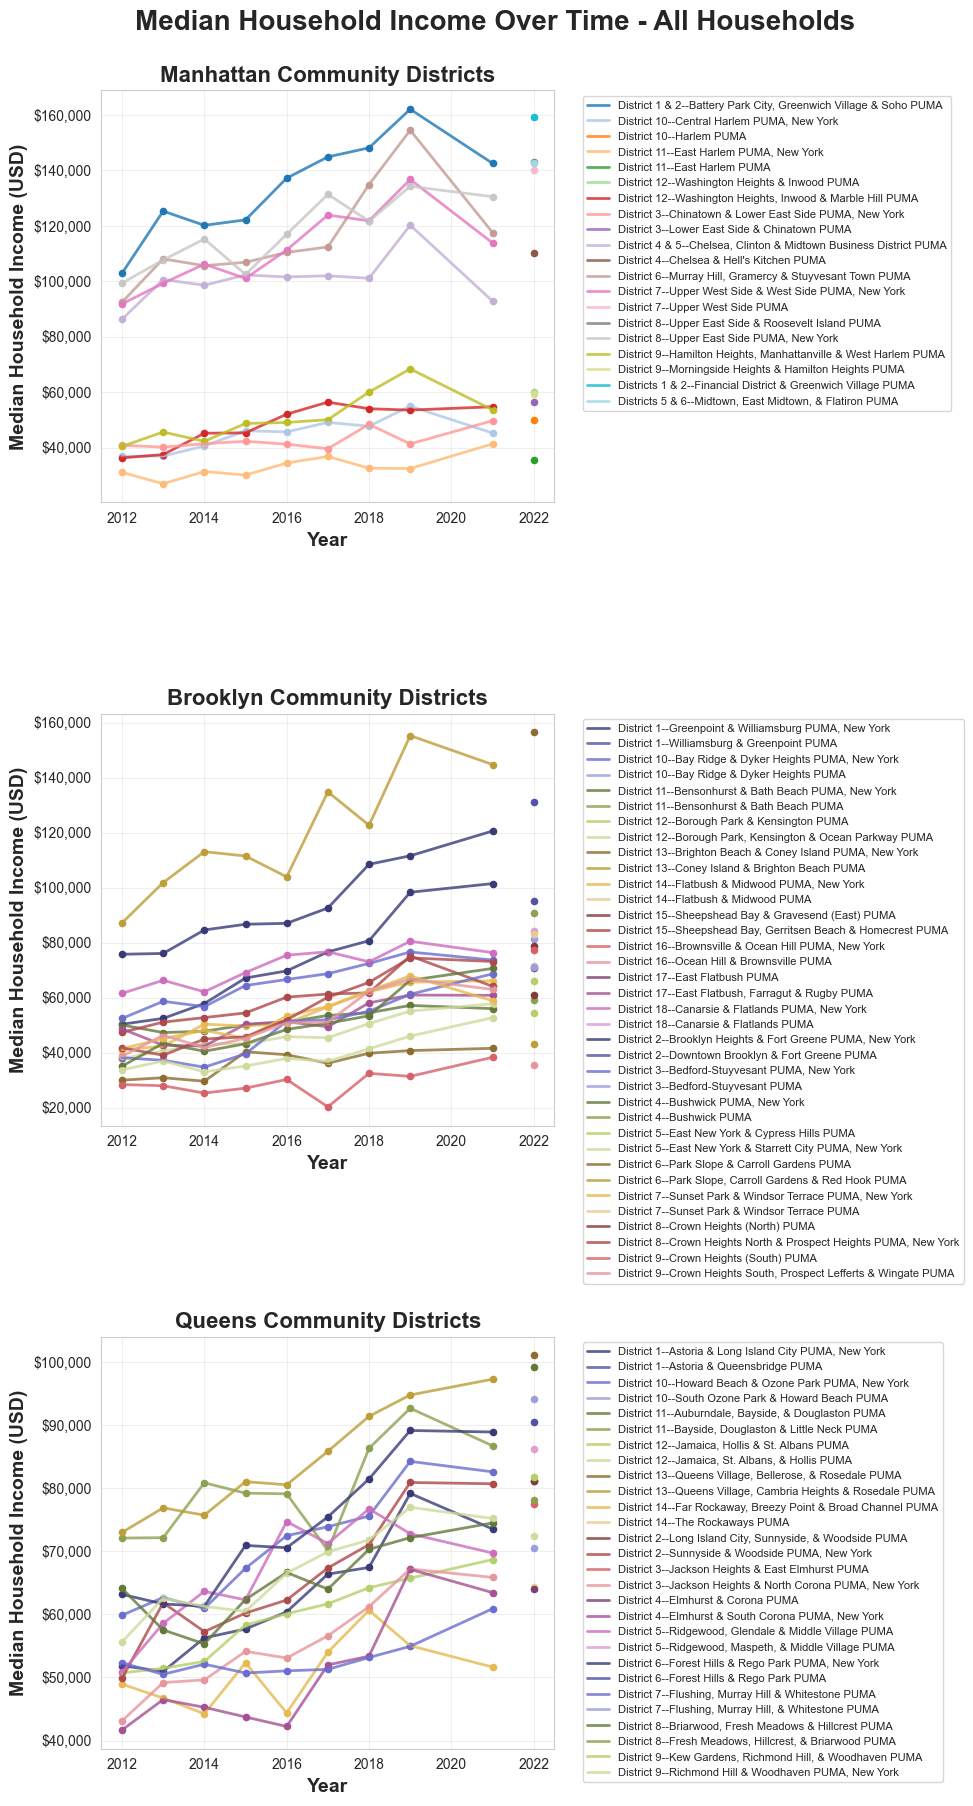

Data Summary by Borough:
--------------------------------------------------
Manhattan: 20 districts w. $81,532 avg income (2012-2022)
Brooklyn: 36 districts w. $60,276 avg income (2012-2022)
Queens: 28 districts w. $66,335 avg income (2012-2022)


In [46]:
# Set up the plot style
sns.set_style("whitegrid")

# Get all NYC boroughs
boroughs = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']

# Create separate plot for each borough
fig, axes = plt.subplots(5, 1, figsize=(10, 30))
axes = axes.flatten()  # Flatten for easier indexing

for i, borough in enumerate(boroughs):
    ax = axes[i]
    
    # Filter data for the current borough
    borough_data = income_df[income_df['district'].str.contains(borough, case=False)][['year','district','all_HHs']]

    if not borough_data.empty:
        # Get unique districts for this borough
        districts = borough_data['district'].unique()
        
        # Create color palette for districts in this borough
        if (borough == 'Brooklyn')|(borough == 'Queens'):
            district_colors = sns.color_palette("tab20b", len(districts))
        else:
            district_colors = sns.color_palette("tab20", len(districts))
        
        # Plot each district as a separate line with unique color
        for j, district_name in enumerate(districts):
            district_data = borough_data[borough_data['district'] == district_name]
            # Sort by year to ensure proper line connections
            district_sorted = district_data.sort_values('year')
            
            ax.plot(district_sorted['year'], district_sorted['all_HHs'], 
                   color=district_colors[j], linewidth=2, alpha=0.8,
                   label=district_name[district_name.find('District'):].split(';')[0] if '--' in district_name else district_name)
            ax.scatter(district_sorted['year'], district_sorted['all_HHs'], 
                   color=district_colors[j], s=20)
        
        # Customize each subplot
        ax.set_xlabel('Year', fontsize=14, fontweight='bold')
        ax.set_ylabel('Median Household Income (USD)', fontsize=14, fontweight='bold')
        ax.set_title(f'{borough} Community Districts', fontsize=16, fontweight='bold')
        
        # Format y-axis to show dollar signs
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
        
        # Add legend (truncated district names for readability)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    else:
        # Hide empty subplot
        ax.set_visible(False)

# Hide the extra subplot (since we have 5 boroughs but 6 subplot spaces)
#axes[5].set_visible(False)

# Improve overall layout
plt.suptitle('Median Household Income Over Time - All Households', 
             fontsize=20, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

# summary statistics
print("Data Summary by Borough:")
print("-" * 50)
for borough in boroughs:
    borough_data = income_df[income_df['district'].str.contains(borough, case=False)]
    if not borough_data.empty:
        avg_income = borough_data['all_HHs'].mean()
        num_districts = borough_data['district'].nunique()
        year_range = f"{borough_data['year'].min()}-{borough_data['year'].max()}"
        print(f"{borough}: {num_districts} districts w. ${avg_income:,.0f} avg income ({year_range})")

#### Single Adults

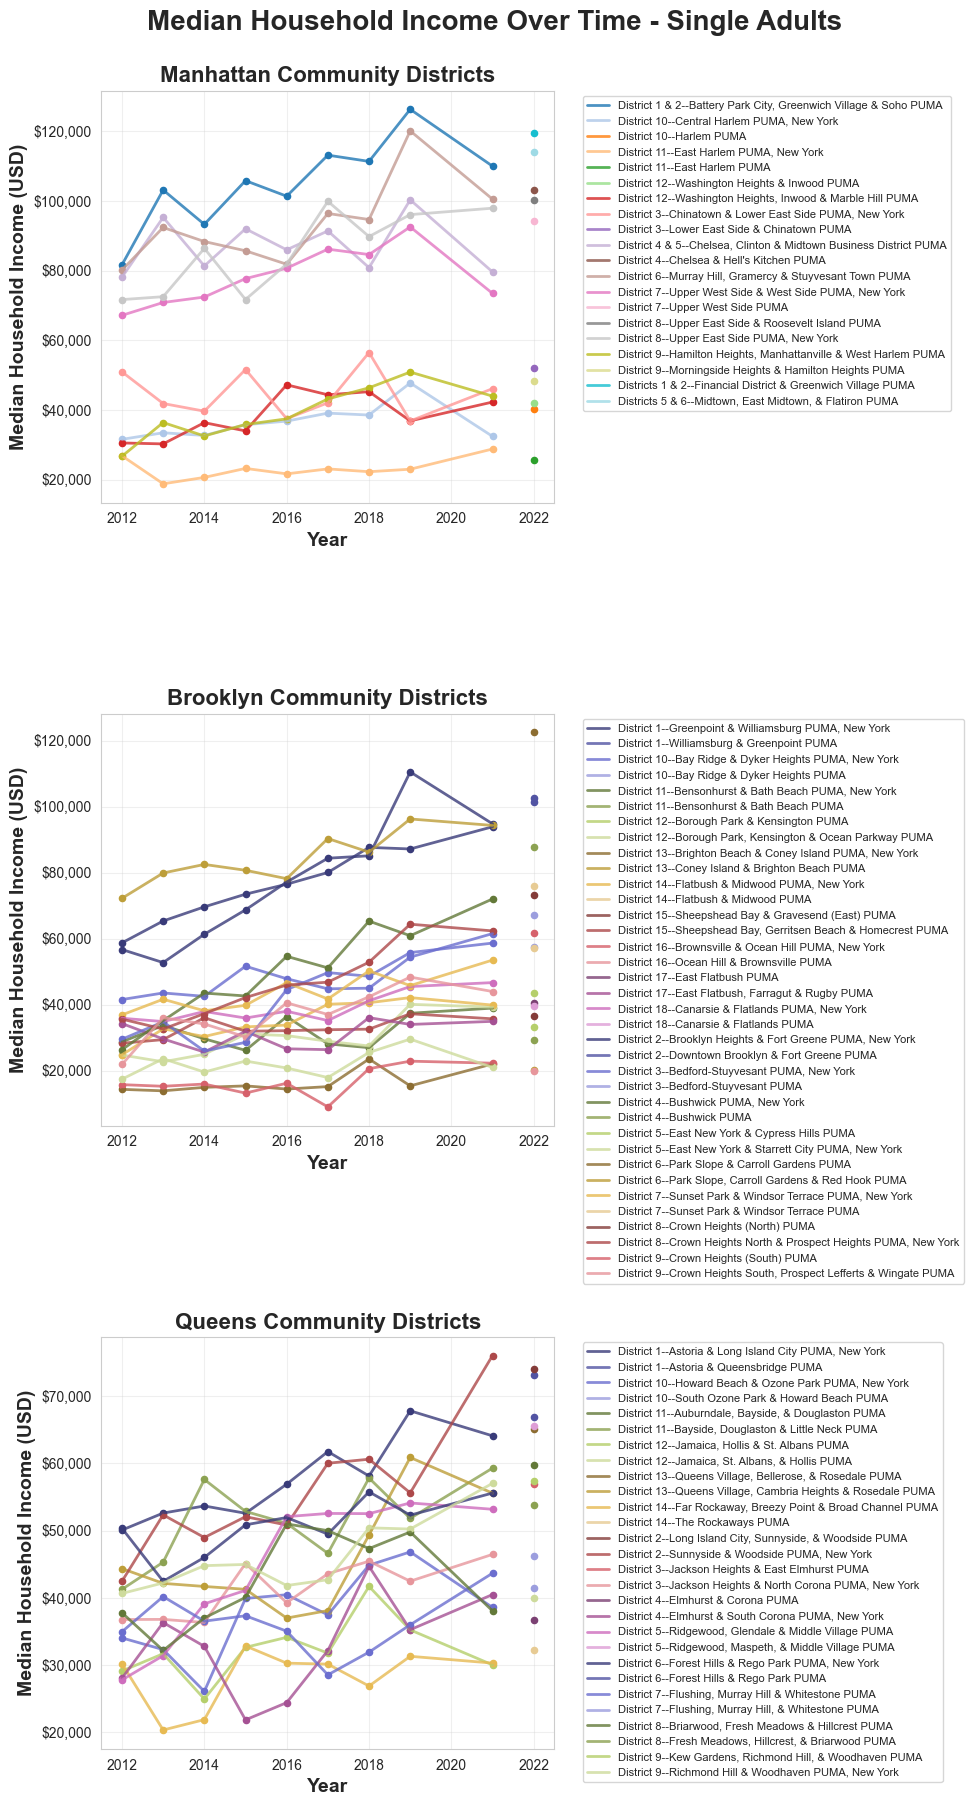

Data Summary by Borough:
--------------------------------------------------
Manhattan: 20 districts w. $64,238 avg income (2012-2022)
Brooklyn: 36 districts w. $44,013 avg income (2012-2022)
Queens: 28 districts w. $44,241 avg income (2012-2022)


In [47]:
# Set up the plot style
sns.set_style("whitegrid")

# Get all NYC boroughs
boroughs = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']

# Create separate plot for each borough
fig, axes = plt.subplots(5, 1, figsize=(10, 30))
axes = axes.flatten()  # Flatten for easier indexing

for i, borough in enumerate(boroughs):
    ax = axes[i]
    
    # Filter data for the current borough
    borough_data = income_df[income_df['district'].str.contains(borough, case=False)][['year','district','singles']]
    
    if not borough_data.empty:
        # Get unique districts for this borough
        districts = borough_data['district'].unique()
        
        # Create color palette for districts in this borough
        if (borough == 'Brooklyn')|(borough == 'Queens'):
            district_colors = sns.color_palette("tab20b", len(districts))
        else:
            district_colors = sns.color_palette("tab20", len(districts))
        
        # Plot each district as a separate line with unique color
        for j, district_name in enumerate(districts):
            district_data = borough_data[borough_data['district'] == district_name]
            # Sort by year to ensure proper line connections
            district_sorted = district_data.sort_values('year')
            
            ax.plot(district_sorted['year'], district_sorted['singles'], 
                   color=district_colors[j], linewidth=2, alpha=0.8,
                   label=district_name[district_name.find('District'):].split(';')[0] if '--' in district_name else district_name)
            ax.scatter(district_sorted['year'], district_sorted['singles'], 
                   color=district_colors[j], s=20)
        
        # Customize each subplot
        ax.set_xlabel('Year', fontsize=14, fontweight='bold')
        ax.set_ylabel('Median Household Income (USD)', fontsize=14, fontweight='bold')
        ax.set_title(f'{borough} Community Districts', fontsize=16, fontweight='bold')
        
        # Format y-axis to show dollar signs
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
        
        # Add legend (truncated district names for readability)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    else:
        # Hide empty subplot
        ax.set_visible(False)

# Hide the extra subplot (since we have 5 boroughs but 6 subplot spaces)
#axes[5].set_visible(False)

# Improve overall layout
plt.suptitle('Median Household Income Over Time - Single Adults', 
             fontsize=20, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

# summary statistics
print("Data Summary by Borough:")
print("-" * 50)
for borough in boroughs:
    borough_data = income_df[income_df['district'].str.contains(borough, case=False)]
    if not borough_data.empty:
        avg_income = borough_data['singles'].mean()
        num_districts = borough_data['district'].nunique()
        year_range = f"{borough_data['year'].min()}-{borough_data['year'].max()}"
        print(f"{borough}: {num_districts} districts w. ${avg_income:,.0f} avg income ({year_range})")

#### Married Families with Children

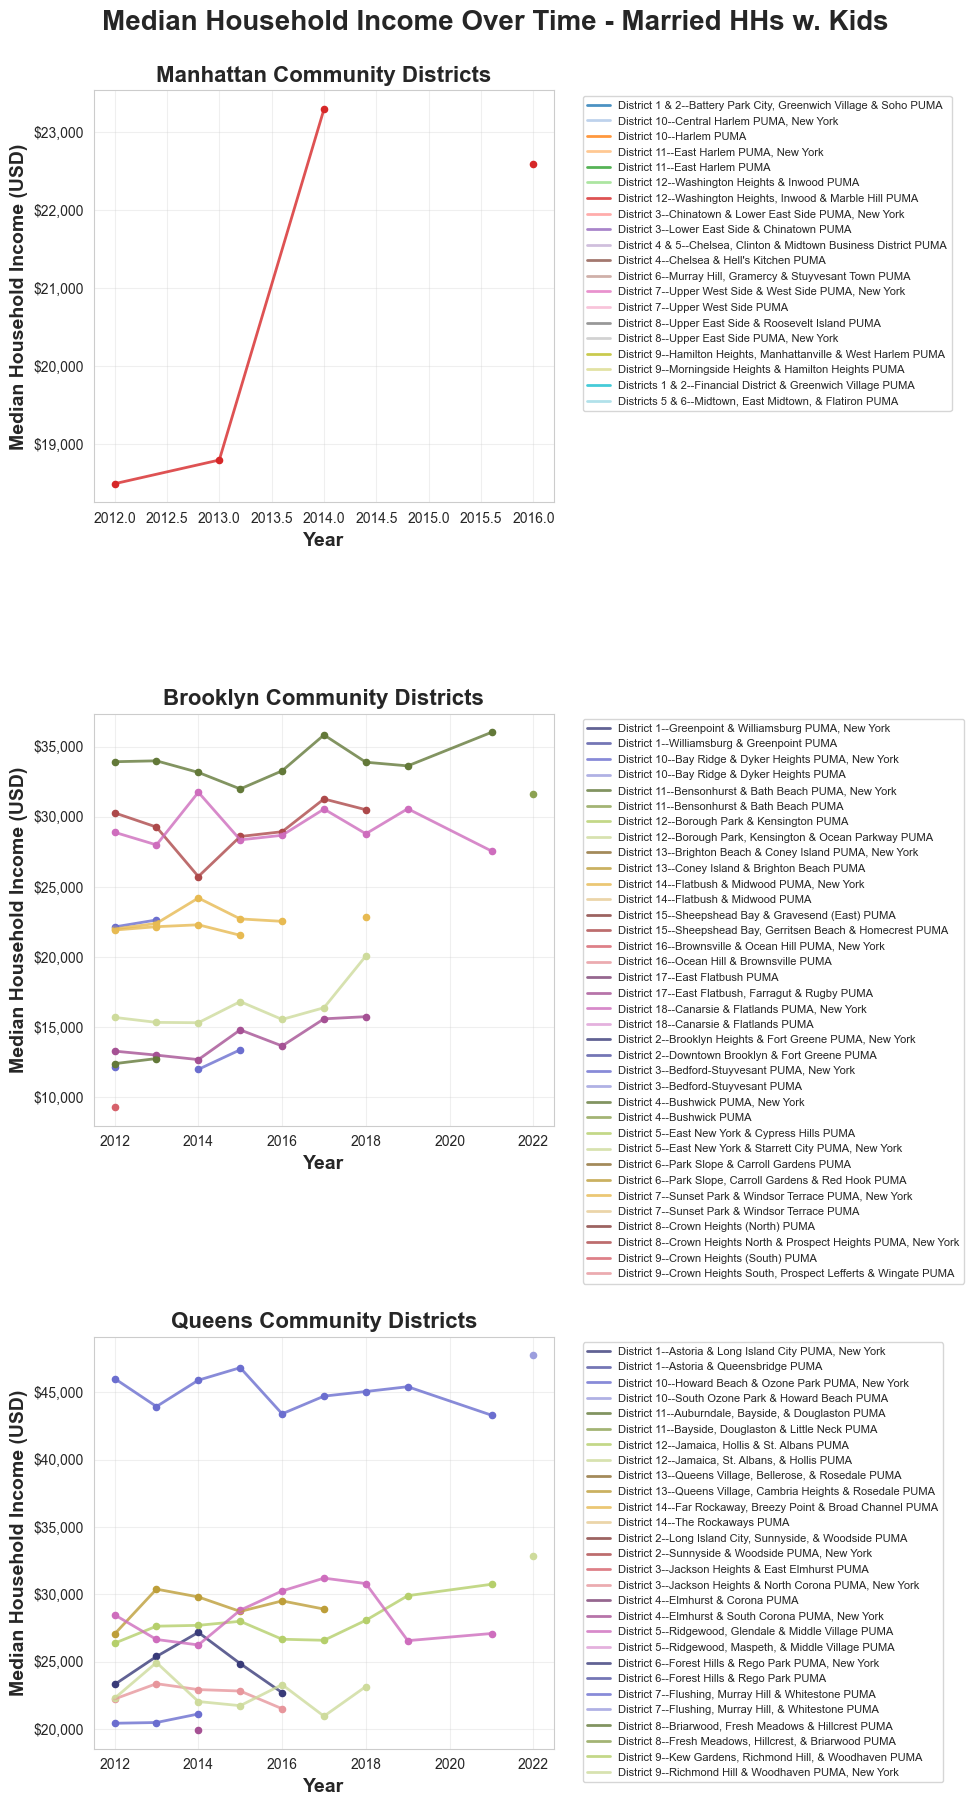

Data Summary by Borough:
--------------------------------------------------
Manhattan: 20 districts w. $20,793 avg income (2012-2022)
Brooklyn: 36 districts w. $23,449 avg income (2012-2022)
Queens: 28 districts w. $29,355 avg income (2012-2022)


In [48]:
# Set up the plot style
sns.set_style("whitegrid")

# Get all NYC boroughs
boroughs = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']

# Create separate plot for each borough
fig, axes = plt.subplots(5, 1, figsize=(10, 30))
axes = axes.flatten()  # Flatten for easier indexing

for i, borough in enumerate(boroughs):
    ax = axes[i]
    
    # Filter data for the current borough
    borough_data = income_df[income_df['district'].str.contains(borough, case=False)][['year','district','married_kids']]
    
    if not borough_data.empty:
        # Get unique districts for this borough
        districts = borough_data['district'].unique()
        
        # Create color palette for districts in this borough
        if (borough == 'Brooklyn')|(borough == 'Queens'):
            district_colors = sns.color_palette("tab20b", len(districts))
        else:
            district_colors = sns.color_palette("tab20", len(districts))
        
        # Plot each district as a separate line with unique color
        for j, district_name in enumerate(districts):
            district_data = borough_data[borough_data['district'] == district_name]
            # Sort by year to ensure proper line connections
            district_sorted = district_data.sort_values('year')
            
            ax.plot(district_sorted['year'], district_sorted['married_kids'], 
                   color=district_colors[j], linewidth=2, alpha=0.8,
                   label=district_name[district_name.find('District'):].split(';')[0] if '--' in district_name else district_name)
            ax.scatter(district_sorted['year'], district_sorted['married_kids'], 
                   color=district_colors[j], s=20)
        
        # Customize each subplot
        ax.set_xlabel('Year', fontsize=14, fontweight='bold')
        ax.set_ylabel('Median Household Income (USD)', fontsize=14, fontweight='bold')
        ax.set_title(f'{borough} Community Districts', fontsize=16, fontweight='bold')
        
        # Format y-axis to show dollar signs
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
        
        # Add legend (truncated district names for readability)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    else:
        # Hide empty subplot
        ax.set_visible(False)

# Hide the extra subplot (since we have 5 boroughs but 6 subplot spaces)
#axes[5].set_visible(False)

# Improve overall layout
plt.suptitle('Median Household Income Over Time - Married HHs w. Kids', 
             fontsize=20, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

# summary statistics
print("Data Summary by Borough:")
print("-" * 50)
for borough in boroughs:
    borough_data = income_df[income_df['district'].str.contains(borough, case=False)]
    if not borough_data.empty:
        avg_income = borough_data['married_kids'].mean()
        num_districts = borough_data['district'].nunique()
        year_range = f"{borough_data['year'].min()}-{borough_data['year'].max()}"
        print(f"{borough}: {num_districts} districts w. ${avg_income:,.0f} avg income ({year_range})")

#### Other Families with Children

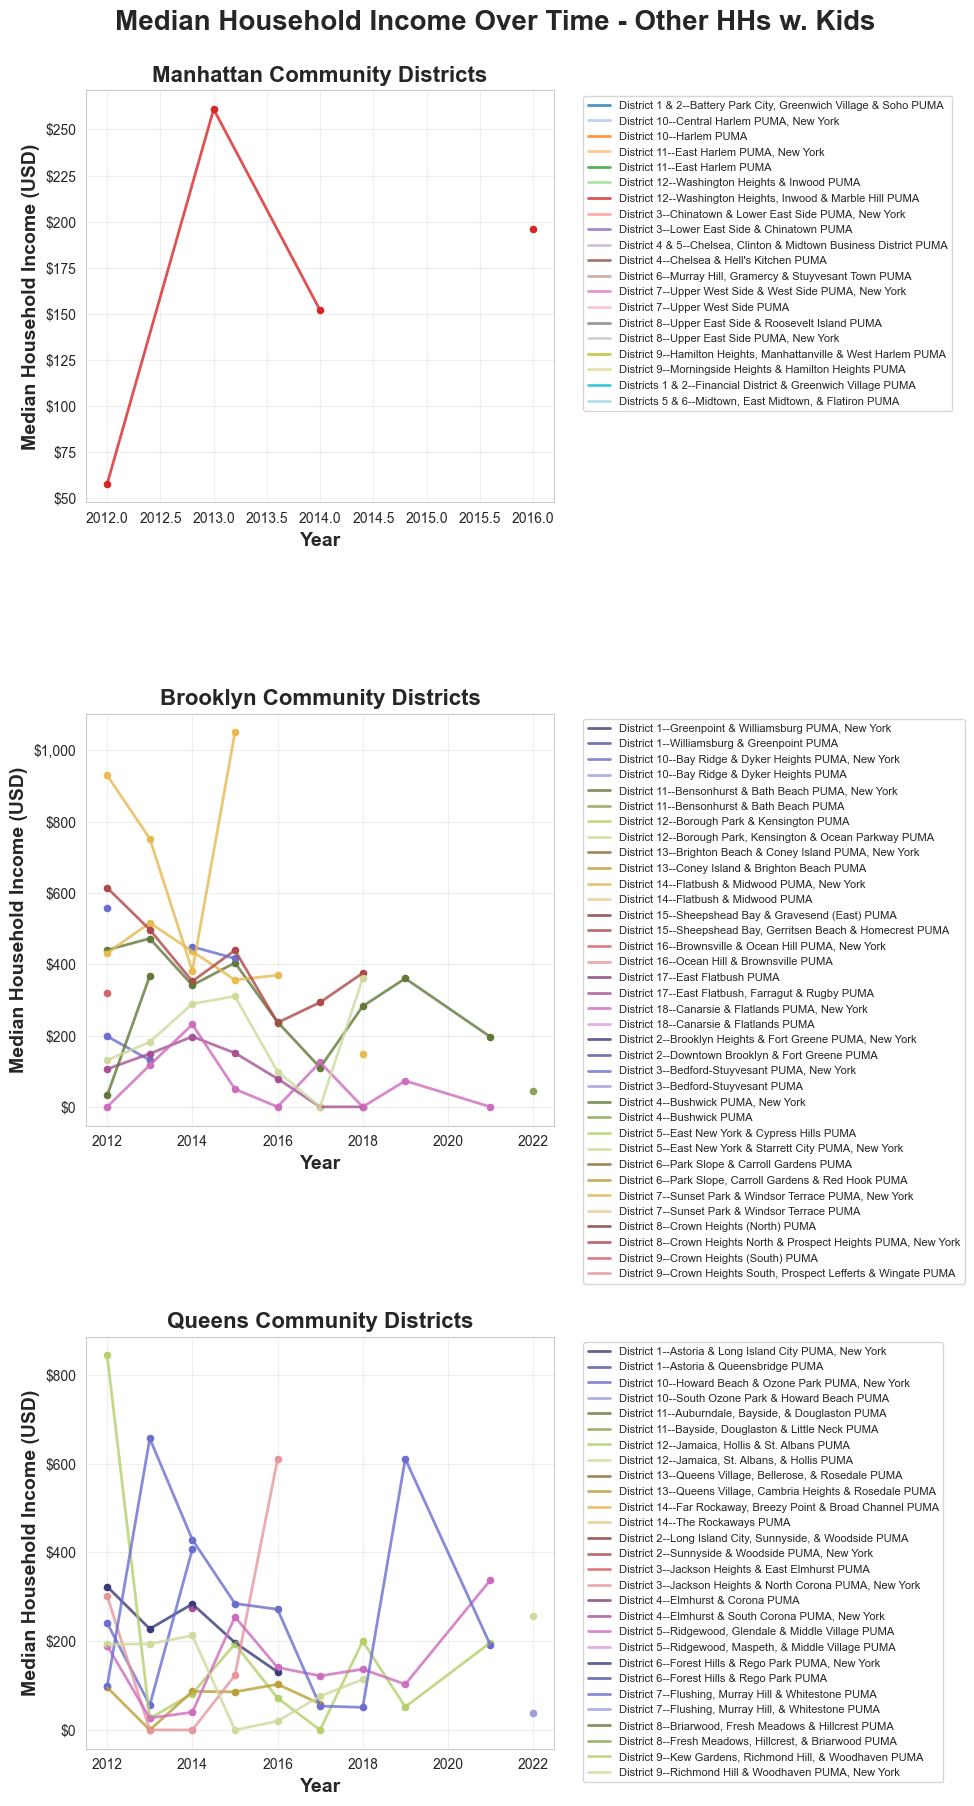

Data Summary by Borough:
--------------------------------------------------
Manhattan: 20 districts w. $167 avg income (2012-2022)
Brooklyn: 36 districts w. $279 avg income (2012-2022)
Queens: 28 districts w. $185 avg income (2012-2022)


In [49]:
# Set up the plot style
sns.set_style("whitegrid")

# Get all NYC boroughs
boroughs = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']

# Create separate plot for each borough
fig, axes = plt.subplots(5, 1, figsize=(10, 30))
axes = axes.flatten()  # Flatten for easier indexing

for i, borough in enumerate(boroughs):
    ax = axes[i]
    
    # Filter data for the current borough
    borough_data = income_df[income_df['district'].str.contains(borough, case=False)][['year','district','other_kids']]
    
    if not borough_data.empty:
        # Get unique districts for this borough
        districts = borough_data['district'].unique()
        
        # Create color palette for districts in this borough
        if (borough == 'Brooklyn')|(borough == 'Queens'):
            district_colors = sns.color_palette("tab20b", len(districts))
        else:
            district_colors = sns.color_palette("tab20", len(districts))
        
        # Plot each district as a separate line with unique color
        for j, district_name in enumerate(districts):
            district_data = borough_data[borough_data['district'] == district_name]
            # Sort by year to ensure proper line connections
            district_sorted = district_data.sort_values('year')
            
            ax.plot(district_sorted['year'], district_sorted['other_kids'], 
                   color=district_colors[j], linewidth=2, alpha=0.8,
                   label=district_name[district_name.find('District'):].split(';')[0] if '--' in district_name else district_name)
            ax.scatter(district_sorted['year'], district_sorted['other_kids'], 
                   color=district_colors[j], s=20)
        
        # Customize each subplot
        ax.set_xlabel('Year', fontsize=14, fontweight='bold')
        ax.set_ylabel('Median Household Income (USD)', fontsize=14, fontweight='bold')
        ax.set_title(f'{borough} Community Districts', fontsize=16, fontweight='bold')
        
        # Format y-axis to show dollar signs
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
        
        # Add legend (truncated district names for readability)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    else:
        # Hide empty subplot
        ax.set_visible(False)

# Hide the extra subplot (since we have 5 boroughs but 6 subplot spaces)
#axes[5].set_visible(False)

# Improve overall layout
plt.suptitle('Median Household Income Over Time - Other HHs w. Kids', 
             fontsize=20, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

# summary statistics
print("Data Summary by Borough:")
print("-" * 50)
for borough in boroughs:
    borough_data = income_df[income_df['district'].str.contains(borough, case=False)]
    if not borough_data.empty:
        avg_income = borough_data['other_kids'].mean()
        num_districts = borough_data['district'].nunique()
        year_range = f"{borough_data['year'].min()}-{borough_data['year'].max()}"
        print(f"{borough}: {num_districts} districts w. ${avg_income:,.0f} avg income ({year_range})")

## Load/Uploading Dataset to BigQuery

In [17]:
# configuration
PROJECT_ID = "rent-affordability"
DATASET = "nyc_analysis"
TABLE_ID = f"{PROJECT_ID}.{DATASET}.staging_median_income"

# load credentials
service_account_info = json.loads(os.environ["GOOGLE_CREDENTIALS_JSON"])
credentials = service_account.Credentials.from_service_account_info(service_account_info)
# initialize client
client = bigquery.Client(project=PROJECT_ID, credentials=credentials)
job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")

job = client.load_table_from_dataframe(income_df, TABLE_ID, job_config=job_config)
job.result() # ensures the script waits for the job to complete

# 5a. check if the upload was successful
if job.state == 'DONE':
    if job.error_result:
        print(f"Job completed with errors: {job.error_result}")
    else:
        print(f"Job completed successfully. Loaded {job.output_rows} rows to {TABLE_ID}")
else:
    print(f"Job state: {job.state}")

Job completed successfully. Loaded 420 rows to rent-affordability.nyc_analysis.staging_median_income
